# 1. Introduction

The Project aims to obtain insights over the characteristics of real and fake online job postings, by performing Exploratory Data Analysis (EDA) and conducting various classification models in machine learning on a dataset provided on [Kaggle](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction).

## 1.1 Objectives

The dataset is very valuable as it can be used to answer the following questions:

1. Perform Exploratory Data Analysis on the dataset to identify interesting insights from this dataset.
2. Create a classification model that uses text data features and meta-features and predict which job description are fraudulent or real.
3. Identify key traits/features (words, entities, phrases) of job descriptions which are fraudulent in nature.

## 1.2 Data Description

This dataset contains 18K job descriptions out of which about 800 are fake. The data consists of both textual information and meta-information about the jobs. It contains the following columns:
- job id - unique ID number provided to each and every job provided in the dataset. (*Index*)
- title - Job title provided in the ad post.(*Text!*)
- location - Job geographical location in the ad post.(Contain Country, State/Province, City/Area, *Categorical*)
- department - Corporate departments, like Sales.(*Categorical*, 65% Missing)
- salary_range - Indicative range for salary listed by the Employer, like $50,000-$60,000.(*Categorical*, 84% Missing)
- company_profile - A brief description about the company.(19% Missing, *Text!*)
- description - Job Description provided on the Job Opportunity.(*Text!*)
- requirements - Detailed job requirements to be fulfilled.(15% Missing,*Text!*)
- benefits - Enlisted offered benefits by the employer.(40% Missing,*Text!*)
- telecommuting - True for telecommuting positions.(*Boolean*)
- has_company_logo - True if company logo is present.(*Boolean*)
- has_questions - True if screening questions are present.(*Boolean*)
- employment_type - Category of Employment provided for the Employees.(*Categorical*, 19% Missing)
- required_experience - Type of the previous experience required from the employees.(*Categorical/Oridinal*, 39% Missing)
- required_education - Education qualifications required from the employees.(*Categorical/Oridinal*, 39% Missing)
- Industry - Domain in which the Company. (*Categorical*, 27% Missing)
- Function - Type of Profession the Company follows.(*Categorical*, 36% Missing)
- Fraudulent - **TARGET** of Classification attribute.

# 2. Module Management, Data Import

Make the Job_ID as index, cast all strings to lower cases, missing to empty strings, and save binaries as int8. 

In [1]:
# data manipulation
import pandas as pd
import numpy as np 
import scipy as sp
# computation
from multiprocessing import Pool, cpu_count
import joblib  # a tool to provide lightweight pipelining in Python. 1. easy simple parallel computing, 2. transparent disk-caching of functions and lazy re-evaluation
from joblib import Parallel, delayed
from tqdm import tqdm   # a fast, extensible progress bar for loops and CLI
import json   # shallow and deep copy operations
from sklearn.base import clone
import optuna
import logging
# nlp tools
import re, nltk, spacy, string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from spacy.lang.en import English
from spacy.lang.en.stop_words import STOP_WORDS
from polyfuzz import PolyFuzz
from polyfuzz.models import GensimEmbeddings, SpacyEmbeddings
from polyfuzz.models import Embeddings
from flair.embeddings import TransformerWordEmbeddings, WordEmbeddings
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [220]:
# modeling
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, KFold, train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
# from imblearn.under_sampling import RandomUnderSampler # imbalance-learn is a Python package offering a number of re-sampling techniques commonly used in datasets showing strong between-class imbalance.
from catboost import CatBoostClassifier, Pool
from autogluon.tabular import TabularPredictor, TabularDataset, FeatureMetadata 
from autogluon.features.generators import PipelineFeatureGenerator, CategoryFeatureGenerator, IdentityFeatureGenerator, TextSpecialFeatureGenerator, TextNgramFeatureGenerator, TextSpecialFeatureGenerator


In [3]:
# visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from catboost.utils import get_roc_curve
import plotly.express as px
from opencage.geocoder import OpenCageGeocode
# Aesthetics
sns.set_style("ticks")
sns.color_palette("husl", 8)
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12
pd.options.display.max_columns = 25
pd.options.display.max_rows = 100

In [12]:
file_path = 'fake_job_postings.csv'

df = pd.read_csv(file_path, index_col=0,
                 dtype={'job_id': np.int32, 'telecommuting': np.int8, 'has_company_logo': np.int8, 'has_questions': np.int8, 'fraudulent': np.int8})
df.reset_index(drop=True, inplace=True)
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [13]:
print(f'The dataset shape is {df.shape}.')

The dataset shape is (17880, 17).


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      14572 non-null  object
 5   description          17879 non-null  object
 6   requirements         15184 non-null  object
 7   benefits             10668 non-null  object
 8   telecommuting        17880 non-null  int8  
 9   has_company_logo     17880 non-null  int8  
 10  has_questions        17880 non-null  int8  
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function             11425 non-null  object
 16  frau

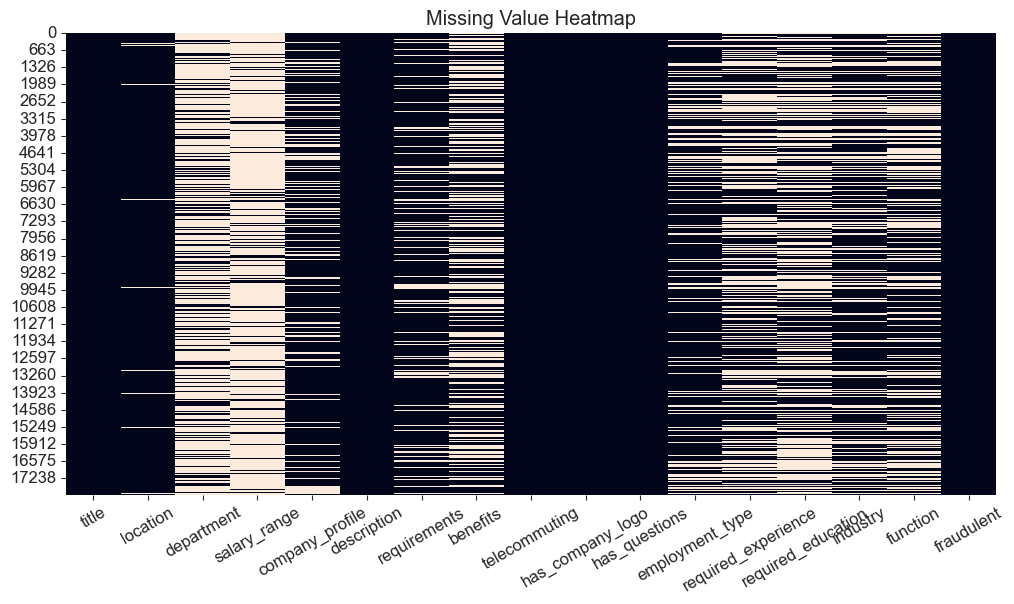

In [15]:
# Check for missing values by missing value heatmap and rotate the x-axis labels
sns.heatmap(df.isna(), cbar=False)
plt.xticks(rotation=30)
plt.title('Missing Value Heatmap')
plt.show()

In [16]:
# check the cardinality of the text and categorical features
df.describe(include='object')

,title,location,department,salary_range,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function
count,17880,17534,6333,2868,14572,17879,15184,10668,14409,10830,9775,12977,11425
unique,11231,3105,1337,874,1709,14801,11967,6204,5,7,13,131,37
top,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology
freq,311,718,551,142,726,379,410,726,11620,3809,5145,1734,1749


In [17]:
# check the distribution of the boolean features and the target
df.describe(include='int8')

,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000
mean,0.042897,0.795302,0.491723,0.048434
std,0.202631,0.403492,0.499945,0.214688
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


# 3. Preprocessing and EDA

On the first glimpse, we have the following quick observations on the dataset:
- **17,880 records, 16 features and 1 binary target.**
- the target has 4.84% as fraud ones, and 95.16% as non-fraud.
- 3 binary/boolean features, [telecommuting], [has_company_logo], [has_questions] are all NA-free.
- the rest 7 categorical features, [salary_range], [department], [required_education], [required_experience], [function], [industry], [employment_type], are affected by missing values from minimal to extreme extents. 
- There are 6 text features. 1 text feature, [title], is NA-free, and the other 4 text features, [benefits], [company_profile], [requirements], [description], [location] are all NA-containing, and replace them by an empty string, ''. 

## 3.1 Target Overview

- about 4.84% records are fraudulent;
- Not highly imbalanced, but will still consider using class weights during training.

In [18]:
y = df['fraudulent']
label_stats = pd.DataFrame({'Count': y.value_counts(),
              '%': y.value_counts() / len(y)})
label_stats

,Count,%
fraudulent,,
0,17014,0.951566
1,866,0.048434


## 3.2 Binary features overview

All three binary categorical features are quite informative towards the target classification, especially the [has_company_logo]. 
### 3.2.1 [telecommuting]

In [19]:
def plot_cate_by_label_rate(fea, df, rotate=0, order_use=None, hue_label='fraudulent', title=None, fontsize=8):
    if order_use is None:
        order_use = df[fea].value_counts(ascending=False).index
    
    ax = sns.countplot(x=fea, data=df, order=order_use, hue=hue_label, palette='coolwarm', dodge=False)
    abs_values = df[fea].value_counts(ascending=False)
    rel_values = df.groupby(fea)['fraudulent'].mean().loc[df[fea].value_counts(ascending=False).index]
    lbls = [f'{a:,} \n ({b:.2%})' for a, b in zip(abs_values, rel_values)]
    for label in ax.get_xticklabels():
        label.set_rotation(rotate)
    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title(f'[{fea}] distribution by {hue_label} rate')
    if any(lbls) is not None:
        ax.bar_label(container=ax.containers[0], labels=lbls, fontsize=fontsize)
    ax.set_ylabel('Count')
    plt.xlabel(fea)
    if df[fea].nunique() == 2:
        plt.xticks(ticks=[0,1], labels=['No', 'Yes'])
    sns.move_legend(ax, loc='upper right', bbox_to_anchor=(1,1), labels=['Not Fraud', 'Fraud'], title=None, fontsize=fontsize)
    plt.show()

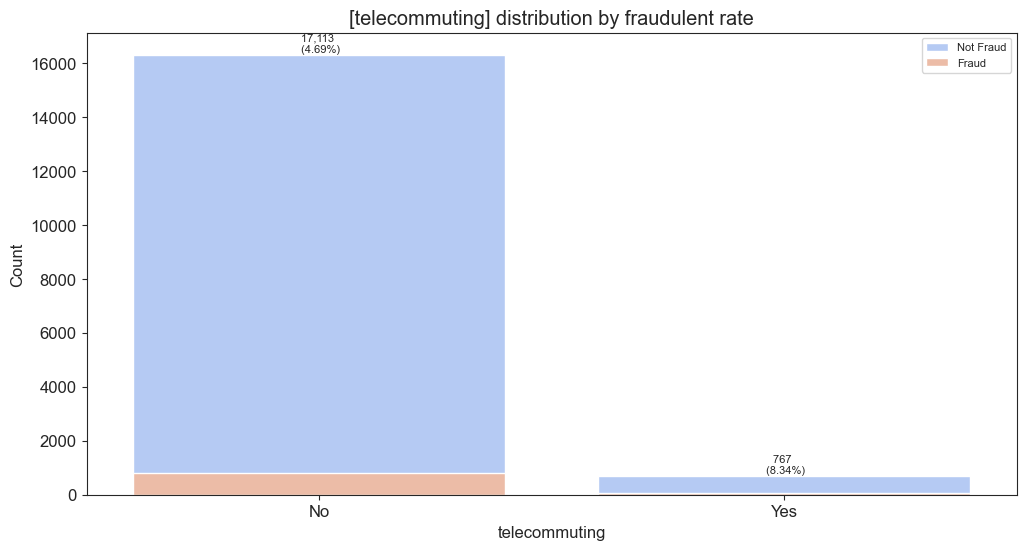

In [30]:
fea = 'telecommuting'
plot_cate_by_label_rate(fea, df, title=None, fontsize=8)

### 3.2.2 [has_company_logo]

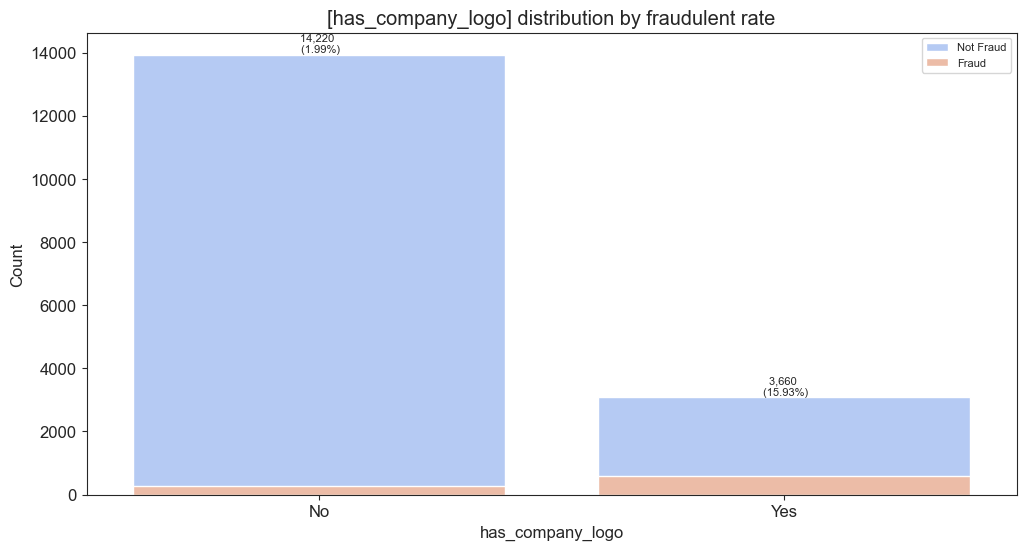

In [31]:
fea = 'has_company_logo'
plot_cate_by_label_rate(fea, df, title=None, fontsize=8)

## 3.2.3 [has_questions]

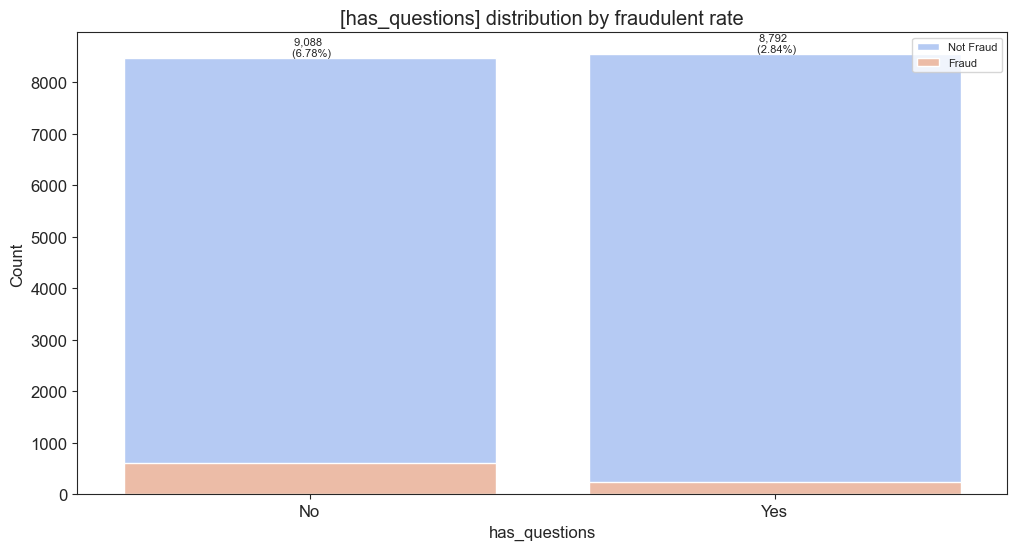

In [32]:
fea = 'has_questions'
plot_cate_by_label_rate(fea, df, title=None, fontsize=8)

## 3.3 Multinomial categorical features by missing value percentage in the ascending order

- location - Job geographical location in the ad post.(Contain Country, State/Province, City/Area, *Categorical* 2% Missing)
- employment_type - Category of Employment provided for the Employees.(*Categorical*, 19% Missing)
- Industry - Domain in which the Company. (*Categorical*, 27% Missing)
- Function - Type of Profession the Company follows.(*Categorical*, 36% Missing)
- required_experience - Type of the previous experience required from the employees.(*Categorical/Oridinal*, 39% Missing)
- required_education - Education qualifications required from the employees.(*Categorical/Oridinal*, 45% Missing)
- department - Corporate departments, like Sales.(*Categorical*, 65% Missing)
- salary_range - Indicative range for salary listed by the Employer, like $50,000-$60,000.(*Categorical*, 84% Missing)

**We can potentially impute the missing values via some methods, but we chose not to but filling with 'unknown' as placeholders for the sake of preserving the original data structure and study the potential correlation between the missing value occurrences with the job posting being fraudulent, given the missing mechanism remains unclear.**

### 3.3.1 Location 

- 2% missing
- we can see that the Format of the Data present is : **Country Name(Abbreviated) , State Name(Abbreviated) , City Name / Area Name.** We just extract the country into a new categorical column [Country] with cardinality of 87. 
- The standardized [location] column will be considered as a member of the textual packs and treated along with the rest of the pack.

In [20]:
# convert df['location'] to lower cases
df['location'] = df['location'].str.lower()

# fill the missing values in the 'location' column with 'unknown, unknown, unknown'
imputer = SimpleImputer(strategy='constant', fill_value='unknown, unknown, unknown')
df['location'] = imputer.fit_transform(df['location'].values.reshape(-1, 1)).ravel()
# which rows in the 'location' column that has no comma
df['location'].str.contains(',').value_counts()

location
True     17786
False       94
Name: count, dtype: int64

In [21]:
# if a string in the 'location' column has no comma, append ', , ' to the end of the string
df['location'] = df['location'].astype(str).apply(lambda x: x+', , ' if ',' not in x else x)

# if a string in the 'location' column ends with ', , ',  replace the ', , ' part with ', unknown, unknown'
df['location'] = df['location'].apply(lambda x: x.replace(', , ', ', unknown, unknown') if x.endswith(', , ') else x)
df['location'].value_counts()

location
gb, lnd, london                732
us, ny, new york               671
us, ca, san francisco          480
gr, i, athens                  472
us, unknown, unknown           402
                              ... 
gb, hmf, london                  1
us, wa, skagit county            1
us, mi, cassopolis dowagiac      1
us, , seattle                    1
gb, wsx, chichester              1
Name: count, Length: 2920, dtype: int64

Lets first work on gb, using this iso acronym helper, https://www.iso.org/obp/ui/#iso:code:3166:GB. 

In [22]:
# change the following to 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('shoreditch'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('notting hill'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('kingston'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('sry,'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('victoria'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('farringdon'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('fulham'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hoxton'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('camden'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('middlesex'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('soho'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('twickenham'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb, lnd, '), 'location' ] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('london'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('lon'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('lod'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('heathrow'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('gatwick'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('teddington'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('cry,'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('west drayton'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hns,'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ben,'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('enf,'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('silvertown'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('united kingdom'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('watford'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('croydon'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('greenwich'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('uxbridge'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ktt,'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains(', lo'), 'location'] = 'gb, london, london'

# change the following to 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('birm'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('solihull'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('coventry'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('wolverhampton'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bir,'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('walsall'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('tamworth'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains(' telford'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('nuneaton'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('west bromwich'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('shrewsbury'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hampton in arden'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bmh,'), 'location'] = 'gb, west midlands, birmingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('wlv,'), 'location'] = 'gb, west midlands, birmingham'

#  change the following to 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('lds'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('leeds'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('mirfield'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ossett'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('birstall'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('batley'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('pontefract'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('wakefield'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bradford'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('halifax'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('huddersfield'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('brighouse'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('west yorkshire'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('kir,'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('dewsbury'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hathersage'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('chesterfield'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('crigglestone'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('grange moore'), 'location'] = 'gb, west yorkshire, leeds'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('brd,'), 'location'] = 'gb, west yorkshire, leeds'

# replace 'Sheffield' by 'gb, south yorkshire, sheffield'
df.loc[df['location'].str.contains('sheffield', na=False), 'location'] = 'gb, south yorkshire, sheffield'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('south y'), 'location'] = 'gb, south yorkshire, sheffield'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('shf'), 'location'] = 'gb, south yorkshire, sheffield'
df.loc[df['location'].str.contains('gb, , see the requirements section for areas and locations available', na=False), 'location'] = 'gb, south yorkshire, sheffield'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('doncaster'), 'location'] = 'gb, south yorkshire, sheffield'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('barnsley'), 'location'] = 'gb, south yorkshire, sheffield'

# replace 'harrogate' by 'gb, north yorkshire, harrogate'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('nyk'), 'location'] = 'gb, north yorkshire, harrogate'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('skipton'), 'location'] = 'gb, north yorkshire, harrogate'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('harrogate'), 'location'] = 'gb, north yorkshire, harrogate'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('malton'), 'location'] = 'gb, north yorkshire, harrogate'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('thirsk'), 'location'] = 'gb, north yorkshire, harrogate'

# change the following to 'gb, east yorkshire, hessle'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ery,'), 'location'] = 'gb, east yorkshire, hull'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('yor,'), 'location'] = 'gb, east yorkshire, hull'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hull'), 'location'] = 'gb, east yorkshire, hull'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hessle'), 'location'] = 'gb, east yorkshire, hull'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('various'), 'location'] = 'gb, east yorkshire, hull'

# change the following to 'gb, greater manchester, manchester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('man,'), 'location'] = 'gb, greater manchester, manchester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('manc'), 'location'] = 'gb, greater manchester, manchester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('salford'), 'location'] = 'gb, greater manchester, manchester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('cheadle'), 'location'] = 'gb, greater manchester, manchester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('oldham'), 'location'] = 'gb, greater manchester, manchester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('trf,'), 'location'] = 'gb, greater manchester, manchester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('urmston'), 'location'] = 'gb, greater manchester, manchester'

# change the following to 'gb, merseyside, liverpool'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('liver'), 'location'] = 'gb, merseyside, liverpool'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('liv'), 'location'] = 'gb, merseyside, liverpool'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('southport'), 'location'] = 'gb, merseyside, liverpool'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('wirral'), 'location'] = 'gb, merseyside, liverpool'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('wrl,'), 'location'] = 'gb, merseyside, liverpool'
# change the following to 'gb, scotland, glasgow'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('glasgow'), 'location'] = 'gb, scotland, glasgow'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('glg'), 'location'] = 'gb, scotland, glasgow'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('agb,'), 'location'] = 'gb, scotland, glasgow'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('stirling'), 'location'] = 'gb, scotland, glasgow'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ayr'), 'location'] = 'gb, scotland, glasgow'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ant,'), 'location'] = 'gb, scotland, glasgow'

# change the following to 'gb, scotland, edinburgh'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('edin'), 'location'] = 'gb, scotland, edinburgh'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('edh'), 'location'] = 'gb, scotland, edinburgh'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('west lothian'), 'location'] = 'gb, scotland, edinburgh'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('sct,'), 'location'] = 'gb, scotland, edinburgh'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('falkirk'), 'location'] = 'gb, scotland, edinburgh'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('arm,'), 'location'] = 'gb, scotland, edinburgh'

# change the following to 'gb, scotland, aberdeen'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('aberdeen'), 'location'] = 'gb, scotland, aberdeen'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('abe'), 'location'] = 'gb, scotland, aberdeen'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('abd,'), 'location'] = 'gb, scotland, aberdeen'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('shetland'), 'location'] = 'gb, scotland, aberdeen'

# change the following to 'gb, scotland, dundee'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('dundee'), 'location'] = 'gb, scotland, dundee'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ans,'), 'location'] = 'gb, scotland, dundee'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('meigle'), 'location'] = 'gb, scotland, dundee'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('pkn,'), 'location'] = 'gb, scotland, dundee'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('fife'), 'location'] = 'gb, scotland, dundee'

# change the following to 'gb, northern ireland, belfast'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('belfast'), 'location'] = 'gb, northern ireland, belfast'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('nir,'), 'location'] = 'gb, northern ireland, belfast'

# change the following to 'gb, bristol, bristol'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bristol'), 'location'] = 'gb, bristol, bristol'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('som,'), 'location'] = 'gb, bristol, bristol'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bst,'), 'location'] = 'gb, bristol, bristol'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bath'), 'location'] = 'gb, bristol, bristol'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('crf'), 'location'] = 'gb, bristol, bristol'

# change the following to 'gb, essex, chelmsford'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('chelmsford'), 'location'] = 'gb, essex, chelmsford'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('colche'), 'location'] = 'gb, essex, chelmsford'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('southend'), 'location'] = 'gb, essex, chelmsford'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ess,'), 'location'] = 'gb, essex, chelmsford'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('essex'), 'location'] = 'gb, essex, chelmsford'

# change the below to 'gb, leicestershire, leicester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('leicester'), 'location'] = 'gb, leicestershire, leicester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('lec,'), 'location'] = 'gb, leicestershire, leicester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('lce,'), 'location'] = 'gb, leicestershire, leicester'

# change the below to 'gb, oxfordshire, oxford'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('oxford'), 'location'] = 'gb, oxfordshire, oxford'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('oxf,'), 'location'] = 'gb, oxfordshire, oxford'

# change the below to 'gb, buckinghamshire, milton keynes'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('milton'), 'location'] = 'gb, buckinghamshire, milton keynes'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bkm'), 'location'] = 'gb, buckinghamshire, milton keynes'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('high wycombe'), 'location'] = 'gb, buckinghamshire, milton keynes'

# change the below to 'gb, nottinghamshire, nottingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('nottingham'), 'location'] = 'gb, nottinghamshire, nottingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ngm,'), 'location'] = 'gb, nottinghamshire, nottingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ntt'), 'location'] = 'gb, nottinghamshire, nottingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('nth,'), 'location'] = 'gb, nottinghamshire, nottingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('mansfield'), 'location'] = 'gb, nottinghamshire, nottingham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('der,'), 'location'] = 'gb, nottinghamshire, nottingham'

# change the below to 'gb, bedordshire, luton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('luton'), 'location'] = 'gb, bedfordshire, luton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('lut'), 'location'] = 'gb, bedfordshire, luton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bedford'), 'location'] = 'gb, bedfordshire, luton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('leighton buzzard'), 'location'] = 'gb, bedfordshire, luton'

# change the below to 'gb, lancashire, preston'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('preston'), 'location'] = 'gb, lancashire, preston'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('blackpool'), 'location'] = 'gb, lancashire, preston'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('wigan'), 'location'] = 'gb, lancashire, preston'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('lan,'), 'location'] = 'gb, lancashire, preston'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bpl,'), 'location'] = 'gb, lancashire, preston'

# change the below to 'gb, hertfordshire, hemel hempstead'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hemel'), 'location'] = 'gb, hertfordshire, hemel hempstead'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hrt,'), 'location'] = 'gb, hertfordshire, hemel hempstead'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hef,'), 'location'] = 'gb, hertfordshire, hemel hempstead'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hertfordshire'), 'location'] = 'gb, hertfordshire, hemel hempstead'

#replace 'gb,' and 'Durham' by 'GB, Durham, Durham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('durham'), 'location'] = 'gb, durham, durham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('dur'), 'location'] = 'gb, durham, durham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hartlepool'), 'location'] = 'gb, durham, durham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('stt,'), 'location'] = 'gb, durham, durham'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('snd,'), 'location'] = 'gb, durham, durham'

# change the below to 'gb, tyne and wear, newcastle'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('newcastle'), 'location'] = 'gb, tyne and wear, newcastle'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('net,'), 'location'] = 'gb, tyne and wear, newcastle'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('gateshead'), 'location'] = 'gb, tyne and wear, newcastle'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('north east'), 'location'] = 'gb, tyne and wear, newcastle'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('nbl,'), 'location'] = 'gb, tyne and wear, newcastle'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('sunderland'), 'location'] = 'gb, tyne and wear, newcastle'

# change the below to 'gb, west sussex, chichester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('chichester'), 'location'] = 'gb, west sussex, chichester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('wsx,'), 'location'] = 'gb, west sussex, chichester'

# change the below to 'gb, east sussex, brighton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('brighton'), 'location'] = 'gb, east sussex, brighton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bnh,'), 'location'] = 'gb, east sussex, brighton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('esx,'), 'location'] = 'gb, east sussex, brighton'

# change the below to 'gb, cambridgeshire, cambridge'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('cambridge'), 'location'] = 'gb, cambridgeshire, cambridge'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('cam,'), 'location'] = 'gb, cambridgeshire, cambridge'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('peterboroug'), 'location'] = 'gb, cambridgeshire, cambridge'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('pte,'), 'location'] = 'gb, cambridgeshire, cambridge'

# change the below to 'gb, cheshire, chester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains(' , chester'), 'location'] = 'gb, cheshire, chester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bodel'), 'location'] = 'gb, cheshire, chester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('chw,'), 'location'] = 'gb, cheshire, chester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('che,'), 'location'] = 'gb, cheshire, chester'

# change the below to 'gb, wiltshire, swindon'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('swindon'), 'location'] = 'gb, wiltshire, swindon'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('swd,'), 'location'] = 'gb, wiltshire, swindon'

# change the below to 'gb, hampshire, southampton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('southampton'), 'location'] = 'gb, hampshire, southampton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains(' ham,'), 'location'] = 'gb, hampshire, southampton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('sth,'), 'location'] = 'gb, hampshire, southampton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('portsmouth'), 'location'] = 'gb, hampshire, southampton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('basingstoke'), 'location'] = 'gb, hampshire, southampton'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('iow,'), 'location'] = 'gb, hampshire, southampton'

# change the following to 'gb, worcestershire, worcester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('wor,'), 'location'] = 'gb, worcestershire, worcester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('gloucester'), 'location'] = 'gb, worcestershire, worcester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('gls,'), 'location'] = 'gb, worcestershire, worcester'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('cheltenham'), 'location'] = 'gb, worcestershire, worcester'

# change the following to 'gb, staffordshire, stoke-on-trent'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('stoke'), 'location'] = 'gb, staffordshire, stoke-on-trent'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ste,'), 'location'] = 'gb, staffordshire, stoke-on-trent'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('sts,'), 'location'] = 'gb, staffordshire, stoke-on-trent'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('chelmorton'), 'location'] = 'gb, staffordshire, stoke-on-trent'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('hanley'), 'location'] = 'gb, staffordshire, stoke-on-trent'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bangor'), 'location'] = 'gb, staffordshire, stoke-on-trent'

# change the following to 'gb, suffolk, ipswich'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ipswich'), 'location'] = 'gb, suffolk, ipswich'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('sfk,'), 'location'] = 'gb, suffolk, ipswich'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('suffolk'), 'location'] = 'gb, suffolk, ipswich'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bury st edmunds'), 'location'] = 'gb, suffolk, ipswich'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('norwich'), 'location'] = 'gb, suffolk, ipswich'

# change the following to 'gb, dorset, bournemouth'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bournemouth'), 'location'] = 'gb, dorset, bournemouth'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('dor,'), 'location'] = 'gb, dorset, bournemouth'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('poole'), 'location'] = 'gb, dorset, bournemouth'

# change the following to 'gb, kent, maidstone'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('kent'), 'location'] = 'gb, kent, maidstone'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ken,'), 'location'] = 'gb, kent, maidstone'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('cantebury'), 'location'] = 'gb, kent, maidstone'

# change the following to 'gb, lincolnshire, lincoln'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('lincoln'), 'location'] = 'gb, lincolnshire, lincoln'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('lin,'), 'location'] = 'gb, lincolnshire, lincoln'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('scunthorpe'), 'location'] = 'gb, lincolnshire, lincoln'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('immingham'), 'location'] = 'gb, lincolnshire, lincoln'

# change the following to 'gb, berkshire, reading'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('reading'), 'location'] = 'gb, berkshire, reading'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('wbk,'), 'location'] = 'gb, berkshire, reading'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('rdg,'), 'location'] = 'gb, berkshire, reading'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('bracknell'), 'location'] = 'gb, berkshire, reading'

# change the following to 'gb, devon, plymouth'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('con,'), 'location'] = 'gb, devon, plymouth'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('corn'), 'location'] = 'gb, devon, plymouth'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('launceston'), 'location'] = 'gb, devon, plymouth'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('ply,'), 'location'] = 'gb, devon, plymouth'

# change the following to 'gb, cumbria, penrith'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('cma,'), 'location'] = 'gb, cumbria, penrith'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('carlisle'), 'location'] = 'gb, cumbria, penrith'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('north west'), 'location'] = 'gb, cumbria, penrith'

# change the following to 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('work from home'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb,') & df['location'].str.contains('unknown, unknown'), 'location'] = 'gb, london, london'
df.loc[df['location'].str.contains('gb, '), 'location' ].value_counts(ascending=False).head(50)

location
gb, london, london                    1564
gb, west yorkshire, leeds              124
gb, west midlands, birmingham           78
gb, greater manchester, manchester      68
gb, scotland, edinburgh                 43
gb, bristol, bristol                    36
gb, scotland, glasgow                   31
gb, essex, chelmsford                   30
gb, north yorkshire, harrogate          30
gb, scotland, aberdeen                  28
gb, south yorkshire, sheffield          28
gb, tyne and wear, newcastle            24
gb, merseyside, liverpool               22
gb, durham, durham                      21
gb, lancashire, preston                 19
gb, nottinghamshire, nottingham         17
gb, scotland, dundee                    16
gb, hampshire, southampton              14
gb, buckinghamshire, milton keynes      14
gb, hertfordshire, hemel hempstead      14
gb, cambridgeshire, cambridge           14
gb, leicestershire, leicester           13
gb, cheshire, chester                   12
gb

work on the Sweden and Denmark, Norway, Finland, Ireland, Iceland, estonia, lithuania, latvia, Belarus, Ukraine, Romania, Poland, Czechia, Slovakia, Hungary, Austria, Germany, Netherlands, Belgium, Luxembourg, France, Switzerland, Spain, Portugal, Italy, Malta, Slovenia, Croatia, Bosnia, Serbia, Montenegro, North Macedonia, Albania, Greece, Turkey, Cyprus

In [23]:
# change the following to 'se, stockholm county, stockholm'
df.loc[df['location'].str.contains('se, ') & df['location'].str.contains('stockholm'), 'location'] = 'se, stockholm county, stockholm'
df.loc[df['location'].str.contains('gb, ') & df['location'].str.contains('stockholm'), 'location'] = 'se, stockholm county, stockholm'
df.loc[df['location'].str.contains('se, ') & df['location'].str.contains('unknown'), 'location'] = 'se, stockholm county, stockholm'

# change the following to 'se, gotlands county, visby'
df.loc[df['location'].str.contains('se, ') & df['location'].str.contains('visby'), 'location'] = 'se, gotlands county, visby'

# change the following to 'se, kronoberg county, växjö'
df.loc[df['location'].str.contains('se, ') & df['location'].str.contains('växjö'), 'location'] = 'se, kronoberg county, växjö'

# change the following to 'se, skåne county, lund'
df.loc[df['location'].str.contains('se, ') & df['location'].str.contains('lund'), 'location'] = 'se, skåne county, lund'

# change the following to 'dk, copenhagen region, copenhagen'
df.loc[df['location'].str.contains('dk, ') & df['location'].str.contains('copenhag'), 'location'] = 'dk, copenhagen region, copenhagen'
df.loc[df['location'].str.contains('dk, ') & df['location'].str.contains('84,'), 'location'] = 'dk, copenhagen region, copenhagen'
df.loc[df['location'].str.contains('dk, ') & df['location'].str.contains('ballerup'), 'location'] = 'dk, copenhagen region, copenhagen'
df.loc[df['location'].str.contains('dk, ') & df['location'].str.contains('home'), 'location'] = 'dk, copenhagen region, copenhagen'
df.loc[df['location'].str.contains('dk, ') & df['location'].str.contains('unknown'), 'location'] = 'dk, copenhagen region, copenhagen'

# change the following to 'dk, central denmark region, aarhus'
df.loc[df['location'].str.contains('dk, ') & df['location'].str.contains('aarhus'), 'location'] = 'dk, central denmark region, aarhus'

# change the following to 'no, oslo county, oslo'
df.loc[df['location'].str.contains('no, ') & df['location'].str.contains('oslo'), 'location'] = 'no, oslo county, oslo'
df.loc[df['location'].str.contains('no, ') & df['location'].str.contains('03,'), 'location'] = 'no, oslo county, oslo'
df.loc[df['location'].str.contains('no, ') & df['location'].str.contains('home'), 'location'] = 'no, oslo county, oslo'

# change the following to 'fi, uusimaa, helsinki'
df.loc[df['location'].str.contains('fi, ') & df['location'].str.contains('helsinki'), 'location'] = 'fi, uusimaa, helsinki'
df.loc[df['location'].str.contains('fi, ') & df['location'].str.contains('home'), 'location'] = 'fi, uusimaa, helsinki'
df.loc[df['location'].str.contains('fi, ') & df['location'].str.contains('unknown'), 'location'] = 'fi, uusimaa, helsinki'

# change the following to 'fi, western finland, turku'
df.loc[df['location'].str.contains('fi, ') & df['location'].str.contains('turku'), 'location'] = 'fi, western finland, turku'

# change the following to 'fi, northern finland, oulu'
df.loc[df['location'].str.contains('fi, ') & df['location'].str.contains('oulu'), 'location'] = 'fi, northern finland, oulu'

# change the following to 'ie, leinster, dublin'
df.loc[df['location'].str.contains('ie, ') & df['location'].str.contains('dublin'), 'location'] = 'ie, leinster, dublin'
df.loc[df['location'].str.contains('ie, ') & df['location'].str.contains('dubin'), 'location'] = 'ie, leinster, dublin'
df.loc[df['location'].str.contains('ie, ') & df['location'].str.contains(' city'), 'location'] = 'ie, leinster, dublin'
df.loc[df['location'].str.contains('ie, ') & df['location'].str.contains('from home'), 'location'] = 'ie, leinster, dublin'
df.loc[df['location'].str.contains('ie, ') & df['location'].str.contains('unknown'), 'location'] = 'ie, leinster, dublin'

# change the following to 'ie, munster, cork'
df.loc[df['location'].str.contains('ie, ') & df['location'].str.contains('cork'), 'location'] = 'ie, munster, cork'
df.loc[df['location'].str.contains('gb, ') & df['location'].str.contains('cork'), 'location'] = 'ie, munster, cork'

# change the following to 'is, reykjavik, reykjavik'
df.loc[df['location'].str.contains('is, ') & df['location'].str.contains('reykjavik'), 'location'] = 'is, reykjavik, reykjavik'
df.loc[df['location'].str.contains('is, ') & df['location'].str.contains('unk'), 'location'] = 'is, reykjavik, reykjavik'
# change the following to 'ee, harju county, tallinn'
df.loc[df['location'].str.contains('ee, ') & df['location'].str.contains('tallinn'), 'location'] = 'ee, harju county, tallinn'
df.loc[df['location'].str.contains('ee, ') & df['location'].str.contains('37'), 'location'] = 'ee, harju county, tallinn'
df.loc[df['location'].str.contains('ee, ') & df['location'].str.contains('unk'), 'location'] = 'ee, harju county, tallinn'

# change the following to 'lt, vilnius region, vilnius'
df.loc[df['location'].str.contains('lt, ') & df['location'].str.contains('vilnius'), 'location'] = 'lt, vilnius region, vilnius'
df.loc[df['location'].str.contains('lt, ') & df['location'].str.contains('unknown'), 'location'] = 'lt, vilnius region, vilnius'
# change the following to 'lt, kaunas region, kaunas'
df.loc[df['location'].str.contains('lt, ') & df['location'].str.contains('kaunas'), 'location'] = 'lt, kaunas region, kaunas'

# change the following to 'lv, riga region, riga'
df.loc[df['location'].str.contains('lv, ') & df['location'].str.contains('riga'), 'location'] = 'lv, riga region, riga'
# change the following to 'by, minsk oblast, minsk'
df.loc[df['location'].str.contains('by, ') & df['location'].str.contains('minsk'), 'location'] = 'by, minsk oblast, minsk'

# change the following to 'ua, cherkasy oblast, cherkasy'
df.loc[df['location'].str.contains('ua, ') & df['location'].str.contains('71,'), 'location'] = 'ua, cherkasy oblast, cherkasy'

# change the following to 'ua, kyiv city, kyiv'
df.loc[df['location'].str.contains('ua, ') & df['location'].str.contains('kiev'), 'location'] = 'ua, kyiv city, kyiv'
df.loc[df['location'].str.contains('ua, ') & df['location'].str.contains('40'), 'location'] = 'ua, kyiv city, kyiv'
df.loc[df['location'].str.contains('ua, ') & df['location'].str.contains('unknown'), 'location'] = 'ua, kyiv city, kyiv'

# change the following to 'ua, ternopil oblast, ternopil'
df.loc[df['location'].str.contains('ua, ') & df['location'].str.contains('61,'), 'location'] = 'ua, ternopil oblast, ternopil'

# change the following to 'ua, kharkiv oblast, kharkiv'
df.loc[df['location'].str.contains('ua, ') & df['location'].str.contains('kharkov'), 'location'] = 'ua, kharkiv oblast, kharkiv'

# change the following to 'ro, București, bucharest'
df.loc[df['location'].str.contains('ro, ') & df['location'].str.contains('bucharest'), 'location'] = 'ro, București, bucharest'
df.loc[df['location'].str.contains('ro, ') & df['location'].str.contains('b,'), 'location'] = 'ro, București, bucharest'
df.loc[df['location'].str.contains('ro, ') & df['location'].str.contains('unknown'), 'location'] = 'ro, București, bucharest'
df.loc[df['location'].str.contains('ro, ') & df['location'].str.contains('iasi'), 'location']  = 'ro, București, bucharest'
# change the following to 'ro, cluj region, cluj-napoca'
df.loc[df['location'].str.contains('ro, ') & df['location'].str.contains('cluj'), 'location'] = 'ro, cluj region, cluj-napoca'

# change the following to 'ro, timiș region, timișoara'
df.loc[df['location'].str.contains('ro, ') & df['location'].str.contains('timi'), 'location'] = 'ro, timiș region, timișoara'

# change the following to 'bg, sofia province, sofia'
df.loc[df['location'].str.contains('bg, ') & df['location'].str.contains('sofia'), 'location'] = 'bg, sofia province, sofia'
df.loc[df['location'].str.contains('bg, ') & df['location'].str.contains('23,'), 'location'] = 'bg, sofia province, sofia'
df.loc[df['location'].str.contains('bg, ') & df['location'].str.contains('unknown'), 'location'] = 'bg, sofia province, sofia'

# change the following to 'pl, mazowieckie, warsaw'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('warsaw'), 'location'] = 'pl, mazowieckie, warsaw'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('mz,'), 'location'] = 'pl, mazowieckie, warsaw'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('warszawa'), 'location'] = 'pl, mazowieckie, warsaw'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('poland'), 'location'] = 'pl, mazowieckie, warsaw'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('remote'), 'location']  = 'pl, mazowieckie, warsaw'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('unknown'), 'location'] = 'pl, mazowieckie, warsaw' 

# change the following to 'pl, małopolskie, kraków'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('krakow'), 'location'] = 'pl, małopolskie, kraków'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('małopolskie'), 'location'] = 'pl, małopolskie, kraków'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('ma,'), 'location'] = 'pl, małopolskie, kraków'

# change the following to 'pl, dolnośląskie, wrocław'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('wrocław'), 'location'] = 'pl, dolnośląskie, wrocław'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('ds,'), 'location'] = 'pl, dolnośląskie, wrocław'

# change the following to 'pl, wielkopolskie, poznań'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('poznań'), 'location'] = 'pl, wielkopolskie, poznań'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('wp,'), 'location'] = 'pl, wielkopolskie, poznań'

# change the following to 'pl, pomorskie, gdańsk'
df.loc[df['location'].str.contains('pl, ') & df['location'].str.contains('gdańsk'), 'location'] = 'pl, pomorskie, gdańsk'

# change the following to 'cz, prague, prague'
df.loc[df['location'].str.contains('cz, ') & df['location'].str.contains('pr,'), 'location'] = 'cz, prague, prague'

# change the following to 'sk, bratislava, bratislava'
df.loc[df['location'].str.contains('sk, ') & df['location'].str.contains('bl,'), 'location'] = 'sk, bratislava, bratislava'

# change the following to 'hu, budapest, budapest'
df.loc[df['location'].str.contains('hu, ') & df['location'].str.contains('budapest'), 'location'] = 'hu, budapest, budapest'
df.loc[df['location'].str.contains('hu, ') & df['location'].str.contains('bu,'), 'location'] = 'hu, budapest, budapest'
df.loc[df['location'].str.contains('hu, ') & df['location'].str.contains('unk'), 'location'] = 'hu, budapest, budapest'

# change the following to 'at, vienna, vienna'
df.loc[df['location'].str.contains('at, ') & df['location'].str.contains('vienna'), 'location'] = 'at, vienna, vienna'
df.loc[df['location'].str.contains('at, ') & df['location'].str.contains('9,'), 'location'] = 'at, vienna, vienna'
df.loc[df['location'].str.contains('at, ') & df['location'].str.contains('unknown'), 'location'] = 'at, vienna, vienna'
# change the following to 'at, salzburg, salzburg'
df.loc[df['location'].str.contains('at, ') & df['location'].str.contains('salzburg'), 'location'] = 'at, salzburg, salzburg'
df.loc[df['location'].str.contains('at, ') & df['location'].str.contains('5,'), 'location'] = 'at, salzburg, salzburg'

# change the following to 'de, berlin, berlin'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('berlin'), 'location'] = 'de, berlin, berlin'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('be,'), 'location'] = 'de, berlin, berlin'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('germany'), 'location'] = 'de, berlin, berlin'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('unknown'), 'location'] = 'de, berlin, berlin'

# change the following to 'de, bavaria, munich'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('munich'), 'location'] = 'de, bavaria, munich'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('münchen'), 'location'] = 'de, bavaria, munich'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('by,'), 'location'] = 'de, bavaria, munich'

# change the following to 'de, hesse, frankfurt'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('frankfurt'), 'location'] = 'de, hesse, frankfurt'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('he,'), 'location'] = 'de, hesse, frankfurt'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('rp,'), 'location'] = 'de, hesse, frankfurt'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('bw,'), 'location'] = 'de, hesse, frankfurt'

# change the following to 'de, hamburg, hamburg'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('hamburg'), 'location'] = 'de, hamburg, hamburg'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('hh,'), 'location'] = 'de, hamburg, hamburg'

# change the following to 'de, north rhine-westphalia, cologne'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('dortmund'), 'location'] = 'de, north rhine-westphalia, cologne'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('nw,'), 'location'] = 'de, north rhine-westphalia, cologne'

# change the following to 'de, saxony, leipzig'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('leipzig'), 'location'] = 'de, saxony, leipzig'

# change the following to 'de, rhineland-palatinate, mainz'
df.loc[df['location'].str.contains('de, ') & df['location'].str.contains('rp,'), 'location'] = 'de, rhineland-palatinate, mainz'

# change the following to 'nl, north holland, amsterdam'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('amsterdam'), 'location'] = 'nl, north holland, amsterdam'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('nh,'), 'location'] = 'nl, north holland, amsterdam'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('home'), 'location'] = 'nl, north holland, amsterdam'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('unknown'), 'location'] = 'nl, north holland, amsterdam'
# change the following to 'nl, south holland, rotterdam'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('rotterdam'), 'location'] = 'nl, south holland, rotterdam'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('zh,'), 'location'] = 'nl, south holland, rotterdam'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('the hague'), 'location'] = 'nl, south holland, rotterdam'

# change the following to 'nl, north brabant, eindhoven'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('eindhoven'), 'location'] = 'nl, north brabant, eindhoven'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('nb,'), 'location'] = 'nl, north brabant, eindhoven'

# change the following to 'nl, utrecht, amersfoort'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('amersfoort'), 'location'] = 'nl, utrecht, amersfoort'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('ut,'), 'location'] = 'nl, utrecht, amersfoort'

# change the following to 'nl, drenhte, assen'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('assen'), 'location'] = 'nl, drenhte, assen'
df.loc[df['location'].str.contains('nl, ') & df['location'].str.contains('ov,'), 'location'] = 'nl, drenhte, assen'

# change the following to 'be, brussels, brussels'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('brussels'), 'location'] = 'be, brussels, brussels'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('bru,'), 'location'] = 'be, brussels, brussels'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('leuven'), 'location'] = 'be, brussels, brussels'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('vbr,'), 'location'] = 'be, brussels, brussels'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('home'), 'location'] = 'be, brussels, brussels'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('unknown'), 'location'] = 'be, brussels, brussels'

# change the following to 'be, Oost-Vlaanderen, ghent'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('ghent'), 'location'] = 'be, oost-vlaanderen, ghent'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('vov,'), 'location'] = 'be, oost-vlaanderen, ghent'

# change the following to 'be, antwerpen, antwerp'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('antwerp'), 'location'] = 'be, antwerpen, antwerp'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('van,'), 'location'] = 'be, antwerpen, antwerp'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('lommel'), 'location'] = 'be, antwerpen, antwerp'

# change the following to 'lu, luxembourg, luxembourg'
df.loc[df['location'].str.contains('lu, ') & df['location'].str.contains('lu,'), 'location'] = 'lu, luxembourg, luxembourg'

# change the following to 'fr, paris, paris'
df.loc[df['location'].str.contains('fr, ') & df['location'].str.contains('paris'), 'location'] = 'fr, Île-de-France, paris'
df.loc[df['location'].str.contains('fr, ') & df['location'].str.contains('home'), 'location'] = 'fr, Île-de-France, paris'
df.loc[df['location'].str.contains('fr, ') & df['location'].str.contains('france'), 'location'] = 'fr, Île-de-France, paris'
df.loc[df['location'].str.contains('fr, ') & df['location'].str.contains('unknown'), 'location'] = 'fr, Île-de-France, paris'
# change the following to 'fr, marsielle, marsielle'
df.loc[df['location'].str.contains('fr, ') & df['location'].str.contains('u,'), 'location'] = 'fr, marsielle, marsielle'

# change the following to 'fr, occitanie, montpellier'
df.loc[df['location'].str.contains('fr, ') & df['location'].str.contains('montpellier'), 'location'] = 'fr, occitanie, montpellier'

# change the following to 'fr, hauts-de-france, lille'
df.loc[df['location'].str.contains('fr, ') & df['location'].str.contains('lille'), 'location'] = 'fr, hauts-de-france, lille'
df.loc[df['location'].str.contains('fr, ') & df['location'].str.contains('valenciennes'), 'location'] = 'fr, hauts-de-france, lille'
df.loc[df['location'].str.contains('be, ') & df['location'].str.contains('valenciennes'), 'location'] = 'fr, hauts-de-france, lille'
df.loc[df['location'].str.contains('be, , valanciennes'), 'location' ] = 'fr, hauts-de-france, lille'

# change the following to 'ch, zurich, zurich'
df.loc[df['location'].str.contains('ch, ') & df['location'].str.contains('zurich'), 'location'] = 'ch, zurich, zurich'
df.loc[df['location'].str.contains('ch, ') & df['location'].str.contains('zh,'), 'location'] = 'ch, zurich, zurich'

# change the following to 'ch, basel-stadt, basel'
df.loc[df['location'].str.contains('ch, ') & df['location'].str.contains('basel'), 'location'] = 'ch, basel-stadt, basel'
df.loc[df['location'].str.contains('ch, ') & df['location'].str.contains('vs,'), 'location'] = 'ch, basel-stadt, basel'
df.loc[df['location'].str.contains('ch, ') & df['location'].str.contains('ge,'), 'location'] = 'ch, basel-stadt, basel'
df.loc[df['location'].str.contains('ch, ') & df['location'].str.contains('home'), 'location'] = 'ch, basel-stadt, basel'

# change the following to 'es, madrid, madrid'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('madrid'), 'location'] = 'es, madrid, madrid'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('md,'), 'location'] = 'es, madrid, madrid'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('home'), 'location'] = 'es, madrid, madrid'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('unknown'), 'location'] = 'es, madrid, madrid'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('spain'), 'location'] = 'es, madrid, madrid'
# change the following to 'es, catalonia, barcelona'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('barcelona'), 'location'] = 'es, catalonia, barcelona'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('ct,'), 'location'] = 'es, catalonia, barcelona'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('lleida'), 'location'] = 'es, catalonia, barcelona'

# change the following to 'es, valencia, valencia'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('valencia'), 'location'] = 'es, valencia, valencia'

# change the following to 'es, andalusia, seville'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains('malaga'), 'location'] = 'es, andalusia, seville'
df.loc[df['location'].str.contains('es, ') & df['location'].str.contains(' cn,'), 'location'] = 'es, andalusia, seville'

# change the following to 'pt, lisbon, lisbon'
df.loc[df['location'].str.contains('pt, ') & df['location'].str.contains('lisbon'), 'location'] = 'pt, lisbon, lisbon'
df.loc[df['location'].str.contains('pt, ') & df['location'].str.contains('11,'), 'location'] = 'pt, lisbon, lisbon'
df.loc[df['location'].str.contains('pt, ') & df['location'].str.contains('unk'), 'location'] = 'pt, lisbon, lisbon'

# change the following to 'pt, porto, porto'
df.loc[df['location'].str.contains('pt, ') & df['location'].str.contains('porto'), 'location'] = 'pt, porto, porto'
df.loc[df['location'].str.contains('pt, ') & df['location'].str.contains('13,'), 'location'] = 'pt, porto, porto'

# change the following to 'pt, coimbra, coimbra'
df.loc[df['location'].str.contains('pt, ') & df['location'].str.contains('coimbra'), 'location'] = 'pt, coimbra, coimbra'

# change the following to 'mt, malta, valletta'
df.loc[df['location'].str.contains('mt, ') & df['location'].str.contains('56,'), 'location'] = 'mt, malta, valletta'
df.loc[df['location'].str.contains('mt, ') & df['location'].str.contains('sliema'), 'location'] = 'mt, malta, valletta'
df.loc[df['location'].str.contains('mt, ') & df['location'].str.contains('unknown'), 'location'] = 'mt, malta, valletta'

# change the following to 'it, lombardy, milan'
df.loc[df['location'].str.contains('it, ') & df['location'].str.contains('milan'), 'location'] = 'it, lombardy, milan'
df.loc[df['location'].str.contains('it, ') & df['location'].str.contains('torino'), 'location'] = 'it, lombardy, milan'

# change the following to 'it, lazio, rome'
df.loc[df['location'].str.contains('it, ') & df['location'].str.contains('rome'), 'location'] = 'it, lazio, rome'
df.loc[df['location'].str.contains('it, ') & df['location'].str.contains('unknown'), 'location'] = 'it, lazio, rome'
df.loc[df['location'].str.contains('it, ') & df['location'].str.contains('florence'), 'location'] = 'it, lazio, rome'
df.loc[df['location'].str.contains('it, ') & df['location'].str.contains('home'), 'location'] = 'it, lazio, rome'
df.loc[df['location'].str.contains('it, ') & df['location'].str.contains('italy'), 'location'] = 'it, lazio, rome'
df.loc[df['location'].str.contains('it, ') & df['location'].str.contains('unkn'), 'location'] = 'it, lazio, rome'
# change the following to 'si, ljubljana, ljubljana'
df.loc[df['location'].str.contains('si, ') & df['location'].str.contains('si,'), 'location'] = 'si, ljubljana, ljubljana'

# change the following to 'hr, zagreb, zagreb'
df.loc[df['location'].str.contains('hr, ') & df['location'].str.contains('21,'), 'location'] = 'hr, zagreb, zagreb'

# change the following to 'rs, belgrade, belgrade'
df.loc[df['location'].str.contains('rs, ') & df['location'].str.contains('vo,'), 'location'] = 'rs, belgrade, belgrade'
df.loc[df['location'].str.contains('rs, ') & df['location'].str.contains('00,'), 'location'] = 'rs, belgrade, belgrade'
df.loc[df['location'].str.contains('rs, ') & df['location'].str.contains('unk'), 'location'] = 'rs, belgrade, belgrade'

# change the following to 'al, tirana, tirana'
df.loc[df['location'].str.contains('al, ') & df['location'].str.contains('11,'), 'location'] = 'al, tirana, tirana'

# change the following to 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('athens'), 'location'] = 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('a1,'), 'location'] = 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('i,'), 'location'] = 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('then'), 'location'] = 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('halandri'), 'location'] = 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('marousi'), 'location'] = 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('mykonos'), 'location'] = 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('remote'), 'location'] = 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('unknown'), 'location'] = 'gr, attica, athens'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('greece'), 'location'] = 'gr, attica, athens'

# change the following to 'gr, central macedonia, thessaloniki'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('thessaloniki'), 'location'] = 'gr, central macedonia, thessaloniki'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('b,'), 'location'] = 'gr, central macedonia, thessaloniki'

# change the following to 'gr, thessaly, volos'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('volos'), 'location'] = 'gr, thessaly, volos'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains(' e, '), 'location'] = 'gr, thessaly, volos'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('lassi'), 'location'] = 'gr, thessaly, volos'

# change the following to 'gr, peloponnese, patras'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('patra'), 'location'] = 'gr, peloponnese, patras'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('g,'), 'location'] = 'gr, peloponnese, patras'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('j,'), 'location'] = 'gr, peloponnese, patras'

# change the following to 'gr, crete, heraklion'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('heraklion'), 'location'] = 'gr, crete, heraklion'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('m,'), 'location'] = 'gr, crete, heraklion'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('agios nikolaos'), 'location'] = 'gr, crete, heraklion'

# change the following to 'gr, eastern macedonia and thrace, komotini'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('komotini'), 'location'] = 'gr, eastern macedonia and thrace, komotini'

# change the following to 'gr, central greece, chalcis'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('chalkida'), 'location'] = 'gr, central greece, chalcis'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('ioannina'), 'location'] = 'gr, central greece, chalcis'
df.loc[df['location'].str.contains('gr, ') & df['location'].str.contains('h,'), 'location'] = 'gr, central greece, chalcis'

# change the following to 'tr, istanbul, istanbul'
df.loc[df['location'].str.contains('tr, ') & df['location'].str.contains('tr,'), 'location'] = 'tr, istanbul, istanbul'

# change the following to 'cy, nicosia, nicosia'
df.loc[df['location'].str.contains('cy, '), 'location'] = 'cy, nicosia, nicosia'

Work on Georgia, Armenia, Azerbaijan, Russia, 5-stans, China, Mongolia, Koreas, Japan, Philippines, New Zealand, Australia, New Guinea, Timor, Indonesia, Malaysia, Singapore, Brunei, Vietnam, Laos, Cambodia, Thailand, Myanmar, Bhutan, Nepal, Bangladesh, India, Sri Lanka, Maldives, Pakistan, Afghanistan, Iran, Irq, Syria, Kuwait, UAE, Oman, Qatar, Bahrain, Saudi Arabia, Yemen, Jordan, Lebanon, Israel, Palestine, Egypt, Libya, Tunisia, Algeria, Morocco

In [24]:
# change the following to 'am, yerevan, yerevan'
df.loc[df['location'].str.contains('am, ') & df['location'].str.contains('yere'), 'location'] = 'am, yerevan, yerevan'

# change the following to 'ru, moscow, moscow'
df.loc[df['location'].str.contains('ru, ') & df['location'].str.contains('moscow'), 'location'] = 'ru, moscow, moscow'
df.loc[df['location'].str.contains('ru, ') & df['location'].str.contains('mow,'), 'location'] = 'ru, moscow, moscow'
df.loc[df['location'].str.contains('ru, ') & df['location'].str.contains('unknown'), 'location'] = 'ru, moscow, moscow'

# change the following to 'ru, saint petersburg, saint petersburg'
df.loc[df['location'].str.contains('ru, ') & df['location'].str.contains('spe,'), 'location'] = 'ru, saint petersburg, saint petersburg'

# change the following to 'kz, almaty, almaty'
df.loc[df['location'].str.contains('kz, ') & df['location'].str.contains('ala'), 'location'] = 'kz, almaty, almaty'
# change the following to 'cn, beijing, beijing'
df.loc[df['location'].str.contains('cn, ') & df['location'].str.contains('11,'), 'location'] = 'cn, beijing, beijing'
df.loc[df['location'].str.contains('cn, ') & df['location'].str.contains('unkn'), 'location'] = 'cn, beijing, beijing'

# change the following to 'cn, shanghai, shanghai'
df.loc[df['location'].str.contains('cn, ') & df['location'].str.contains('31,'), 'location'] = 'cn, shanghai, shanghai'

# change the following to 'cn, guangdong, guangzhou'
df.loc[df['location'].str.contains('cn, ') & df['location'].str.contains('44,'), 'location'] = 'cn, guangdong, guangzhou'

# change the following to 'cn, sichuan, chengdu'
df.loc[df['location'].str.contains('cn, ') & df['location'].str.contains('51,'), 'location'] = 'cn, sichuan, chengdu'

# change the following to 'cn, hong kong, hong kong'
df.loc[df['location'].str.contains('hk, '), 'location'] = 'cn, hong kong, hong kong'

# change the following to 'cn, taiwan, taipei'
df.loc[df['location'].str.contains('tw, '), 'location'] = 'cn, taiwan, taipei'

# change the following to 'kr, gyeonggi, seoul'
df.loc[df['location'].str.contains('kr, ') & df['location'].str.contains('seoul'), 'location'] = 'kr, gyeonggi, seoul'
df.loc[df['location'].str.contains('kr, ') & df['location'].str.contains('41,'), 'location'] = 'kr, gyeonggi, seoul'
df.loc[df['location'].str.contains('kr, ') & df['location'].str.contains('incheon'), 'location'] = 'kr, gyeonggi, seoul'
df.loc[df['location'].str.contains('kr, ') & df['location'].str.contains('11,'), 'location'] = 'kr, gyeonggi, seoul'
df.loc[df['location'].str.contains('kr, ') & df['location'].str.contains('26,'), 'location'] = 'kr, gyeonggi, seoul'
df.loc[df['location'].str.contains('kr, ') & df['location'].str.contains('unk'), 'location'] = 'kr, gyeonggi, seoul'

# change the following to 'jp, tokyo, tokyo'
df.loc[df['location'].str.contains('jp, '), 'location'] = 'jp, tokyo, tokyo'

# change the following to 'ph, metro manila, manila'
df.loc[df['location'].str.contains('ph, '), 'location'] = 'ph, metro manila, manila'
# change the following to 'nz, auckland, auckland'
df.loc[df['location'].str.contains('nz, ') & df['location'].str.contains('auckland'), 'location'] = 'nz, auckland, auckland'
df.loc[df['location'].str.contains('nz, ') & df['location'].str.contains(' n,'), 'location'] = 'nz, auckland, auckland'
df.loc[df['location'].str.contains('nz, ') & df['location'].str.contains('unknown'), 'location'] = 'nz, auckland, auckland'

# change the following to 'nz, wellington, wellington'
df.loc[df['location'].str.contains('nz, ') & df['location'].str.contains('wellington'), 'location'] = 'nz, wellington, wellington'

# change the following to 'nz, canterbury, christchurch'
df.loc[df['location'].str.contains('nz, ') & df['location'].str.contains('christchurch'), 'location'] = 'nz, canterbury, christchurch'
df.loc[df['location'].str.contains('nz, ') & df['location'].str.contains('s,'), 'location'] = 'nz, canterbury, christchurch'

# change the following to 'au, new south wales, sydney'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('sydney'), 'location'] = 'au, new south wales, sydney'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('nsw,'), 'location'] = 'au, new south wales, sydney'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('act,'), 'location'] = 'au, new south wales, sydney'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('home'), 'location'] = 'au, new south wales, sydney'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('unknown'), 'location'] = 'au, new south wales, sydney'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('australia'), 'location'] = 'au, new south wales, sydney'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('nt, '), 'location'] = 'au, new south wales, sydney'

# change the following to 'au, victoria, melbourne'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('melbourne'), 'location'] = 'au, victoria, melbourne'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('vic,'), 'location'] = 'au, victoria, melbourne'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('adelaide'), 'location'] = 'au, victoria, melbourne'

# change the following to 'au, queensland, brisbane'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('brisbane'), 'location'] = 'au, queensland, brisbane'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('qld,'), 'location'] = 'au, queensland, brisbane'

# change the following to 'au, western australia, perth'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('perth'), 'location'] = 'au, western australia, perth'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('wa,'), 'location'] = 'au, western australia, perth'

# change the following to 'au, tasmania, hobart'
df.loc[df['location'].str.contains('au, ') & df['location'].str.contains('tas,'), 'location'] = 'au, tasmania, hobart'

# change the following to 'id, java, jakarta'
df.loc[df['location'].str.contains('id, ') & df['location'].str.contains('jakarta'), 'location'] = 'id, java, jakarta'
df.loc[df['location'].str.contains('id, ') & df['location'].str.contains('jw,'), 'location'] = 'id, java, jakarta'
df.loc[df['location'].str.contains('id, ') & df['location'].str.contains('unknown'), 'location'] = 'id, java, jakarta'

# change the following to 'id, sumatra, medan'
df.loc[df['location'].str.contains('id, ') & df['location'].str.contains('medan'), 'location'] = 'id, sumatra, medan'

# change the following to 'sg, singapore, singapore'
df.loc[df['location'].str.contains('sg, '), 'location'] = 'sg, singapore, singapore'

# change the following to 'my, kuala lumpur, kuala lumpur'
df.loc[df['location'].str.contains('my, ') & df['location'].str.contains('kuala lumpur'), 'location'] = 'my, kuala lumpur, kuala lumpur'
df.loc[df['location'].str.contains('my, ') & df['location'].str.contains('14,'), 'location'] = 'my, kuala lumpur, kuala lumpur'
df.loc[df['location'].str.contains('my, ') & df['location'].str.contains('16,'), 'location'] = 'my, kuala lumpur, kuala lumpur'
df.loc[df['location'].str.contains('my, ') & df['location'].str.contains('10,'), 'location'] = 'my, kuala lumpur, kuala lumpur'
df.loc[df['location'].str.contains('my, ') & df['location'].str.contains('unk'), 'location'] = 'my, kuala lumpur, kuala lumpur'

# change the following to 'my, penang, penang'
df.loc[df['location'].str.contains('my, ') & df['location'].str.contains('07,'), 'location'] = 'my, penang, penang'

# change the following to 'vn, hanoi, hanoi'
df.loc[df['location'].str.contains('vn, ') & df['location'].str.contains('64,'), 'location'] = 'vn, hanoi, hanoi'

# change the following to 'vn, saigon, ho chi minh city'
df.loc[df['location'].str.contains('vn, ') & df['location'].str.contains('ho chi minh'), 'location'] = 'vn, ho chi minh city, ho chi minh city'
df.loc[df['location'].str.contains('vn, ') & df['location'].str.contains('65,'), 'location'] = 'vn, ho chi minh city, ho chi minh city'

# change the following to 'kh, phnom penh, phnom penh'
df.loc[df['location'].str.contains('kh, '), 'location'] = 'kh, phnom penh, phnom penh'

# change the following to 'th, bangkok, bangkok'
df.loc[df['location'].str.contains('th, ') & df['location'].str.contains('bangkok'), 'location'] = 'th, bangkok, bangkok'
df.loc[df['location'].str.contains('th, ') & df['location'].str.contains('13,'), 'location'] = 'th, bangkok, bangkok'
df.loc[df['location'].str.contains('th, ') & df['location'].str.contains('12,'), 'location'] = 'th, bangkok, bangkok'
df.loc[df['location'].str.contains('th, ') & df['location'].str.contains('unk'), 'location'] = 'th, bangkok, bangkok'
# change the following to 'bd, dhaka, dhaka'
df.loc[df['location'].str.contains('bd, '), 'location'] = 'bd, dhaka, dhaka'

# change the following to 'in, tamil nadu, chennai'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('chennai'), 'location'] = 'in, tamil nadu, chennai'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('tn,'), 'location'] = 'in, tamil nadu, chennai'

# change the following to 'in, karnataka, bangalore'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('bangalore'), 'location'] = 'in, karnataka, bangalore'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('ka,'), 'location'] = 'in, karnataka, bangalore'

# change the following to 'in, maharashtra, mumbai'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('mumbai'), 'location'] = 'in, maharashtra, mumbai'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('mh,'), 'location'] = 'in, maharashtra, mumbai'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('pune'), 'location'] = 'in, maharashtra, mumbai'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('home'), 'location'] = 'in, maharashtra, mumbai'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('india'), 'location'] = 'in, maharashtra, mumbai'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('unk'), 'location'] = 'in, maharashtra, mumbai'

# change the following to 'in, new delhi, new delhi'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('delhi'), 'location'] = 'in, new delhi, new delhi'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('dl,'), 'location'] = 'in, new delhi, new delhi'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('gurgaon'), 'location'] = 'in, new delhi, new delhi'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('gurgoan'), 'location'] = 'in, new delhi, new delhi'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('noida'), 'location'] = 'in, new delhi, new delhi'

# change the following to 'in, west bengal, kolkata'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('kolkata'), 'location'] = 'in, west bengal, kolkata'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('wb,'), 'location'] = 'in, west bengal, kolkata'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('bhubaneswar'), 'location'] = 'in, west bengal, kolkata'

# change the following to 'in, andhra pradesh, hyderabad'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('hyderabad'), 'location'] = 'in, andhra pradesh, hyderabad'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('ap,'), 'location'] = 'in, andhra pradesh, hyderabad'

# change the following to 'in, kerala, cochin'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('cochin'), 'location'] = 'in, kerala, cochin'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('kl,'), 'location'] = 'in, kerala, cochin'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('kochi'), 'location'] = 'in, kerala, cochin'

# change the following to 'in, madhya pradesh, indore'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('indore'), 'location'] = 'in, madhya pradesh, indore'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('mp,'), 'location'] = 'in, madhya pradesh, indore'

# change the following to 'in, gujarat, ahmedabad'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('ahmedabad'), 'location'] = 'in, gujarat, ahmedabad'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('gj,'), 'location'] = 'in, gujarat, ahmedabad'

# change the following to 'in, rajasthan, jaipur'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('jaipur'), 'location'] = 'in, rajasthan, jaipur'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('rj,'), 'location'] = 'in, rajasthan, jaipur'

# change the following to 'in, punjab-in, chandigarh'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('chandigarh'), 'location'] = 'in, punjab, chandigarh'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('pb,'), 'location'] = 'in, punjab, chandigarh'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('ch,'), 'location'] = 'in, punjab, chandigarh'
df.loc[df['location'].str.contains('in, ') & df['location'].str.contains('dharamshala'), 'location'] = 'in, punjab, chandigarh'

# change the following to 'lk, colombo, colombo'
df.loc[df['location'].str.contains('lk, unk'), 'location'] = 'lk, colombo, colombo'
df.loc[df['location'].str.contains('colombo'), 'location'] = 'lk, colombo, colombo'

# change the following to 'pk, sindh, karachi'
df.loc[df['location'].str.contains('pk, ') & df['location'].str.contains('karachi'), 'location'] = 'pk, sindh, karachi'
df.loc[df['location'].str.contains('pk, ') & df['location'].str.contains('unk'), 'location'] = 'pk, sindh, karachi'

# change the following to 'pk, punjab-pk, lahore'
df.loc[df['location'].str.contains('pk, ') & df['location'].str.contains('lahore'), 'location'] = 'pk, punjab, lahore'

# change the following to 'pk, islamabad, islamabad'
df.loc[df['location'].str.contains('pk, ') & df['location'].str.contains('islamabad'), 'location'] = 'pk, islamabad, islamabad'

# change the following to 'pk, khyber pakhtunkhwa, peshawar'
df.loc[df['location'].str.contains('pk, ') & df['location'].str.contains('peshawer'), 'location'] = 'pk, khyber pakhtunkhwa, peshawar'
# change the following to 'iq, baghdad, baghdad'
df.loc[df['location'].str.contains('iq, '), 'location'] = 'iq, baghdad, baghdad'

# change the following to 'kw, kuwait city, kuwait city'
df.loc[df['location'].str.contains('kw, '), 'location'] = 'kw, kuwait city, kuwait city'

# change the following to 'bh, manama, manama'
df.loc[df['location'].str.contains('bh, '), 'location'] = 'bh, manama, manama'

# change the following to 'qa, doha, doha'
df.loc[df['location'].str.contains('qa, '), 'location'] = 'qa, doha, doha'

# change the following to 'ae, dubai, dubai'
df.loc[df['location'].str.contains('ae, ') & df['location'].str.contains('dubai'), 'location'] = 'ae, dubai, dubai'
df.loc[df['location'].str.contains('ae, ') & df['location'].str.contains('du,'), 'location'] = 'ae, dubai, dubai'
df.loc[df['location'].str.contains('ae, ') & df['location'].str.contains('unk'), 'location'] = 'ae, dubai, dubai'

# change the following to 'ae, abu dhabi, abu dhabi'
df.loc[df['location'].str.contains('ae, ') & df['location'].str.contains('abudhabi'), 'location'] = 'ae, abu dhabi, abu dhabi'
df.loc[df['location'].str.contains('ae, ') & df['location'].str.contains('az,'), 'location'] = 'ae, abu dhabi, abu dhabi'

# change the following to 'sa, riyadh, riyadh'
df.loc[df['location'].str.contains('sa, ') & df['location'].str.contains('riyadh'), 'location'] = 'sa, riyadh, riyadh'
df.loc[df['location'].str.contains('sa, ') & df['location'].str.contains('01,'), 'location'] = 'sa, riyadh, riyadh'
df.loc[df['location'].str.contains('sa, ') & df['location'].str.contains('unk'), 'location'] = 'sa, riyadh, riyadh'

# change the following to 'sa, makkah, jeddah'
df.loc[df['location'].str.contains('sa, ') & df['location'].str.contains('jeddah'), 'location'] = 'sa, makkah, jeddah'

# change the following to 'sa, eastern Saudi Arabia, dammam'
df.loc[df['location'].str.contains('sa, ') & df['location'].str.contains('hasa'), 'location'] = 'sa, eastern Saudi Arabia, dammam'
df.loc[df['location'].str.contains('sa, ') & df['location'].str.contains('05,'), 'location'] = 'sa, eastern Saudi Arabia, dammam'

# change the following to 'il, tel aviv, tel aviv'
df.loc[df['location'].str.contains('il, ') & df['location'].str.contains('tel aviv'), 'location'] = 'il, tel aviv, tel aviv'
df.loc[df['location'].str.contains('il, ') & df['location'].str.contains('tel-aviv'), 'location'] = 'il, tel aviv, tel aviv'
df.loc[df['location'].str.contains('il, ') & df['location'].str.contains('ta,'), 'location'] = 'il, tel aviv, tel aviv'
df.loc[df['location'].str.contains('il, ') & df['location'].str.contains('hertzelia'), 'location'] = 'il, tel aviv, tel aviv'
df.loc[df['location'].str.contains('il, ') & df['location'].str.contains('herzliya'), 'location'] = 'il, tel aviv, tel aviv'
df.loc[df['location'].str.contains('il, ') & df['location'].str.contains('jerusalem'), 'location'] = 'il, tel aviv, tel aviv'
df.loc[df['location'].str.contains('il, ') & df['location'].str.contains('unknown,'), 'location'] = 'il, tel aviv, tel aviv'

# change the following to 'eg, cairo, cairo'
df.loc[df['location'].str.contains('eg, ') & df['location'].str.contains('cairo'), 'location'] = 'eg, cairo, cairo'
df.loc[df['location'].str.contains('eg, ') & df['location'].str.contains('c,'), 'location'] = 'eg, cairo, cairo'
df.loc[df['location'].str.contains('eg, ') & df['location'].str.contains('unk'), 'location'] = 'eg, cairo, cairo'

# change the following to 'eg, alexandria, alexandria'
df.loc[df['location'].str.contains('eg, ') & df['location'].str.contains('alexandria'), 'location'] = 'eg, alexandria, alexandria'
df.loc[df['location'].str.contains('eg, ') & df['location'].str.contains('alx,'), 'location'] = 'eg, alexandria, alexandria'

# change the following to 'sd, juba, juba'
df.loc[df['location'].str.contains('sd, , '), 'location'] = 'sd, juba, juba'

# change the following to 'tn, tunis, tunis'
df.loc[df['location'].str.contains('tn, ') & df['location'].str.contains('unknown, unknown'), 'location'] = 'tn, tunis, tunis'
df.loc[df['location'].str.contains('tn, ') & df['location'].str.contains('11,'), 'location'] = 'tn, tunis, tunis' 

# change the following to 'ma, tanger-tetouan-al-hoceima, tangier'
df.loc[df['location'].str.contains('ma, ') & df['location'].str.contains('01,'), 'location'] = 'ma, tanger-tetouan-al-hoceima, tangier'

Work on U.S.A

fix the 'us, , city' 

In [25]:
# change the following to 'us, ny, new york city'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('york'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('brooklyn'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('flushing'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('eastern us'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ') & df['location'].str.contains('unknown, unknown'), 'location'] = 'us, ny, new york city'
# change the following to 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('francisco'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('franciscio'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('western us'), 'location'] = 'us, ca, san francisco'
# change the following to 'us, il, chicago'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('chicago'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('batavia'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('all locations'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('remote'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('city'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('cities'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('multiple'), 'location'] = 'us, il, chicago'
# change the following to 'us, tx, houston'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('houston'), 'location'] = 'us, tx, houston'
# change the following to 'us, tx, austin'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('austin'), 'location'] = 'us, tx, austin'
# change the following to 'us, tx, waco'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('waco'), 'location'] = 'us, tx, waco'
# change the following to 'us, tx, dallas'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('dallas'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('plano'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('irving'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('fort'), 'location'] = 'us, tx, dallas'
# change the following to 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('antonio'), 'location'] = 'us, tx, san antonio'
# change the following to 'us, ut, salt lake city'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('salt lake'), 'location'] = 'us, ut, salt lake city'
# change the following to 'us, co, denver'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('denver'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('centennial'), 'location'] = 'us, co, denver'
# change the following to 'us, wa, seattle'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('seattle'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('woodinville'), 'location'] = 'us, wa, seattle'
# change the following to 'us, ca, san jose'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('san jose'), 'location'] = 'us, ca, san jose'
# change the following to 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('los angeles'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('burbank'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('hollywood'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('irvine, cal'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('manhattan beach'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('gilroy hollister'), 'location'] = 'us, ca, los angeles'
# change the following to 'us, ca, san diego'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('san diego'), 'location'] = 'us, ca, san diego'
# change the following to 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('santa rosa'), 'location'] = 'us, ca, santa rosa'
# change the following to 'us, ca, stockton'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('stocton'), 'location'] = 'us, ca, stockton'
# change the following to 'us, ca, santa cruz'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('santa cruz'), 'location'] = 'us, ca, santa cruz'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('monterey'), 'location'] = 'us, ca, santa cruz'
# change the following to 'us, la, new orleans'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('new orleans'), 'location'] = 'us, la, new orleans'
# change the following to 'us, nj, newark'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('jersey'), 'location'] = 'us, nj, newark'
# change the following to 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('philadelphia'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('jenkintown'), 'location'] = 'us, pa, philadelphia'
# change the following to 'us, ma, boston'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('boston'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('cambridge'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('woburn'), 'location'] = 'us, ma, boston'
# change the following to 'us, fl, miami'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('miami'), 'location'] = 'us, fl, miami'
# change the following to 'us, ny, albany'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('albany'), 'location'] = 'us, ny, albany'
# change the following to 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('atlanta'), 'location'] = 'us, ga, atlanta'
# change the following to 'us, idaho, boise'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('boise'), 'location'] = 'us, idaho, boise'
# change the following to 'us, or, portland'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('portland'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('hillsboro'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('out of ca'), 'location'] = 'us, or, portland'
# change the following to 'us, az, phoenix'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('phoenix'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('west/southwest region'), 'location'] = 'us, az, phoenix'
# change the following to 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('cincinnati'), 'location'] = 'us, oh, cincinnati'
# change the following to 'us, il, rockford'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('rockford'), 'location'] = 'us, il, rockford'
# change the following to 'us, in, indianapolis'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('indianapolis'), 'location'] = 'us, in, indianapolis'
# change the following to 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('harrisburg'), 'location'] = 'us, pa, harrisburg'
# change the following to 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('jacksonville'), 'location'] = 'us, fl, jacksonville'
# change the following to 'us, fl, tampa'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('peters'), 'location'] = 'us, fl, tampa'
# change the following to 'us, ok, oklahoma city'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('newcastle'), 'location'] = 'us, ok, oklahoma city'
# change the following to 'us, va, alexandria'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('mclean va.'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('herndon'), 'location'] = 'us, va, alexandria'
# change the following to 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('pittsburgh'), 'location'] = 'us, pa, pittsburgh'
# change the following to 'us, wi, green bay'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('oshkosh'), 'location'] = 'us, wi, green bay'
# change the following to 'us, tx, tyler'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('nacogdoches'), 'location'] = 'us, tx, tyler'
# change the following to 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('st paul'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('st. paul'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('st. cloud'), 'location'] = 'us, mn, minneapolis'
# change the following to 'us, il, peoria'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('peoria'), 'location'] = 'us, il, peoria'
# change the following to 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('hampton'), 'location'] = 'us, va, virginia beach'
# change the following to 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('cassopolis'), 'location'] = 'us, mi, benton harbor'
# change the following to 'us, ga, athens'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('athens'), 'location'] = 'us, ga, athens'
# change the following to 'us, new hampshire, manchester'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('portsmouth, nh'), 'location'] = 'us, new hampshire, manchester'
# change the following to 'us, ks, overland park'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('shawnee'), 'location'] = 'us, ks, overland park'
# change the following to 'us, west virginia, morgantown'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('west virginia'), 'location'] = 'us, west virginia, morgantown'
# change the following to 'us, nj, paterson'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('totowa'), 'location'] = 'us, nj, paterson'
# change the following to 'us, mi, detroit'
df.loc[df['location'].str.contains('us, , ') & df['location'].str.contains('troy'), 'location'] = 'us, mi, detroit'

In [26]:
# replace the 'us, wyoming, ' to 'us, wyoming'
df.loc[df['location'].str.contains('us, wy, ') & df['location'].str.contains('wy'), 'location'] = 'us, wyoming,  cheyenne'
# replace the 'us, vt,' to 'us, vermont,'
df.loc[df['location'].str.contains('us, vt, ') & df['location'].str.contains('vt'), 'location'] = 'us, vermont, middlebury'

# change the following to 'us, columbia district, washington.d.c.'
df.loc[df['location'].str.contains('us, dc') & df['location'].str.contains('dc,'), 'location'] = 'us, columbia district, washington.d.c.'

# replace the 'us, ak,' to 'us, alaska,'
df.loc[df['location'].str.contains('us, ak, '), 'location'] = 'us, alaska, anchorage'
df.loc[df['location'] == 'us, ak, ', 'location'] = 'us, alaska, anchorage'

# change the following to 'us, north dakota, fargo'
df.loc[df['location'].str.contains('us, nd') & df['location'].str.contains('fargo'), 'location'] = 'us, north dakota, fargo'
df.loc[df['location'].str.contains('us, nd') & df['location'].str.contains('absaraka'), 'location'] = 'us, north dakota, fargo'
df.loc[df['location'].str.contains('us, nd') & df['location'].str.contains('abercrombie'), 'location'] = 'us, north dakota, fargo'
df.loc[df['location'] == 'us, nd, ', 'location'] = 'us, north dakota, fargo'
# change the following to 'us, north dakota, bismarck'
df.loc[df['location'].str.contains('us, nd') & df['location'].str.contains('bismarck'), 'location'] = 'us, north dakota, bismarck'
df.loc[df['location'].str.contains('us, nd') & df['location'].str.contains('jamestown'), 'location'] = 'us, north dakota, bismarck'
df.loc[df['location'].str.contains('us, nd') & df['location'].str.contains('killdeer'), 'location'] = 'us, north dakota, bismarck'

# change the following to 'us, south dakota, aberdeen'
df.loc[df['location'].str.contains('us, sd') & df['location'].str.contains('aberdeen'), 'location'] = 'us, south dakota, aberdeen'
df.loc[df['location'].str.contains('us, sd') & df['location'].str.contains('madison'), 'location'] = 'us, south dakota, aberdeen'

# change the following to 'us, delaware, wilmington'
df.loc[df['location'].str.contains('us, de,') & df['location'].str.contains('new castle'), 'location'] = 'us, delaware, wilmington'
df.loc[df['location'].str.contains('us, de,') & df['location'].str.contains('washington'), 'location'] = 'us, delaware, wilmington'
df.loc[df['location'] == 'us, de, ', 'location'] = 'us, delaware, wilmington'
# change the following to 'us, delaware, dover'
df.loc[df['location'].str.contains('us, de,') & df['location'].str.contains('newark'), 'location' ] = 'us, delaware, dover'

# change the following to 'us, rhode island, providence'
df.loc[df['location'].str.contains('us, ri') & df['location'].str.contains('ri, '), 'location'] = 'us, rhode island, providence'

# change the following to 'us, montana, missoula'
df.loc[df['location'].str.contains('us, mt,') & df['location'].str.contains('mt,'), 'location'] = 'us, montana, missoula'

# change the following to 'us, maine, south portland'
df.loc[df['location'].str.contains('us, me,') & df['location'].str.contains('south portland'), 'location'] = 'us, maine, south portland'
df.loc[df['location'].str.contains('us, me,') & df['location'].str.contains('04102'), 'location'] = 'us, maine, south portland'
df.loc[df['location'].str.contains('us, me,') & df['location'].str.contains('lewiston'), 'location'] = 'us, maine, south portland'
df.loc[df['location'] == 'us, me, ', 'location'] = 'us, maine, south portland'
# change the following to 'us, maine, bangor'
df.loc[df['location'].str.contains('us, me,') & df['location'].str.contains('bangor'), 'location'] = 'us, maine, bangor'
df.loc[df['location'].str.contains('us, me,') & df['location'].str.contains('orono'), 'location'] = 'us, maine, bangor'
df.loc[df['location'].str.contains('us, me,') & df['location'].str.contains('abbot'), 'location'] = 'us, maine, bangor'

# change the following to 'us, new hampshire, dover'
df.loc[df['location'].str.contains('us, nh,') & df['location'].str.contains('portsmouth'), 'location'] = 'us, new hampshire, dover'
df.loc[df['location'].str.contains('us, nh,') & df['location'].str.contains('durham'), 'location'] = 'us, new hampshire, dover'
# change the following to 'us, new hampshire, manchester'
df.loc[df['location'].str.contains('us, nh,') & df['location'].str.contains('bedford'), 'location'] = 'us, new hampshire, manchester'
df.loc[df['location'].str.contains('us, nh,') & df['location'].str.contains('salem'), 'location'] = 'us, new hampshire, manchester'
df.loc[df['location'] == 'us, nh, ', 'location'] = 'us, new hampshire, manchester'
# change the following to 'us, new hampshire, hanover'
df.loc[df['location'].str.contains('us, nh,') & df['location'].str.contains('plymouth'), 'location'] = 'us, new hampshire, hanover'

# change the following to 'us, hawaii, honolulu'
df.loc[df['location'].str.contains('us, ') & df['location'].str.contains('hi,'), 'location'] = 'us, hawaii, honolulu'

# change the following to 'us, west virginia, morgantown'
df.loc[df['location'].str.contains('us, wv, ') & df['location'].str.contains('fairmont'), 'location'] = 'us, west virginia, morgantown'
df.loc[df['location'].str.contains('us, wv, ') & df['location'].str.contains('jane lew'), 'location'] = 'us, west virginia, morgantown'
df.loc[df['location'].str.contains('us, wv, ') & df['location'].str.contains('falling waters'), 'location'] = 'us, west virginia, morgantown'
# change the following to 'us, west virginia, wheeling'
df.loc[df['location'].str.contains('us, wv, ') & df['location'].str.contains('northern wv'), 'location'] = 'us, west virginia, wheeling'
df.loc[df['location'].str.contains('us, wv, ') & df['location'].str.contains('hurricane'), 'location'] = 'us, west virginia, wheeling'

# change the following to 'us, idaho, idaho falls'
df.loc[df['location'].str.contains('us, id, ') & df['location'].str.contains('shelley'), 'location'] = 'us, idaho, idaho falls'
# change the following to 'us, idaho, boise'
df.loc[df['location'].str.contains('us, id, ') & df['location'].str.contains('id,'), 'location'] = 'us, idaho, boise'
df.loc[df['location'] == 'us, id, ', 'location'] = 'us, idaho, boise'

# change the following to 'us, nebraska, lincoln'
df.loc[df['location'].str.contains('us, ne, ') & df['location'].str.contains('lincoln'), 'location'] = 'us, nebraska, lincoln'
df.loc[df['location'].str.contains('us, ne, ') & df['location'].str.contains('abie'), 'location'] = 'us, nebraska, lincoln'
df.loc[df['location'].str.contains('us, ne, ') & df['location'].str.contains('hastings'), 'location'] = 'us, nebraska, lincoln'
df.loc[df['location'].str.contains('us, ne, ') & df['location'].str.contains('island'), 'location'] = 'us, nebraska, lincoln'
# change the following to 'us, nebraska, omaha'
df.loc[df['location'].str.contains('us, ne, ') & df['location'].str.contains('bow'), 'location'] = 'us, nebraska, omaha'
df.loc[df['location'] == 'us, ne, ', 'location'] = 'us, nebraska, omaha'

# change the following to 'us, nm, albuquerque'
df.loc[df['location'].str.contains('us, nm, ') & df['location'].str.contains('grants'), 'location'] = 'us, nm, albuquerque'
df.loc[df['location'].str.contains('us, nm, ') & df['location'].str.contains('new york'), 'location'] = 'us, nm, albuquerque'
df.loc[df['location'].str.contains('us, nm, ') & df['location'].str.contains('rio ran'), 'location'] = 'us, nm, albuquerque'
df.loc[df['location'].str.contains('us, nm, ') & df['location'].str.contains('farmington'), 'location'] = 'us, nm, albuquerque'
# change the following to 'us, nm, silver city'
df.loc[df['location'].str.contains('us, nm, ') & df['location'].str.contains('reserve'), 'location'] = 'us, nm, silver city'

# change the following to 'us, ms, oxford'
df.loc[df['location'].str.contains('us, ms, ') & df['location'].str.contains('abbev'), 'location'] = 'us, ms, oxford'
df.loc[df['location'].str.contains('us, ms, ') & df['location'].str.contains('aberdeen'), 'location'] = 'us, ms, oxford'
# change the following to 'us, ms, pascagoula'
df.loc[df['location'].str.contains('us, ms, ') & df['location'].str.contains('central'), 'location'] = 'us, ms, pascagoula'
# change the following to 'us, ms, jackson'
df.loc[df['location'].str.contains('us, ms, ') & df['location'].str.contains('storrs'), 'location'] = 'us, ms, jackson'
df.loc[df['location'].str.contains('us, ms, ') & df['location'].str.contains('starkville'), 'location'] = 'us, ms, jackson'
# change the following to 'us, ms, hattiesburg'
df.loc[df['location'].str.contains('us, ms, ') & df['location'].str.contains('meridian'), 'location'] = 'us, ms, hattiesburg'

# change the following to 'us, ks, overland park'
df.loc[df['location'].str.contains('us, ks, ') & df['location'].str.contains('kansas city'), 'location'] = 'us, ks, overland park'
df.loc[df['location'].str.contains('us, ks, ') & df['location'].str.contains('merriam'), 'location'] = 'us, ks, overland park'
df.loc[df['location'].str.contains('us, ks, ') & df['location'].str.contains('shawnee'), 'location'] = 'us, ks, overland park'
df.loc[df['location'] == 'us, ks, ', 'location'] = 'us, ks, overland park'
# change the following to 'us, ks, wichita'
df.loc[df['location'].str.contains('us, ks, ') & df['location'].str.contains('abbyville'), 'location'] = 'us, ks, wichita'
# change the following to 'us, ks, topeka'
df.loc[df['location'].str.contains('us, ks, ') & df['location'].str.contains('lawrence'), 'location'] = 'us, ks, topeka'
# change the following to 'us, ks, manhattan'
df.loc[df['location'].str.contains('us, ks, ') & df['location'].str.contains('abilene'), 'location'] = 'us, ks, manhattan'
df.loc[df['location'].str.contains('us, ks, ') & df['location'].str.contains('esbon'), 'location'] = 'us, ks, manhattan'

# change the following to 'us, ar, little rock'
df.loc[df['location'].str.contains('us, ar, ') & df['location'].str.contains('hot springs'), 'location'] = 'us, ar, little rock'
# change the following to 'us, ar, fayetteville'
df.loc[df['location'].str.contains('us, ar, ') & df['location'].str.contains('richland'), 'location'] = 'us, ar, fayetteville'

# change the following to 'us, nv, las vegas'
df.loc[df['location'] == 'us, nv, ', 'location'] = 'us, nv, las vegas'
df.loc[df['location'].str.contains('us, nv, ') & df['location'].str.contains('alamo'), 'location'] = 'us, nv, las vegas'
df.loc[df['location'].str.contains('us, nv, ') & df['location'].str.contains('mesquite'), 'location'] = 'us, nv, las vegas'
df.loc[df['location'].str.contains('us, nv, ') & df['location'].str.contains('vegas'), 'location'] = 'us, nv, las vegas'
df.loc[df['location'].str.contains('us, nv, ') & df['location'].str.contains('henderson'), 'location'] = 'us, nv, las vegas'
df.loc[df['location'].str.contains('us, nv, ') & df['location'].str.contains('primm'), 'location'] = 'us, nv, las vegas'
# change the following to 'us, nv, reno'
df.loc[df['location'].str.contains('us, nv, ') & df['location'].str.contains('carson'), 'location'] = 'us, nv, reno'
df.loc[df['location'].str.contains('us, nv, ') & df['location'].str.contains('carton'), 'location'] = 'us, nv, reno'
df.loc[df['location'].str.contains('us, nv, ') & df['location'].str.contains('minden'), 'location'] = 'us, nv, reno'

# change the following to 'us, ia, council bluffs'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('harlan'), 'location'] = 'us, ia, council bluffs'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('bluff'), 'location'] = 'us, ia, council bluffs'
# change the following to 'us, ia, des moines'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('des moines'), 'location'] = 'us, ia, des moines'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('ames'), 'location'] = 'us, ia, des moines'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('urbandale'), 'location'] = 'us, ia, des moines'
df.loc[df['location'] == 'us, ia, ', 'location'] = 'us, ia, des moines'
# change the following to 'us, ia, waterloo'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('cedar falls'), 'location'] = 'us, ia, waterloo'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('mason'), 'location'] = 'us, ia, waterloo'
# change the following to 'us, ia, iowa city'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('coral'), 'location'] = 'us, ia, iowa city'
# change the following to 'us, ia, mount pleasant'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('wever'), 'location'] = 'us, ia, mount pleasant'
df.loc[df['location'].str.contains('us, ia, ') & df['location'].str.contains('statewide'), 'location'] = 'us, ia, mount pleasant'

# change the following to 'us, ut, salt lake city'
df.loc[df['location'].str.contains('us, ut, ') & df['location'].str.contains('salt lake'), 'location'] = 'us, ut, salt lake city'
df.loc[df['location'].str.contains('us, ut, ') & df['location'].str.contains('draper'), 'location'] = 'us, ut, salt lake city'
df.loc[df['location'].str.contains('us, ut, ') & df['location'].str.contains('sandy'), 'location'] = 'us, ut, salt lake city'
# change the following to 'us, ut, logan'
df.loc[df['location'].str.contains('us, ut, ') & df['location'].str.contains('ogden'), 'location'] = 'us, ut, logan'
# change the following to 'us, ut, cedar city'
df.loc[df['location'].str.contains('us, ut, ') & df['location'].str.contains('hurricane'), 'location'] = 'us, ut, cedar city'
df.loc[df['location'].str.contains('us, ut, ') & df['location'].str.contains('beaver'), 'location'] = 'us, ut, cedar city'
# change the following to 'us, ut, price'
df.loc[df['location'].str.contains('us, ut, ') & df['location'].str.contains('green r'), 'location'] = 'us, ut, price'

# change the following to 'us, ct, hartford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('hartford'), 'location'] = 'us, ct, hartford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('windsor'), 'location'] = 'us, ct, hartford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('northeast'), 'location'] = 'us, ct, hartford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('new britain'), 'location'] = 'us, ct, hartford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('bloomf'), 'location'] = 'us, ct, hartford'
df.loc[df['location'] == 'us, ct, ', 'location'] = 'us, ct, hartford'
# change the following to 'us, ct, danbury'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('bethel'), 'location'] = 'us, ct, danbury'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('brookfield'), 'location'] = 'us, ct, danbury'
# change the following to 'us, ct, stamford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('stanford'), 'location'] = 'us, ct, stamford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('greenwich'), 'location'] = 'us, ct, stamford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('norwalk'), 'location'] = 'us, ct, stamford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('westport'), 'location'] = 'us, ct, stamford'
# change the following to 'us, ct, new haven'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('haven'), 'location'] = 'us, ct, new haven'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('new heaven'), 'location'] = 'us, ct, new haven'
# change the following to 'us, ct, mansfield'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('storrs'), 'location'] = 'us, ct, mansfield'
# change the following to 'us, ct, wallingford'
df.loc[df['location'].str.contains('us, ct, ') & df['location'].str.contains('middlebury'), 'location'] = 'us, ct, wallingford'

# change the following to 'us, ok, oklahoma city'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('oklahoma city'), 'location'] = 'us, ok, oklahoma city'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('norman'), 'location'] = 'us, ok, oklahoma city'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('edmond'), 'location'] = 'us, ok, oklahoma city'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('moore'), 'location'] = 'us, ok, oklahoma city'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('el reno'), 'location'] = 'us, ok, oklahoma city'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('newcastle'), 'location'] = 'us, ok, oklahoma city'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('bethany'), 'location'] = 'us, ok, oklahoma city'
df.loc[df['location'] == 'us, ok, ', 'location'] = 'us, ok, oklahoma city'
# change the following to 'us, ok, tulsa'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('tulsa'), 'location'] = 'us, ok, tulsa'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('broken arrow'), 'location'] = 'us, ok, tulsa'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('jenks'), 'location'] = 'us, ok, tulsa'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('owasso'), 'location'] = 'us, ok, tulsa'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('bixby'), 'location'] = 'us, ok, tulsa'
# change the following to 'us, ok, lawton'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('lawton'), 'location'] = 'us, ok, lawton'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('fort sill'), 'location'] = 'us, ok, lawton'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('ardmore'), 'location'] = 'us, ok, lawton'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('chickasha'), 'location'] = 'us, ok, lawton'
# change the following to 'us, ok, stillwater'
df.loc[df['location'].str.contains('us, ok, ') & df['location'].str.contains('langston'), 'location'] = 'us, ok, stillwater'

# change the following to 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('portland'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('beaverton'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('gresham'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('hillsboro'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('tigard'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('lake oswego'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('oregon city'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('porland'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('portand'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('milwaukie'), 'location'] = 'us, or, portland'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('gladstone'), 'location'] = 'us, or, portland'
df.loc[df['location'] == 'us, or, ', 'location'] = 'us, or, portland'
# change the following to 'us, or, eugene'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('corvallis'), 'location'] = 'us, or, eugene'
# change the following to 'us, or, klamath falls'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('bend'), 'location'] = 'us, or, klamath falls'
df.loc[df['location'].str.contains('us, or, ') & df['location'].str.contains('ashland'), 'location'] = 'us, or, klamath falls'

# change the following to 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('louisville'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('jefferson'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('shively'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('valley station'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('fern creek'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('middletown'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('prospect'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('lyndon'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('hikes point'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('okolona'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('highview'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('fairdale'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('valley station'), 'location'] = 'us, ky, louisville'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('paris'), 'location'] = 'us, ky, louisville'
df.loc[df['location'] == 'us, ky, ', 'location'] = 'us, ky, louisville'
# change the following to 'us, ky, lexington'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('lexington'), 'location'] = 'us, ky, lexington'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('berea'), 'location'] = 'us, ky, lexington'
# change the following to 'us, ky, paducah'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('murray'), 'location'] = 'us, ky, paducah'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('mayfield'), 'location'] = 'us, ky, paducah'
# change the following to 'us, ky, covington'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('erlanger'), 'location'] = 'us, ky, covington'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('ghent'), 'location'] = 'us, ky, covington'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('highland'), 'location'] = 'us, ky, covington'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('cold'), 'location'] = 'us, ky, covington'
# change the following to 'us, ky, bowling green'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('bowling green'), 'location'] = 'us, ky, bowling green'
df.loc[df['location'].str.contains('us, ky, ') & df['location'].str.contains('aberdeen'), 'location'] = 'us, ky, bowling green'

# change the following to 'us, la, new orleans'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('new orleans'), 'location'] = 'us, la, new orleans'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('harahan'), 'location'] = 'us, la, new orleans'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('kenner'), 'location'] = 'us, la, new orleans'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('slidell'), 'location'] = 'us, la, new orleans'
df.loc[df['location'] == 'us, la, ', 'location'] = 'us, la, new orleans'
# change the following to 'us, la, baton rouge'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('baton rouge'), 'location'] = 'us, la, baton rouge'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('hammond'), 'location'] = 'us, la, baton rouge'
# change the following to 'us, la, shreveport'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('ruston'), 'location'] = 'us, la, shreveport'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('natchi'), 'location'] = 'us, la, shreveport'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('shreveport'), 'location'] = 'us, la, shreveport'
# change the following to 'us, la, lafayette'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('eunice'), 'location'] = 'us, la, lafayette'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('abbev'), 'location'] = 'us, la, lafayette'
df.loc[df['location'].str.contains('us, la, ') & df['location'].str.contains('charles,'), 'location'] = 'us, la, lafayette'

# change the following to 'us, al, birmingham'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('birmingham'), 'location'] = 'us, al, birmingham'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('hoover'), 'location'] = 'us, al, birmingham'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('vestavia'), 'location'] = 'us, al, birmingham'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('trussville'), 'location'] = 'us, al, birmingham'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('gardendale'), 'location'] = 'us, al, birmingham'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('irondale'), 'location'] = 'us, al, birmingham'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('fairfield'), 'location'] = 'us, al, birmingham'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('abernant'), 'location'] = 'us, al, birmingham'
df.loc[df['location'] == 'us, al, ', 'location'] = 'us, al, birmingham'
# change the following to 'us, al, mobile'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('mobile'), 'location'] = 'us, al, mobile'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('califonia'), 'location'] = 'us, al, mobile'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('daphne'), 'location'] = 'us, al, mobile'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('fairhope'), 'location'] = 'us, al, mobile'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('foley'), 'location'] = 'us, al, mobile'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('bay minette'), 'location'] = 'us, al, mobile'
# change the following to 'us, al, montgomery'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('montgomery'), 'location'] = 'us, al, montgomery'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('prattville'), 'location'] = 'us, al, montgomery'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('wetumpka'), 'location'] = 'us, al, montgomery'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('millbrook'), 'location'] = 'us, al, montgomery'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('tallassee'), 'location'] = 'us, al, montgomery'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('montevallo'), 'location'] = 'us, al, montgomery'
# change the following to 'us, al, dothan'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('headland'), 'location'] = 'us, al, dothan'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('abbev'), 'location'] = 'us, al, dothan'
# change the following to 'us, al, tuscaloosa'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('marion'), 'location'] = 'us, al, tuscaloosa'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('livingston'), 'location'] = 'us, al, tuscaloosa'
# change the following to 'us, al, auburn'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('phenix'), 'location'] = 'us, al, auburn'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('tuske'), 'location'] = 'us, al, auburn'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('alexander'), 'location'] = 'us, al, auburn'
# change the following to 'us, al, huntsville'
df.loc[df['location'].str.contains('us, al, ') & df['location'].str.contains('florence'), 'location'] = 'us, al, huntsville'
# change the following to 'us, sc, columbia'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('columbia'), 'location'] = 'us, sc, columbia'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('lexington'), 'location'] = 'us, sc, columbia'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('col'), 'location'] = 'us, sc, columbia'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('cayce'), 'location'] = 'us, sc, columbia'
df.loc[df['location'] == 'us, sc, ', 'location'] = 'us, sc, columbia'
# change the following to 'us, sc, charleston'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('charleston'), 'location'] = 'us, sc, charleston'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('pleasant'), 'location'] = 'us, sc, charleston'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('goose creek'), 'location'] = 'us, sc, charleston'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('summerville'), 'location'] = 'us, sc, charleston'
# change the following to 'us, sc, beaufort'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('beaufort'), 'location'] = 'us, sc, beaufort'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('bluffton'), 'location'] = 'us, sc, beaufort'
# change the following to 'us, sc, greenville'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('greenville'), 'location'] = 'us, sc, greenville'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('seneca'), 'location'] = 'us, sc, greenville'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('clemson'), 'location'] = 'us, sc, greenville'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('easley'), 'location'] = 'us, sc, greenville'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('abbev'), 'location'] = 'us, sc, greenville'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('anders'), 'location'] = 'us, sc, greenville'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('woodr'), 'location'] = 'us, sc, greenville'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('greenwood'), 'location'] = 'us, sc, greenville'
# change the following to 'us, sc, fort mill'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('rock hill'), 'location'] = 'us, sc, fort mill'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('charlo'), 'location'] = 'us, sc, fort mill'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('mill'), 'location'] = 'us, sc, fort mill'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('gaffney'), 'location'] = 'us, sc, fort mill'
# change the following to 'us, sc, myrtle beach'
df.loc[df['location'].str.contains('us, sc, ') & df['location'].str.contains('florence'), 'location'] = 'us, sc, myrtle beach'

# change the following to 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('minneapolis'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('st. paul'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('st paul'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('saint paul'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('bloomington'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('richfield'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('edina'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('brooklyn park'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('plymouth'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('golden valley'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('cottage grove'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('hopkins'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('minnetonka'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('eagan'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('burnsville'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('maple '), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('chanhassen'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('rosemount'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('savage'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('ramsey'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('twin '), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('coon'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('lakeville'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('woodbury'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('mounds'), 'location'] = 'us, mn, minneapolis'
df.loc[df['location'] == 'us, mn, ', 'location'] = 'us, mn, minneapolis'
# change the following to 'us, mn, mankato'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('mankato'), 'location'] = 'us, mn, mankato'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('central/southern'), 'location'] = 'us, mn, mankato'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('56073'), 'location'] = 'us, mn, mankato'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('farib'), 'location'] = 'us, mn, mankato'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('northfield'), 'location'] = 'us, mn, mankato'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('rochester'), 'location']  = 'us, mn, mankato'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('orono'), 'location'] = 'us, mn, mankato'
# change the following to 'us, mn, moorhead'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('moorhead'), 'location'] = 'us, mn, moorhead'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('moore'), 'location'] = 'us, mn, moorhead'
# change the following to 'us, mn, st. cloud'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('st cloud'), 'location'] = 'us, mn, st. cloud'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('waite park'), 'location'] = 'us, mn, st. cloud'
df.loc[df['location'].str.contains('us, mn, ') & df['location'].str.contains('midwest'), 'location'] = 'us, mn, st. cloud'

# change the following to 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('denver'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('aurora'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('lakewood'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('westminster'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('thornton'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('broomfield'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('centennial'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('englewood'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('danver'), 'location'] = 'us, co, denver'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('arvada'), 'location'] = 'us, co, denver'
df.loc[df['location'] == 'us, co, ', 'location']  =  'us, co, denver'
# change the following to 'us, co, fort collins'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('fort collins'), 'location'] = 'us, co, fort collins'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('loveland'), 'location'] = 'us, co, fort collins'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('greeley'), 'location'] = 'us, co, fort collins'
# change the following to 'us, co, boulder'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('boulder'), 'location'] = 'us, co, boulder'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('longmont'), 'location'] = 'us, co, boulder'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('louisville'), 'location'] = 'us, co, boulder'
# change the following to 'us, co, colorado springs'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('colorado springs'), 'location'] = 'us, co, colorado springs'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('monument'), 'location'] = 'us, co, colorado springs'
# change the following to 'us, co, grand junction'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('montrose'), 'location'] = 'us, co, grand junction'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('nucla'), 'location'] = 'us, co, grand junction'
# change the following to 'us, co, cortez'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('egnar'), 'location'] = 'us, co, cortez'
df.loc[df['location'].str.contains('us, co, ') & df['location'].str.contains('durango'), 'location'] = 'us, co, cortez'
df.loc[df['location'] == 'us, co, minneapolis', 'location'] = 'us, mn, minneapolis'
df.loc[df['location'] == 'us, co, escondido', 'location'] = 'us, ca, escondido'
# change the following to 'us, wi, milwaukee'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('milwaukee'), 'location'] = 'us, wi, milwaukee'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('waukesha'), 'location'] = 'us, wi, milwaukee'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('west allis'), 'location'] = 'us, wi, milwaukee'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('greenfield'), 'location'] = 'us, wi, milwaukee'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('cedarburg'), 'location'] = 'us, wi, milwaukee'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('jackson'), 'location'] = 'us, wi, milwaukee'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('brookfield'), 'location'] = 'us, wi, milwaukee'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('wisc'), 'location'] = 'us, wi, milwaukee'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('hartland'), 'location'] = 'us, wi, milwaukee'
df.loc[df['location'] == 'us, wi, ', 'location'] = 'us, wi, milwaukee'
# change the following to 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('madison'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('sun prairie'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('middleton'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('fitchburg'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('verona'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('waunakee'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('deforest'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('monona'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('stoughton'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('cottage grove'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('mcfarland'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('oregon'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('mount horeb'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('sauk city'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('baraboo'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('portage'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('waupun'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('beaver dam'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('watertown'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('janesville'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('beloit'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('fort atkinson'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('jefferson'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('lake mills'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('whitewater'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('elkhorn'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('east troy'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('milton'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('edgerton'), 'location'] = 'us, wi, madison'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('windsor'), 'location'] = 'us, wi, madison'
# change the following to 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('green bay'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('depere'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('ashwaubenon'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('suamico'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('howard'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('bellevue'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('allouez'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('pulaski'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('suamico'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('oneida'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('kaukauna'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('little chute'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('wrightstown'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('brillion'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('marinette'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('luxemburg'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('wrightstown'), 'location'] = 'us, wi, green bay'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('brillion'), 'location'] = 'us, wi, green bay'
# change the following to 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('wausau'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('schofield'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('rothschild'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('weston'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('mosinee'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('merrill'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('antigo'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('stevens point'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('marshfield'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('abbotsford'), 'location'] = 'us, wi, wausau'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('pittsv'), 'location'] = 'us, wi, wausau'
# change the following to 'us, wi, eau claire'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('eau claire'), 'location'] = 'us, wi, eau claire'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('chippewa'), 'location'] = 'us, wi, eau claire'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('menomonie'), 'location'] = 'us, wi, eau claire'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('river falls'), 'location'] = 'us, wi, eau claire'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('greenwood'), 'location'] = 'us, wi, eau claire'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('spooner'), 'location'] = 'us, wi, eau claire'
# change the following to 'us, wi, oshkosh'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('appleton'), 'location'] = 'us, wi, oshkosh'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('neenah'), 'location'] = 'us, wi, oshkosh'
# change the following to 'us, wi, kenosha'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('racine'), 'location'] = 'us, wi, kenosha'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('kenosha'), 'location'] = 'us, wi, kenosha'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('union g'), 'location'] = 'us, wi, kenosha'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('franksv'), 'location'] = 'us, wi, kenosha'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('delavan'), 'location'] = 'us, wi, kenosha'
# change the following to 'us, wi, sheboygan'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('sheboygan'), 'location'] = 'us, wi, sheboygan'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('st. cloud'), 'location'] = 'us, wi, sheboygan'
# change the following to 'us, wi, lacrosse'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('lacrosse'), 'location'] = 'us, wi, la crosse'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('elroy'), 'location'] = 'us, wi, la crosse'
df.loc[df['location'].str.contains('us, wi, ') & df['location'].str.contains('western '), 'location']  = 'us, wi, la crosse'
df.loc[df['location'] == 'us, wi, mundelein', 'location'] = 'us, il, mundelein'
# change the following to 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('baltimore'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('towson'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('owings mills'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('columbia'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('bailtmore'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('ellicott'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('catonsville'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('glen burnie'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('pasadena'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('woodlawn'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('crofton'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('hunt valley'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('spark'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('linthicum'), 'location'] = 'us, md, baltimore'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('aberdeen'), 'location'] = 'us, md, baltimore'
df.loc[df['location'] == 'us, md, ', 'location'] = 'us, md, baltimore'
# change the following to 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('college park'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('hyattsville'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('greenbelt'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('riverdale'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('d.c.'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('lanham'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('bowie'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('laurel'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('20855'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('washington'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('beltsville'), 'location'] = 'us, md, college park'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('capitol'), 'location'] = 'us, md, college park'
# change the following to 'us, md, rockville'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('rockville'), 'location'] = 'us, md, rockville'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('gaithersburg'), 'location'] = 'us, md, rockville'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('germantown'), 'location'] = 'us, md, rockville'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('potomac'), 'location'] = 'us, md, rockville'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('bethesda'), 'location'] = 'us, md, rockville'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('olney'), 'location'] = 'us, md, rockville'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('silver spring'), 'location'] = 'us, md, rockville'
# change the following to 'us, md, anaapolis'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('annapolis'), 'location'] = 'us, md, annapolis'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('severna'), 'location'] = 'us, md, annapolis'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('arnold'), 'location'] = 'us, md, annapolis'
# change the following to 'us, md, waldorf'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('waldorf'), 'location'] = 'us, md, waldorf'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('la plata'), 'location'] = 'us, md, waldorf'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('accokeek'), 'location'] = 'us, md, waldorf'
# change the following to 'us, md, frostburg'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('accident'), 'location'] = 'us, md, frostburg'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('cumberland'), 'location'] = 'us, md, frostburg'
# change the following to 'us, md, leoanrdtown'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('leonardtown'), 'location'] = 'us, md, leonardtown'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('abell'), 'location'] = 'us, md, leonardtown'
# change the following to 'us, md, hagerstown'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('hagerstown'), 'location'] = 'us, md, hagerstown'
df.loc[df['location'].str.contains('us, md, ') & df['location'].str.contains('frederick'), 'location'] = 'us, md, hagerstown'
# change the following to 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('st. louis'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('st louis'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('st.louis'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('saint louis'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('chesterfield'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('charles'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('maryland heights'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('creve'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('peter'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('university'), 'location'] = 'us, mo, st. louis'
df.loc[df['location'] == 'us, mo, ', 'location'] = 'us, mo, st. louis'
# change the following to 'us, mo, springfield'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('springfield'), 'location'] = 'us, mo, springfield'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('lebanon'), 'location'] = 'us, mo, springfield'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('monett'), 'location'] = 'us, mo, springfield'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('lookout'), 'location'] = 'us, mo, springfield'
# change the following to 'us, mo, columbia'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('columbia'), 'location'] = 'us, mo, columbia'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('jefferson'), 'location'] = 'us, mo, columbia'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('fulton'), 'location'] = 'us, mo, columbia'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('versailles'), 'location'] = 'us, mo, columbia'
# change the following to 'us, mo, kansas city'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('kansas city'), 'location'] = 'us, mo, kansas city'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('grandview'), 'location'] = 'us, mo, kansas city'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('independence'), 'location'] = 'us, mo, kansas city'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('summit'), 'location'] = 'us, mo, kansas city'
# change the following to 'us, mo, herculaneum'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('herculaneum'), 'location'] = 'us, mo, herculaneum'
df.loc[df['location'].str.contains('us, mo, ') & df['location'].str.contains('girardo'), 'location'] = 'us, mo, herculaneum'
# change the following to 'us, in, indianapolis'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('indianapolis'), 'location'] = 'us, in, indianapolis'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('carmel'), 'location'] = 'us, in, indianapolis'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('fishers'), 'location'] = 'us, in, indianapolis'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('noblesville'), 'location'] = 'us, in, indianapolis'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('46259'), 'location'] = 'us, in, indianapolis'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('muncie'), 'location'] = 'us, in, indianapolis'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('greencastle'), 'location'] = 'us, in, indianapolis'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('plainfield'), 'location'] = 'us, in, indianapolis'
df.loc[df['location'] == 'us, in, ', 'location'] = 'us, in, indianapolis'
df.loc[df['location'] == 'us, in, cedar rapids', 'location'] = 'us, ia, cedar rapids'
# change the following to 'us, in, bloomington'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('bloomington'), 'location'] = 'us, in, bloomington'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('bedford'), 'location'] = 'us, in, bloomington'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('terre haute'), 'location'] = 'us, in, bloomington'
# change the following to 'us, in, fort wayne'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('fort wayne'), 'location'] = 'us, in, fort wayne'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('46802'), 'location'] = 'us, in, fort wayne'
# change the following to 'us, in, lafayette'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('lafayette'), 'location'] = 'us, in, lafayette'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('kokomo'), 'location'] = 'us, in, lafayette'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('cayuga'), 'location'] = 'us, in, lafayette'
# change the following to 'us, in, evansville'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('evansville'), 'location'] = 'us, in, evansville'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('vernon'), 'location'] = 'us, in, evansville'
# change the following to 'us, in, south bend'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('south bend'), 'location'] = 'us, in, south bend'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('merrillville'), 'location'] = 'us, in, south bend'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('north west'), 'location'] = 'us, in, south bend'
df.loc[df['location'].str.contains('us, in, ') & df['location'].str.contains('notre dame'), 'location'] = 'us, in, south bend'
# change the following to 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('boston'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('cambridge'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('quincy'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('somerville'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('brookline'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('newton'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('waltham'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('watertown'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('dedham'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('needham'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('wellesley'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('milton'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('randolph'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('woburn'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('new england'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('massachusetts'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('braintree'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('wilmington'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('bostan'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('salem'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('weymouth'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('chestnut'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('danvers'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('medford'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('andover'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('lexing'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('02139'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('malden'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('haverhill'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('chelmsford'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('walpole'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('billerica'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('weston'), 'location'] = 'us, ma, boston'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('bedford'), 'location'] = 'us, ma, boston'
df.loc[df['location'] == 'us, ma, ', 'location'] = 'us, ma, boston'
df.loc[df['location'] == 'us, ma, salisbury', 'location'] = 'us, md, salisbury'
# change the following to 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('worcester'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('shrewsbury'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('leominster'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('fitchburg'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('gardner'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('holden'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('grafton'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('westborough'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('auburn'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('millbury'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('northborough'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('southborough'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('clinton'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('rutland'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('marlb'), 'location'] = 'us, ma, worcester'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('boxb'), 'location'] = 'us, ma, worcester'
# change the following to 'us, ma, springfield'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('springfield'), 'location'] = 'us, ma, springfield'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('chicopee'), 'location'] = 'us, ma, springfield'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('westfield'), 'location'] = 'us, ma, springfield'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('northampton'), 'location'] = 'us, ma, springfield'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('amherst'), 'location'] = 'us, ma, springfield'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('holyoke'), 'location'] = 'us, ma, springfield'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('ma, a'), 'location'] = 'us, ma, springfield'
# change the following to 'us, ma, sandwich'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('sandwich'), 'location'] = 'us, ma, sandwich'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('hyannis'), 'location'] = 'us, ma, sandwich'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('falmouth'), 'location'] = 'us, ma, sandwich'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('bourne'), 'location'] = 'us, ma, sandwich'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('harwich'), 'location'] = 'us, ma, sandwich'
# change the following to 'us, ma, pitssfield'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('pittsfield'), 'location'] = 'us, ma, pittsfield'
df.loc[df['location'].str.contains('us, ma, ') & df['location'].str.contains('north adams'), 'location'] = 'us, ma, pittsfield'

# change the following to 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('nashville'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('franklin'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('brentwood'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('smyrna'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('murfreesboro'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('lebanon'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('gallatin'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('hendersonville'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('goodlettsville'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('hermitage'), 'location'] = 'us, tn, nashville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('antioch'), 'location'] = 'us, tn, nashville'
df.loc[df['location'] == 'us, tn, ', 'location'] = 'us, tn, nashville'
# change the following to 'us, tn, memphis'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('memphis'), 'location'] = 'us, tn, memphis'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('germantown'), 'location'] = 'us, tn, memphis'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('collierville'), 'location'] = 'us, tn, memphis'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('bartlett'), 'location'] = 'us, tn, memphis'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('millington'), 'location'] = 'us, tn, memphis'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('cordova'), 'location'] = 'us, tn, memphis'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('jackson'), 'location'] = 'us, tn, memphis'
# change the following to 'us, tn, knoxville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('knoxville'), 'location'] = 'us, tn, knoxville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('maryville'), 'location'] = 'us, tn, knoxville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('sevierville'), 'location'] = 'us, tn, knoxville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('oak ridge'), 'location'] = 'us, tn, knoxville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('lenoir'), 'location'] = 'us, tn, knoxville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('morristown'), 'location'] = 'us, tn, knoxville'
# change the following to 'us, tn, chattanooga'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('chattanooga'), 'location'] = 'us, tn, chattanooga'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('collegedale'), 'location'] = 'us, tn, chattanooga'
# change the following to 'us, tn, clarksville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('clarksville'), 'location'] = 'us, tn, clarksville'
df.loc[df['location'].str.contains('us, tn, ') & df['location'].str.contains('martin'), 'location'] = 'us, tn, clarksville'
# change the following to 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('phoenix'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('phon'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('pheonix'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('chandler'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('tempe'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('scottsdale'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('glendale'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('sun city'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('85032'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('buckeye'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('gilbert'), 'location'] = 'us, az, phoenix'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('mesa'), 'location'] = 'us, az, phoenix'
df.loc[df['location'] == 'us, az, ', 'location'] = 'us, az, phoenix'
# change the following to 'us, az, tucson'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('tucson'), 'location'] = 'us, az, tucson'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('picacho'), 'location'] = 'us, az, tucson'
# change the following to 'us, az, flagstaff'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('scenic'), 'location'] = 'us, az, flagstaff'
df.loc[df['location'].str.contains('us, az, ') & df['location'].str.contains('show low'), 'location'] = 'us, az, flagstaff'

# change the following to 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('newark'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('hillside'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('hoboken'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('elizabeth'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('union'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('linden'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('rahway'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('clark'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('carteret'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('kearny'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('belleville'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('nutley'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('bloomfield'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('montclair'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('verona'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('cedar grove'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('piscataway'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('secaucus'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('west orange'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('usa northeast'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('jersey'), 'location'] = 'us, nj, newark'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('hasbrouck heights'), 'location'] = 'us, nj, newark'
df.loc[df['location'] == 'us, nj, ', 'location'] = 'us, nj, newark'
df.loc[df['location'] == 'us, nj, albany', 'location'] = 'us, ny, albany'
# change the following to 'us, nj, hackensack'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('hackensack'), 'location'] = 'us, nj, hackensack'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('rochelle'), 'location'] = 'us, nj, hackensack'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('teaneck'), 'location'] = 'us, nj, hackensack'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('englewood'), 'location'] = 'us, nj, hackensack'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('ridgefield'), 'location'] = 'us, nj, hackensack'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('fort lee'), 'location'] = 'us, nj, hackensack'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('paramus'), 'location'] = 'us, nj, hackensack'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('teterboro'), 'location'] = 'us, nj, hackensack'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('park ridge'), 'location'] = 'us, nj, hackensack'
# change the following to 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('paterson'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('clifton'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('wayne'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('passaic'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('little falls'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('hawthorne'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('totowa'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('woodland park'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('north haledon'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('elmwood park'), 'location'] = 'us, nj, paterson'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('franklin lakes'), 'location'] = 'us, nj, paterson'
# change the following to 'us, nj, trenton'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('trenton'), 'location'] = 'us, nj, trenton'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('hamilton'), 'location'] = 'us, nj, trenton'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('ewing'), 'location'] = 'us, nj, trenton'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('lawrence'), 'location'] = 'us, nj, trenton'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('hopewell'), 'location'] = 'us, nj, trenton'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('pennington'), 'location'] = 'us, nj, trenton'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('princeton'), 'location'] = 'us, nj, trenton'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('central nj'), 'location'] = 'us, nj, trenton'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('east windsor'), 'location'] = 'us, nj, trenton'
# change the following to 'us, nj, lakewood'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('lakewood'), 'location'] = 'us, nj, lakewood'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('brick'), 'location'] = 'us, nj, lakewood'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('toms river'), 'location'] = 'us, nj, lakewood'
# change the following to 'us, nj, edison'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('edison'), 'location'] = 'us, nj, edison'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('woodbridge'), 'location'] = 'us, nj, edison'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('metuchen'), 'location'] = 'us, nj, edison'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('perth amboy'), 'location'] = 'us, nj, edison'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('rahway'), 'location'] = 'us, nj, edison'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('piscataway'), 'location'] = 'us, nj, edison'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('brunswick'), 'location'] = 'us, nj, edison'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('cateret'), 'location'] = 'us, nj, edison'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('avenel'), 'location'] = 'us, nj, edison'
# change the following to 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('camden'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('cherry hill'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('voorhees'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('haddonfield'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('collingswood'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('pennsauken'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('gloucester'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('lindenwold'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('haddon'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('barrington'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('audubon'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('bellmawr'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('mount laurel'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('stratford'), 'location'] = 'us, nj, camden'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('sewell'), 'location'] = 'us, nj, camden'
# change the following to 'us, nj, summit'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('summit'), 'location'] = 'us, nj, summit'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('new providence'), 'location'] = 'us, nj, summit'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('berkeley heights'), 'location'] = 'us, nj, summit'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('chatham'), 'location'] = 'us, nj, summit'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('madison'), 'location'] = 'us, nj, summit'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('millburn'), 'location'] = 'us, nj, summit'
# change the following to 'us, nj, morristown'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('morristown'), 'location'] = 'us, nj, morristown'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('parsippany'), 'location'] = 'us, nj, morristown'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('dover'), 'location'] = 'us, nj, morristown'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('rockaway'), 'location'] = 'us, nj, morristown'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('mountain lakes'), 'location'] = 'us, nj, morristown'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('basking ridge'), 'location'] = 'us, nj, morristown'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('montville'), 'location'] = 'us, nj, morristown'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('kinnelon'), 'location'] = 'us, nj, morristown'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('east hanover'), 'location'] = 'us, nj, morristown'
# change the following to 'us, nj, bridgewater'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('bridgewater'), 'location'] = 'us, nj, bridgewater'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('somerville'), 'location'] = 'us, nj, bridgewater'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('raritan'), 'location'] = 'us, nj, bridgewater'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('branchburg'), 'location'] = 'us, nj, bridgewater'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('bound brook'), 'location'] = 'us, nj, bridgewater'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('whitehouse'), 'location'] = 'us, nj, bridgewater'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('somerset'), 'location'] = 'us, nj, bridgewater'
# change the following to 'us, nj, atlantic city'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('atlantic city'), 'location'] = 'us, nj, atlantic city'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('absecon'), 'location'] = 'us, nj, atlantic city'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('middle town'), 'location'] = 'us, nj, atlantic city'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('vineland'), 'location'] = 'us, nj, atlantic city'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('hammonton'), 'location'] = 'us, nj, atlantic city'
# change the following to 'us, nj, freehold'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('freehold'), 'location'] = 'us, nj, freehold'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('howell'), 'location'] = 'us, nj, freehold'
df.loc[df['location'].str.contains('us, nj, ') & df['location'].str.contains('fair haven'), 'location'] = 'us, nj, freehold'
# change the following to 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('detroit'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('dearborn'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('southfield'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('detriot'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('livonia'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('farmington'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('royal oak'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('birmingham'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('plymouth'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('detroi'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('48226'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('troy'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('sterling heights'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('clemens'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('bloomfield hills'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('auburn hills'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('warren'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('macomb'), 'location'] = 'us, mi, detroit'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('washington twp'), 'location'] = 'us, mi, detroit'
df.loc[df['location'] == 'us, mi, ', 'location'] = 'us, mi, detroit'
# change the following to 'us, mi, grand rapids'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('grand rapids'), 'location'] = 'us, mi, grand rapids'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('wyoming'), 'location'] = 'us, mi, grand rapids'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('kentwood'), 'location'] = 'us, mi, grand rapids'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('walker'), 'location'] = 'us, mi, grand rapids'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('allendale'), 'location'] = 'us, mi, grand rapids'
# change the following to 'us, mi, ann arbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('ann arbor'), 'location'] = 'us, mi, ann arbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('ypsilanti'), 'location'] = 'us, mi, ann arbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('new hudson'), 'location'] = 'us, mi, ann arbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('chelsea'), 'location'] = 'us, mi, ann arbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('milford township'), 'location'] = 'us, mi, ann arbor'
# change the following to 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('benton harbor'), 'location'] = 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('st. joseph'), 'location'] = 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('saint joseph'), 'location'] = 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('bridgman'), 'location'] = 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('coloma'), 'location'] = 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('sawyer'), 'location'] = 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('berrien springs'), 'location'] = 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('stevensville'), 'location'] = 'us, mi, benton harbor'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('berrien county'), 'location'] = 'us, mi, benton harbor'
# change the following to 'us, mi, lansing'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('lansing'), 'location'] = 'us, mi, lansing'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('okemos'), 'location'] = 'us, mi, lansing'
# change the following to 'us, mi, flint'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('flint'), 'location'] = 'us, mi, flint'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('burton'), 'location'] = 'us, mi, flint'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('grand blanc'), 'location'] = 'us, mi, flint'
# change the following to 'us, mi, kalamazoo'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('kalamazoo'), 'location'] = 'us, mi, kalamazoo'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('portage'), 'location'] = 'us, mi, kalamazoo'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('battle creek'), 'location'] = 'us, mi, kalamazoo'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('plainwell'), 'location'] = 'us, mi, kalamazoo'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('paw paw'), 'location'] = 'us, mi, kalamazoo'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('marcellus'), 'location'] = 'us, mi, kalamazoo'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('lawton'), 'location'] = 'us, mi, kalamazoo'
# change the following to 'us, mi, saginaw'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('saginaw'), 'location'] = 'us, mi, saginaw'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('bay city'), 'location'] = 'us, mi, saginaw'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('midland'), 'location'] = 'us, mi, saginaw'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('pleasant'), 'location'] = 'us, mi, saginaw'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('pleasent'), 'location'] = 'us, mi, saginaw'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('bad axe'), 'location'] = 'us, mi, saginaw'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('acme'), 'location'] = 'us, mi, saginaw'
# change the following to 'us, mi, south haven'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('south haven'), 'location'] = 'us, mi, south haven'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('fennville'), 'location'] = 'us, mi, south haven'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('bangor'), 'location'] = 'us, mi, south haven'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('hartford'), 'location'] = 'us, mi, south haven'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('covert'), 'location'] = 'us, mi, south haven'
# change the following to 'us, mi, niles'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('niles'), 'location'] = 'us, mi, niles'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('buchanan'), 'location'] = 'us, mi, niles'
df.loc[df['location'].str.contains('us, mi, ') & df['location'].str.contains('dowagiac'), 'location'] = 'us, mi, niles'
# change the following to 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('charlotte'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('concord'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('matthews'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('huntersville'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('cornelius'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('davidson'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('pineville'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('indian trail'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('waxhaw'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('monroe'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('28202'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('charlotee'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('conover'), 'location'] = 'us, nc, charlotte'
df.loc[df['location'] == 'us, nc, ', 'location'] = 'us, nc, charlotte'
# change the following to 'us, nc, raleigh'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('raleigh'), 'location'] = 'us, nc, raleigh'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('cary'), 'location'] = 'us, nc, raleigh'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('apex'), 'location'] = 'us, nc, raleigh'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('morrisville'), 'location'] = 'us, nc, raleigh'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('garner'), 'location'] = 'us, nc, raleigh'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('raliegh'), 'location'] = 'us, nc, raleigh'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('holly springs'), 'location'] = 'us, nc, raleigh'
# change the following to 'us, nc, greensboro'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('greensboro'), 'location'] = 'us, nc, greensboro'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('high point'), 'location'] = 'us, nc, greensboro'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('jamestown'), 'location'] = 'us, nc, greensboro'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('oak ridge'), 'location'] = 'us, nc, greensboro'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('lexington'), 'location'] = 'us, nc, greensboro'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('thomasville'), 'location'] = 'us, nc, greensboro'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('asheboro'), 'location'] = 'us, nc, greensboro'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('belews creek'), 'location'] = 'us, nc, greensboro'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('elon'), 'location'] = 'us, nc, greensboro'
# change the following to 'us, nc, durham'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('durham'), 'location'] = 'us, nc, durham'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('chapel hill'), 'location'] = 'us, nc, durham'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('carrboro'), 'location'] = 'us, nc, durham'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('hillsborough'), 'location'] = 'us, nc, durham'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('research tri'), 'location'] = 'us, nc, durham'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('rtp'), 'location'] = 'us, nc, durham'
# change the following to 'us, nc, asheville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('asheville'), 'location'] = 'us, nc, asheville'
# change the following to 'us, nc, wilmington'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('wilmington'), 'location'] = 'us, nc, wilmington'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('leland'), 'location'] = 'us, nc, wilmington'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('wrightsville beach'), 'location'] = 'us, nc, wilmington'
# change the following to 'us, nc, fayetteville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('fayetteville'), 'location'] = 'us, nc, fayetteville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('fort bragg'), 'location'] = 'us, nc, fayetteville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('sanford'), 'location'] = 'us, nc, fayetteville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('pembroke'), 'location'] = 'us, nc, fayetteville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('aberdeen'), 'location'] = 'us, nc, fayetteville'
# change the following to 'us, nc, asheville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('asheville'), 'location'] = 'us, nc, asheville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('weaverville'), 'location'] = 'us, nc, asheville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('cullowhee'), 'location'] = 'us, nc, asheville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('boone'), 'location'] = 'us, nc, asheville'
# change the following to 'us, nc, winsotn-salem'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('winston-salem'), 'location'] = 'us, nc, winston-salem'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('clemmons'), 'location'] = 'us, nc, winston-salem'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('winston salem'), 'location'] = 'us, nc, winston-salem'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('winston'), 'location'] = 'us, nc, winston-salem'
# change the following to 'us, nc, greenville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('greenville'), 'location'] = 'us, nc, greenville'
df.loc[df['location'].str.contains('us, nc, ') & df['location'].str.contains('wilson'), 'location'] = 'us, nc, greenville'
# change the following to 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('atlanta'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('decatur'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('duluth'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('marietta'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('roswell'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('alpharetta'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('johns creek'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('fayettev'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('newnan'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('canton'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('lawrenceville'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('carrollton'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('georgia'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('acworth'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('peachtree'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('norcross'), 'location'] = 'us, ga, atlanta'
df.loc[df['location'] == 'us, ga, ', 'location'] = 'us, ga, atlanta'
# change the following to 'us, ga, savannah'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('savannah'), 'location'] = 'us, ga, savannah'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('savanna'), 'location'] = 'us, ga, savannah'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('pooler'), 'location'] = 'us, ga, savannah'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('richmond hill'), 'location'] = 'us, ga, savannah'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('tybee island'), 'location'] = 'us, ga, savannah'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('statesboro'), 'location'] = 'us, ga, savannah'
# change the following to 'us, ga, augusta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('augusta'), 'location'] = 'us, ga, augusta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('evans'), 'location'] = 'us, ga, augusta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('grovetown'), 'location'] = 'us, ga, augusta'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('martinez'), 'location'] = 'us, ga, augusta'
# change the following to 'us, ga, macon'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('macon'), 'location'] = 'us, ga, macon'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('warner robins'), 'location'] = 'us, ga, macon'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('forsyth'), 'location'] = 'us, ga, macon'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('abbev'), 'location'] = 'us, ga, macon'
# change the following to 'us, ga, columbus'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('columbus'), 'location'] = 'us, ga, columbus'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('phenix city'), 'location'] = 'us, ga, columbus'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('ft. benning'), 'location'] = 'us, ga, columbus'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('southwest ga'), 'location'] = 'us, ga, columbus'
# change the following to 'us, ga, athens'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('athens'), 'location'] = 'us, ga, athens'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('watkinsville'), 'location'] = 'us, ga, athens'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('bogart'), 'location'] = 'us, ga, athens'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('winterville'), 'location'] = 'us, ga, athens'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('braselton'), 'location'] = 'us, ga, athens'
df.loc[df['location'].str.contains('us, ga, ') & df['location'].str.contains('pendergrass'), 'location'] = 'us, ga, athens'
# change the following to 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('cleveland'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('parma'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('lakewood'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('euclid'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('cuyahoga'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('cuyahoga county'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('cuyahoga heights'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('cuyahoga falls'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('akron'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('canton'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('stow'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('independence'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('avon'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('mayfield v'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('oberlin'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('ravenna'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('mentor'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('fairlawn'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('berea'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('kent'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('richfield'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('seville'), 'location'] = 'us, oh, cleveland'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('seven hills'), 'location'] = 'us, oh, cleveland'
# change the following to 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('columbus'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('dublin'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('westerville'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('gahanna'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('grove city'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('hilliard'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('new albany'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('pickerington'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('43215'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('coumbus'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('usa midwest'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('columbia'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('groveport'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('delaware'), 'location'] = 'us, oh, columbus'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('marysville'), 'location'] = 'us, oh, columbus'
df.loc[df['location'] == 'us, oh, ', 'location'] = 'us, oh, columbus'
df.loc[df['location'] == 'us, oh, ma', 'location'] = 'us, oh, columbus'
df.loc[df['location'] == 'us, oh, new york', 'location'] = 'us, ny, ohio'
# change the following to 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('cincinnati'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('mason'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('west chester'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('fairfield'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('hamilton'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('loveland'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('lebanon'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('blue ash'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('covington'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('florence'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('cincin'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('cinci'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('middletown'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('oxford'), 'location'] = 'us, oh, cincinnati'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('aberdeen'), 'location'] = 'us, oh, cincinnati'
# change the following to 'us, oh, dayton'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('dayton'), 'location'] = 'us, oh, dayton'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('kettering'), 'location'] = 'us, oh, dayton'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('beavercreek'), 'location'] = 'us, oh, dayton'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('miamisburg'), 'location'] = 'us, oh, dayton'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('englewood'), 'location'] = 'us, oh, dayton'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('huber heights'), 'location'] = 'us, oh, dayton'
# change the following to 'us, oh, toledo'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('toledo'), 'location'] = 'us, oh, toledo'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('perrysburg'), 'location'] = 'us, oh, toledo'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('tiffin'), 'location'] = 'us, oh, toledo'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('bowling green'), 'location'] = 'us, oh, toledo'
# change the following to 'us, oh, celina'
df.loc[df['location'].str.contains('us, oh, ') & df['location'].str.contains('van wert'), 'location'] = 'us, oh, celina'


# change the following to 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('chicago'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('evanston'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('skokie'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('oak park'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('des plaines'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('naperville'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('cicero'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('berwyn'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('oak lawn'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('libertyville'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('palatine'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('elgin'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('niles'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('lake forest'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('illinois'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('tinley park'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('waukegan'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('joliet'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('aurora'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('bolingbrook'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('lombard'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('schaumburg'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('downtown'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('chicagoland'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('westmont'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('brookfield'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('elmhurst'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('gurnee'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('melrose'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('downers grove'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('northbrook'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('glenview'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('waucanda'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('kankakee'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('round lake'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('hazelcrest'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('burbank'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('buffalo grove'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('oak brook'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('barrington'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('deerfield'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('highland'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('orland park'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('alsip'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('carol stream'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('wheeling'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('mundelein'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('crete'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('bensenville'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('addison'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('warrenville'), 'location'] = 'us, il, chicago'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('glendale heights'), 'location'] = 'us, il, chicago'
df.loc[df['location'] == 'us, il, ', 'location'] = 'us, il, chicago'
# change the following to 'us, il, peoria'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('peoria'), 'location'] = 'us, il, peoria'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('lasalle'), 'location'] = 'us, il, peoria'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('atkinson'), 'location'] = 'us, il, peoria'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('bloomington'), 'location'] = 'us, il, peoria'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('galesburg'), 'location'] = 'us, il, peoria'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('coal valley'), 'location'] = 'us, il, peoria'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('macomb'), 'location'] = 'us, il, peoria'
# change the following to 'us, il, springfield'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('springfield'), 'location'] = 'us, il, springfield'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('chatham'), 'location'] = 'us, il, springfield'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('sherman'), 'location'] = 'us, il, springfield'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('rochester'), 'location'] = 'us, il, springfield'
# change the following to 'us, il, champaign'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('champaign'), 'location'] = 'us, il, champaign'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('urbana'), 'location'] = 'us, il, champaign'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('mahomet'), 'location'] = 'us, il, champaign'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('charleston'), 'location'] = 'us, il, champaign'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('danville'), 'location'] = 'us, il, champaign'
# change the following to 'us, il, carbondale'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('carbondale'), 'location'] = 'us, il, carbondale'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('walnut hill'), 'location'] = 'us, il, carbondale'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('mascoutah'), 'location'] = 'us, il, carbondale'
# change the following to 'us, il, rockford'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('rockford'), 'location'] = 'us, il, rockford'
df.loc[df['location'].str.contains('us, il, ') & df['location'].str.contains('sterling'), 'location'] = 'us, il, rockford'
# change the following to 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('seattle'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('bellevue'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('kirkland'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('redmond'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('everett'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('tacoma'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('lynnwood'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('bothell'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('everett'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('snohomish'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('snoqualmie'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('sammamish'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('woodinville'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('issaquah'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('renton'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('federal way'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('auburn'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('kent'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('lakewood'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('puyallup'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('spanaway'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('fircrest'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('university place'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('gig harbor'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('fife'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('sumner'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('bremerton'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('mercer island'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('orting'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('olympia'), 'location'] = 'us, wa, seattle'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('aberdeen'), 'location'] = 'us, wa, seattle'
df.loc[df['location'] == 'us, wa, ', 'location'] = 'us, wa, seattle'
df.loc[df['location'] == 'us, wa, washington, cd', 'location'] = 'us, columbia district, washington.d.c.'
df.loc[df['location'] == 'us, wa, district of columbia', 'location'] = 'us, columbia district, washington.d.c.'
df.loc[df['location'] == 'us, wa, dc', 'location'] = 'us, columbia district, washington.d.c.'
# change the following to 'us, wa, spokane'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('spokane'), 'location'] = 'us, wa, spokane'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('spokane valley'), 'location'] = 'us, wa, spokane'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('liberty lake'), 'location'] = 'us, wa, spokane'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('cheney'), 'location'] = 'us, wa, spokane'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('airway heights'), 'location'] = 'us, wa, spokane'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('pullman'), 'location'] = 'us, wa, spokane'
# change the following to 'us, wa, vancouver'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('vancouver'), 'location'] = 'us, wa, vancouver'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('camas'), 'location'] = 'us, wa, vancouver'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('washougal'), 'location'] = 'us, wa, vancouver'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('ridgefield'), 'location'] = 'us, wa, vancouver'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('battle ground'), 'location'] = 'us, wa, vancouver'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('brush prairie'), 'location'] = 'us, wa, vancouver'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('hockinson'), 'location'] = 'us, wa, vancouver'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('vancouver wa'), 'location'] = 'us, wa, vancouver'
# change the following to 'us, wa, yakima'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('yakima'), 'location'] = 'us, wa, yakima'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('selah'), 'location'] = 'us, wa, yakima'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('washington'), 'location'] = 'us, wa, yakima'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('sunnyside'), 'location'] = 'us, wa, yakima'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('toppenish'), 'location'] = 'us, wa, yakima'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('granger'), 'location'] = 'us, wa, yakima'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('ardenvoir'), 'location'] = 'us, wa, yakima'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('ellensburg'), 'location'] = 'us, wa, yakima'
# change the following to 'us, wa, kennewick'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('kennewick'), 'location'] = 'us, wa, kennewick'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('richland'), 'location'] = 'us, wa, kennewick'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('pasco'), 'location'] = 'us, wa, kennewick'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('benton city'), 'location'] = 'us, wa, kennewick'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('prosser'), 'location'] = 'us, wa, kennewick'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('hanford'), 'location'] = 'us, wa, kennewick'
# change the following to 'us, wa, bellingham'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('bellingham'), 'location'] = 'us, wa, bellingham'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('ferndale'), 'location'] = 'us, wa, bellingham'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('blaine'), 'location'] = 'us, wa, bellingham'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('lynden'), 'location'] = 'us, wa, bellingham'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('sumas'), 'location'] = 'us, wa, bellingham'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('skagit'), 'location'] = 'us, wa, bellingham'
df.loc[df['location'].str.contains('us, wa, ') & df['location'].str.contains('burlington'), 'location'] = 'us, wa, bellingham'

# change the following to 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('philadelphia'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('philly'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('norristown'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('king of prussia'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('conshohocken'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('bala cynwyd'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains(' king'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('exton'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('usa northeast'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('haverford'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('warrington'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('royersford'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('west chester'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('bensalem'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('brookhaven'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('jamison'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('lansdale'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('radnor'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('pennsylvania'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('ardmore'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('malvern'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('berwyn'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('horsham'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('levittown'), 'location'] = 'us, pa, philadelphia'
df.loc[df['location'] == 'us, pa, ', 'location'] = 'us, pa, philadelphia'
# change the following to 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('pittsburgh'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('monroeville'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('bethel park'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('wexford'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('mckeesport'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('cranberry'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('greensburg'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('washington'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('clarion'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('sharon'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('edinboro'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('canonsburg'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('cannonsburg'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('beaver falls'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('slippery rock'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('california'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('robinson'), 'location'] = 'us, pa, pittsburgh'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('indiana'), 'location'] = 'us, pa, pittsburgh'
# change the following to 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('harrisburg'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('mechanicsburg'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('camp hill'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('carlisle'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('hershey'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('enola'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('academy life'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('abbottstown'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('aarons'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('state college'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('university'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('shippen'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('lock haven'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('lewisburg'), 'location'] = 'us, pa, harrisburg'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('selinsgrove'), 'location'] = 'us, pa, harrisburg'
# change the following to 'us, pa, allentown'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('allentown'), 'location'] = 'us, pa, allentown'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('bethlehem'), 'location'] = 'us, pa, allentown'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('easton'), 'location'] = 'us, pa, allentown'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('lehigh valley'), 'location'] = 'us, pa, allentown'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('whitehall'), 'location'] = 'us, pa, allentown'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('emmaus'), 'location'] = 'us, pa, allentown'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('stroudsburg'), 'location'] = 'us, pa, allentown'
# change the following to 'us, pa, scranton'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('scranton'), 'location'] = 'us, pa, scranton'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('wilkes barre'), 'location'] = 'us, pa, scranton'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('clarks summit'), 'location'] = 'us, pa, scranton'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('towanda'), 'location'] = 'us, pa, scranton'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('pocono'), 'location'] = 'us, pa, scranton'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('mansfield'), 'location'] = 'us, pa, scranton'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('bloomsburg'), 'location'] = 'us, pa, scranton'
# change the following to 'us, pa, lancaster'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('lancaster'), 'location'] = 'us, pa, lancaster'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('millersville'), 'location'] = 'us, pa, lancaster'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('kutztown'), 'location'] = 'us, pa, lancaster'
df.loc[df['location'].str.contains('us, pa, ') & df['location'].str.contains('reading'), 'location'] = 'us, pa, lancaster'
# change the following to 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('new york'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('nyc'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('brooklyn'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('queens'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('bronx'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('10010'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('manhattan'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('york city'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('astoria'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('brookyn'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('wards island'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('flushing'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('elmsford'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('woodbury'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('yonker'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('staten'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('purchase'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('port chester'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('armonk'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('college poin'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('yorktown heights'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('poughkeepsie'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('white plains'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('peekskill'), 'location'] = 'us, ny, new york city'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('rye'), 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, ', 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, ny', 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, n', 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, g', 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, new', 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, newyork', 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, new ', 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, new yorl', 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, new  york', 'location'] = 'us, ny, new york city'
df.loc[df['location'] == 'us, ny, la jolla', 'location'] = 'us, ca, la jolla'
df.loc[df['location'] == 'us, ny, chattanooga ', 'location'] = 'us, tn, chattanooga'
df.loc[df['location'] == 'us, ny, chattanooga', 'location'] = 'us, tn, chattanooga'
# change the following to 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('buffalo'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('niagara falls'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('lockport'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('amherst'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('tonawanda'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('fredonia'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('jamestown'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('warsaw'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('chautau'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('ridgewood'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('bonaventure'), 'location'] = 'us, ny, buffalo'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('east aurora'), 'location'] = 'us, ny, buffalo'
# change the following to 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('albany'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('schenectady'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('troy'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('acra'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('paltz'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('hudson'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('latham'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('accord'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('ellenville'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('plattsburgh'), 'location'] = 'us, ny, albany'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('saratoga'), 'location'] = 'us, ny, albany'
# change the following to 'us, ny, rochester'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('rochester'), 'location'] = 'us, ny, rochester'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('webster'), 'location'] = 'us, ny, rochester'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('fairport'), 'location'] = 'us, ny, rochester'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('penfield'), 'location'] = 'us, ny, rochester'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('greece'), 'location'] = 'us, ny, rochester'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('mumford'), 'location'] = 'us, ny, rochester'
# change the following to 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('syracuse'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('liverpool'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('cicero'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('clay'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('watertown'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('oswego'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('cooperstown'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('utica'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('rome'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('hamilton'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('ohio'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('cortland'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('potsdam'), 'location'] = 'us, ny, syracuse'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('clinton'), 'location'] = 'us, ny, syracuse'
# change the following to 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('long island'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('huntington'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('melville'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('farmingdale'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('plainview'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('hicksville'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('massapequa'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('levittown'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('garden city'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('stony brook'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('manhasset'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('uniondale'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('ronkonkoma'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('bay shore'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('rockville centre'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('long isalnd'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('southampton'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('jericho'), 'location'] = 'us, ny, long island'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('commack'), 'location'] = 'us, ny, long island'
# change the following to 'us, ny, binghamton'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('binghamton'), 'location'] = 'us, ny, binghamton'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('vestal'), 'location'] = 'us, ny, binghamton'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('johnson city'), 'location'] = 'us, ny, binghamton'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('owego'), 'location'] = 'us, ny, binghamton'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('liberty'), 'location'] = 'us, ny, binghamton'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('napanoch'), 'location'] = 'us, ny, binghamton'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('middletown'), 'location'] = 'us, ny, binghamton'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('binghampton'), 'location'] = 'us, ny, ithaca'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('otisville'), 'location'] = 'us, ny, binghamton'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('oneonta'), 'location'] = 'us, ny, binghamton'
# change the following to 'us, ny, ithaca'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('ithaca'), 'location'] = 'us, ny, ithaca'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('cortland'), 'location'] = 'us, ny, ithaca'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('watkins glen'), 'location'] = 'us, ny, ithaca'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('alfred'), 'location'] = 'us, ny, ithaca'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('moravia'), 'location'] = 'us, ny, ithaca'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('finger lakes'), 'location'] = 'us, ny, ithaca'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('painted'), 'location'] = 'us, ny, ithaca'
df.loc[df['location'].str.contains('us, ny, ') & df['location'].str.contains('elmira'), 'location'] = 'us, ny, ithaca'
# change the following to 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('miami'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('coral gables'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('doral'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('palm beach'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('florida'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('lauderdale'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('miami shores'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('33308'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('tamarac'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('boca raton'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('delray beach'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('coral spring'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('panhandle'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('rivera beach'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('juno beach'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('lucie'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('hollywood'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('pompano'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('miramar'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('fort worth'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('deerfield'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('okeechobee'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('weston'), 'location'] = 'us, fl, miami'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('plantation'), 'location'] = 'us, fl, miami'
df.loc[df['location'] == 'us, fl, ', 'location'] = 'us, fl, miami'
df.loc[df['location'] == 'us, fl, st. louis', 'location'] = 'us, fl, miami'
df.loc[df['location'] == 'us, fl, pearl harbor', 'location'] = 'us, hi, honolulu'
# change the following to 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('orlando'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('winter park'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('kissimmee'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('altamonte'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('sanford'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('lake mary'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('oviedo'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('orlanod'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('apopka'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('clermont'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('heathrow'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('deltona'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('daytona'), 'location'] = 'us, fl, orlando'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('maitland'), 'location'] = 'us, fl, orlando'
# change the following to 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('tampa'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('petersburg'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('clearwater'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('brandon'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('largo'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('riverview'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('wesley chapel'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('33592'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('33607'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('palm harbor'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('bartow'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('cocoa'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('sarasota'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('lakeland'), 'location'] = 'us, fl, tampa'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('gulf coast'), 'location'] = 'us, fl, tampa'
# change the following to 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('jacksonville'), 'location'] = 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('orange park'), 'location'] = 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('ponte vedra'), 'location'] = 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('fernandina'), 'location'] = 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('st. augustine'), 'location'] = 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('yulee'), 'location'] = 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('jacksonville beach'), 'location'] = 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('32065'), 'location'] = 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('nort fl'), 'location'] = 'us, fl, jacksonville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('hilliard'), 'location'] = 'us, fl, jacksonville'
# change the following to 'us, fl, tallahassee'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('tallahassee'), 'location'] = 'us, fl, tallahassee'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('crawfordville'), 'location'] = 'us, fl, tallahassee'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('monticello'), 'location'] = 'us, fl, tallahassee'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('quincy'), 'location'] = 'us, fl, tallahassee'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('havana'), 'location'] = 'us, fl, tallahassee'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('midway'), 'location'] = 'us, fl, tallahassee'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('woodville'), 'location'] = 'us, fl, tallahassee'
# change the following to 'us, fl, gainesville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('gainesville'), 'location'] = 'us, fl, gainesville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('alachua'), 'location'] = 'us, fl, gainesville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('high springs'), 'location'] = 'us, fl, gainesville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('newberry'), 'location'] = 'us, fl, gainesville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('32008'), 'location'] = 'us, fl, gainesville'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('lake city'), 'location'] = 'us, fl, gainesville'
# change the following to 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('fort myers'), 'location'] = 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('cape coral'), 'location'] = 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('lehigh acres'), 'location'] = 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('sanibel'), 'location'] = 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('naples'), 'location'] = 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('estero'), 'location'] = 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('bonita springs'), 'location'] = 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('marco island'), 'location'] = 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('arcadia'), 'location'] = 'us, fl, fort myers'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('port charlotte'), 'location'] = 'us, fl, fort myers'
# change the following to 'us, fl, pensacola'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('pensacola'), 'location'] = 'us, fl, pensacola'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('gulf breeze'), 'location'] = 'us, fl, pensacola'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('pace'), 'location'] = 'us, fl, pensacola'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('milton'), 'location'] = 'us, fl, pensacola'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('perdido'), 'location'] = 'us, fl, pensacola'
# change the following to 'us, fl, panama city'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('panama city'), 'location'] = 'us, fl, panama city'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('lynn haven'), 'location'] = 'us, fl, panama city'
df.loc[df['location'].str.contains('us, fl, ') & df['location'].str.contains('port st. joe'), 'location'] = 'us, fl, panama city'

# change the following to 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('houston'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('katy'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('sugar land'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('pasadena'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('cypress'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('tomball'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('spring'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('conroe'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('kingwood'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('the woodlands'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('humble'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('missouri city'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('richmond'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('league city'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('friendswood'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('pearland'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('galveston'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('baytown'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('alvin'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('southwest'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('clear lake'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('point blank'), 'location'] = 'us, tx, houston'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('dickinson'), 'location'] = 'us, tx, houston'
# change the following to 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('dallas'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('fort worth'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('arlington'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('irving'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('plano'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('garland'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('mesquite'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('richardson'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('carrollton'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('lewisville'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('denton'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('mckinney'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('allen'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('rockwall'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('rowlett'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('wylie'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('sachse'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('dfw'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('ft. worth'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('addison'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('witchita falls'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('grand prairie'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('prosper'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('southlake'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('grapvevine'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('richland hills'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('decatur'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('wichita falls'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('grapevine'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('cleburne'), 'location'] = 'us, tx, dallas'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('burleson'), 'location'] = 'us, tx, dallas'
# change the following to 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('austin'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('round rock'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('cedar park'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('georgetown'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('pflugerville'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('lakeway'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('buda'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('kyle'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('texas'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('aus/sat'), 'location'] = 'us, tx, austin'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('spicewood'), 'location'] = 'us, tx, austin'
df.loc[df['location'] == 'us, tx, baton rouge', 'location'] = 'us, la, baton rouge'
df.loc[df['location'] == 'us, tx, ', 'location'] = 'us, tx, austin'
# change the following to 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('san antonio'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('new braunfels'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('boerne'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('seguint'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('schertz'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('universal city'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('converse'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('helotes'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('leon valley'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('selma'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('live oak'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('castroville'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('lytle'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('san marcos'), 'location'] = 'us, tx, san antonio'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('pleasanton'), 'location'] = 'us, tx, san antonio'

df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('laredo'), 'location'] = 'us, tx, san antonio'
# change the following to 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('corpus christi'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('portland'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('rockport'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('aransas pass'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('robstown'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('sinton'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('taft'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('port aransas'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('ingleside'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('mathis'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('kingsville'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('alice'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('orange grove'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('harlingen'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('brownsville'), 'location'] = 'us, tx, corpus christi'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('hidalgo'), 'location'] = 'us, tx, corpus christi'
# change the following to 'us, tx, el paso'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('el paso'), 'location'] = 'us, tx, el paso'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('horizon city'), 'location'] = 'us, tx, el paso'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('socorro'), 'location'] = 'us, tx, el paso'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('canutillo'), 'location'] = 'us, tx, el paso'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('fabens'), 'location'] = 'us, tx, el paso'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('clint'), 'location'] = 'us, tx, el paso'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('tornillo'), 'location'] = 'us, tx, el paso'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('san elizario'), 'location'] = 'us, tx, el paso'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('fabens'), 'location'] = 'us, tx, el paso'
# change the following to 'us, tx, lubbock'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('lubbock'), 'location'] = 'us, tx, lubbock'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('plainview'), 'location'] = 'us, tx, lubbock'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('amarillo'), 'location'] = 'us, tx, lubbock'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('brownfield'), 'location'] = 'us, tx, lubbock'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('levelland'), 'location'] = 'us, tx, lubbock'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('snyder'), 'location'] = 'us, tx, lubbock'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('abernathy'), 'location'] = 'us, tx, lubbock'
# change the following to 'us, tx, beaumont'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('beaumont'), 'location'] = 'us, tx, beaumont'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('port arthur'), 'location'] = 'us, tx, beaumont'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('deweyville'), 'location'] = 'us, tx, beaumont'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('77619'), 'location'] = 'us, tx, beaumont'
# change the following to 'us, tx, tyler'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('tyler'), 'location'] = 'us, tx, tyler'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('longview'), 'location'] = 'us, tx, tyler'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('kilgore'), 'location'] = 'us, tx, tyler'
# change the following to 'us, tx, waco'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('waco'), 'location'] = 'us, tx, waco'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('temple'), 'location'] = 'us, tx, waco'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('killeen'), 'location'] = 'us, tx, waco'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('belton'), 'location'] = 'us, tx, waco'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('abbott'), 'location'] = 'us, tx, waco'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('corsicana'), 'location'] = 'us, tx, waco'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('bryan'), 'location'] = 'us, tx, waco'
# change the following to 'us, tx, midland'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('midland'), 'location'] = 'us, tx, midland'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('odessa'), 'location'] = 'us, tx, midland'
df.loc[df['location'].str.contains('us, tx, ') & df['location'].str.contains('abilene'), 'location'] = 'us, tx, midland'
# change the following to 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san francisco'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('oakland'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('berkeley'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san mateo'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('daly city'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('fransisco'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san bruno'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('bay area'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san rafael'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sausalito'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('vallejo'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('berkely'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('state wide'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('pleasanton'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('pleasonton'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('concord'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('marin'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san ramon'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sfo'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('brisbane'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('dublin'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('franscisco'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('walnut creek'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('foster city'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('burlingame'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('richmond'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('redwood'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('emeryville'), 'location'] = 'us, ca, san francisco'
df.loc[df['location'] == 'us, ca, san', 'location'] = 'us, ca, san francisco'
df.loc[df['location'] == 'us, ca, california', 'location'] = 'us, ca, san francisco'
df.loc[df['location'] == 'us, ca, all of california', 'location'] = 'us, ca, san francisco'
df.loc[df['location'] == 'us, ca, ', 'location'] = 'us, ca, san francisco'
df.loc[df['location'] == 'us, ca, denver', 'location'] = 'us, co, denver'
# change the following to 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('los angeles'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('long beach'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('santa monica'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('pasadena'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('glendale'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('burbank'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('whittier'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('downey'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('norwalk'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('irvine'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('anaheim'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('santa ana'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('fullerton'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('orange'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('gardena'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('torrance'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('compton'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('carson'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('los   angeles'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('la mirada'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('91401'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('newport coast'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('arcadia'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('chatsworth'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('corona'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('covina'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('elsinor'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('pomona'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('loas'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('montebello'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains(', la'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('menlo park'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sherman oaks'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('newbury park'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('thousand oaks'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('riverside'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('garden grove'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('palm springs'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('el segundo'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('redlands'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('newport beach'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('manhattan beach'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('beverly hills'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('hollywood'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('encino'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('brea'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('fontana'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('rosemead'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('huntington'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('lynwood'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san bernardino'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('rancho cucamonga'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('yorba linda'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('moreno valley'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('dana point'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('simi valley'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('torrance'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('torrence'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('cerritos'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('tustin'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san clemente'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('oxnard'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('industry'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('gabriel'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('westlake'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('studio'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('vernon'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('claremont'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('ontario'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('diamond bar'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('inglewood'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('temecula'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('santa fe spring'), 'location'] = 'us, ca, los angeles'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('costa mesa'), 'location'] = 'us, ca, los angeles'
# change the following to 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san diego'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('chula vista'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('carlsbad'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('carlsb'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('escondido'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('encinitas'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('oceanside'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('vista'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('la jolla'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('poway'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('ramona'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san marcos'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('92101'), 'location'] = 'us, ca, san diego'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('digeo'), 'location'] = 'us, ca, san diego'
# change the following to 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sacramento'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('roseville'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('folsom'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('citrus heights'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('elk grove'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('davis'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('woodland'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('west sacramento'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('rocklin'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sacaramento'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sacremento'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('oroville'), 'location'] = 'us, ca, sacramento'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('auburn'), 'location'] = 'us, ca, sacramento'
# change the following to 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san jose'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sunnyvale'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('santa clara'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('cupertino'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('palo alto'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('mountain view'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('milpitas'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('los gatos'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('morgan hill'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('atherton'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('94306'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('east bay'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('campbell'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('newark'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('hayward'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('altio'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san carlos'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('menlo'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('stanford'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sanjose'), 'location'] = 'us, ca, san jose'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('fremont'), 'location'] = 'us, ca, san jose'
# change the following to 'us, ca, fresno'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('fresno'), 'location'] = 'us, ca, fresno'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('clovis'), 'location'] = 'us, ca, fresno'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('madera'), 'location'] = 'us, ca, fresno'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sanger'), 'location'] = 'us, ca, fresno'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('kerman'), 'location'] = 'us, ca, fresno'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('selma'), 'location'] = 'us, ca, fresno'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('visalia'), 'location'] = 'us, ca, fresno'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('soledad'), 'location'] = 'us, ca, fresno'
# change the following to 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('bakersfield'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('delano'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('taft'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('shafter'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('arvin'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('wasco'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('kern county'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('palmdale'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('lancaster'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('apple valley'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('san luis obispo'), 'location'] = 'us, ca, bakersfield'
df.loc[df['location'] == 'us, ca, desert resort', 'location'] = 'us, ca, bakersfield'
# change the following to 'us, ca, modesto'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('modesto'), 'location'] = 'us, ca, modesto'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('turlock'), 'location'] = 'us, ca, modesto'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('manteca'), 'location'] = 'us, ca, modesto'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('oakdale'), 'location'] = 'us, ca, modesto'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('riverbank'), 'location'] = 'us, ca, modesto'
# change the following to 'us, ca, stockton'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('stockton'), 'location'] = 'us, ca, stockton'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('lodi'), 'location'] = 'us, ca, stockton'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('tracy'), 'location'] = 'us, ca, stockton'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('manteca'), 'location'] = 'us, ca, stockton'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('lathrop'), 'location'] = 'us, ca, stockton'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('ripon'), 'location'] = 'us, ca, stockton'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('acampo'), 'location'] = 'us, ca, stockton'
# change the following to 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('redding'), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('redding '), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('anderson'), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('shasta lake'), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('cottonwood'), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('palo cedro'), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('96080'), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('redd bluff'), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('red bluff'), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('arcata'), 'location'] = 'us, ca, redding'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('chico'), 'location'] = 'us, ca, redding'
# change the following to 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('santa rosa'), 'location'] = 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('rohnert park'), 'location'] = 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('petaluma'), 'location'] = 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sebastopol'), 'location'] = 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('sonoma'), 'location'] = 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('healdsburg'), 'location'] = 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('windsor'), 'location'] = 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('cotati'), 'location'] = 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('guerneville'), 'location'] = 'us, ca, santa rosa'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('fairfield'), 'location'] = 'us, ca, santa rosa'
# change the following to 'us, ca, santa cruz'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('santa cruz'), 'location'] = 'us, ca, santa cruz'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('salinas'), 'location'] = 'us, ca, santa cruz'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('central coast'), 'location'] = 'us, ca, santa cruz'
df.loc[df['location'].str.contains('us, ca, ') & df['location'].str.contains('monterey'), 'location'] = 'us, ca, santa cruz'

# change the following to 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('virginia beach'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('norfolk'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('chesapeake'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('suffolk'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('portsmouth'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('hampton'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('newport news'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('williamsburg'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('yorktown'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('virginia'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('accomac'), 'location'] = 'us, va, virginia beach'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('carrollton'), 'location'] = 'us, va, virginia beach'
# change the following to 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('richmond'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('chesterfield'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('henrico'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('glen allen'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('ashland'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('mechanicsville'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('petersburg'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('colonial heights'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('hopewell'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('powhatan'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('emporia'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('chester'), 'location'] = 'us, va, richmond'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('ettrick'), 'location'] = 'us, va, richmond'
df.loc[df['location'] == 'us, va, ', 'location'] = 'us, va, richmond'
# change the following to 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('alexandria'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('arlington'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('fairfax'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('falls church'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('mclean'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('springfield'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('vienna'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('herndon'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('reston'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('chantilly'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('centreville'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('annandale'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('sterling'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('ashburn'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('leesburg'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('crystal city'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('dulles'), 'location'] = 'us, va, alexandria'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('tysons corn'), 'location'] = 'us, va, alexandria'
# change the following to 'us, va, charlottesville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('charlottesville'), 'location'] = 'us, va, charlottesville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('waynesboro'), 'location'] = 'us, va, charlottesville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('staunton'), 'location'] = 'us, va, charlottesville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('harrisonburg'), 'location'] = 'us, va, charlottesville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('culpeper'), 'location'] = 'us, va, charlottesville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('orange'), 'location'] = 'us, va, charlottesville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('madison'), 'location'] = 'us, va, charlottesville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('nelson'), 'location'] = 'us, va, charlottesville'
# change the following to 'us, va, roanoke'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('roanoke'), 'location'] = 'us, va, roanoke'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('salem'), 'location'] = 'us, va, roanoke'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('vinton'), 'location'] = 'us, va, roanoke'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('botetourt'), 'location'] = 'us, va, roanoke'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('bedford'), 'location'] = 'us, va, roanoke'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('lynchburg'), 'location'] = 'us, va, roanoke'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('blacksburg'), 'location'] = 'us, va, roanoke'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('radford'), 'location'] = 'us, va, roanoke'
# change the following to 'us, va, danville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('danville'), 'location'] = 'us, va, danville'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('martinsville'), 'location'] = 'us, va, danville'
# change the following to 'us, va, fredericksburg'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('fredericksburg'), 'location'] = 'us, va, fredericksburg'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('stafford'), 'location'] = 'us, va, fredericksburg'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('spotsylvania'), 'location'] = 'us, va, fredericksburg'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('woodbridge'), 'location'] = 'us, va, fredericksburg'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('manassa'), 'location'] = 'us, va, fredericksburg'
# change the following to 'us, va, winchester'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('winchester'), 'location'] = 'us, va, winchester'
df.loc[df['location'].str.contains('us, va, ') & df['location'].str.contains('marshall'), 'location'] = 'us, va, winchester'
# find the strings containing 'us, nm, ' and replace the 'us, nm, ' segment with 'us, new mexico, '
df.loc[df['location'].str.contains('us, nm, '), 'location'] = df.loc[df['location'].str.contains('us, nm, '), 'location'].str.replace('us, nm, ', 'us, new mexico, ')
# find the strings containing 'us, ms' and replace the 'us, ms, ' segment with 'us, mississippi, '
df.loc[df['location'].str.contains('us, ms, '), 'location'] = df.loc[df['location'].str.contains('us, ms, '), 'location'].str.replace('us, ms, ', 'us, mississippi, ')
# find the strings containing 'us, ar' and replace the 'us, ar, ' segment with 'us, arkansas, '
df.loc[df['location'].str.contains('us, ar, '), 'location'] = df.loc[df['location'].str.contains('us, ar, '), 'location'].str.replace('us, ar, ', 'us, arkansas, ')
# find the strings containing 'us, nv' and replace the 'us, nv, ' segment with 'us, nevada, '
df.loc[df['location'].str.contains('us, nv, '), 'location'] = df.loc[df['location'].str.contains('us, nv, '), 'location'].str.replace('us, nv, ', 'us, nevada, ')
# find the strings containing 'us, ia' and replace the 'us, ia, ' segment with 'us, iowa, '
df.loc[df['location'].str.contains('us, ia, '), 'location'] = df.loc[df['location'].str.contains('us, ia, '), 'location'].str.replace('us, ia, ', 'us, iowa, ')
# find the strings containing 'us, ut' and replace the 'us, ut, ' segment with 'us, utah, '
df.loc[df['location'].str.contains('us, ut, '), 'location'] = df.loc[df['location'].str.contains('us, ut, '), 'location'].str.replace('us, ut, ', 'us, utah, ')
# find the strings containing 'us, ct' and replace the 'us, ct, ' segment with 'us, connecticut, '
df.loc[df['location'].str.contains('us, ct, '), 'location'] = df.loc[df['location'].str.contains('us, ct, '), 'location'].str.replace('us, ct, ', 'us, connecticut, ')
# find the strings containing 'us, ok' and replace the 'us, ok, ' segment with 'us, oklahoma, '
df.loc[df['location'].str.contains('us, ok, '), 'location'] = df.loc[df['location'].str.contains('us, ok, '), 'location'].str.replace('us, ok, ', 'us, oklahoma, ')
# find the strings containing 'us, or' and replace the 'us, or, ' segment with 'us, oregon, '
df.loc[df['location'].str.contains('us, or, '), 'location'] = df.loc[df['location'].str.contains('us, or, '), 'location'].str.replace('us, or, ', 'us, oregon, ')
# find the strings containing 'us, ky' and replace the 'us, ky, ' segment with 'us, kentucky, '
df.loc[df['location'].str.contains('us, ky, '), 'location'] = df.loc[df['location'].str.contains('us, ky, '), 'location'].str.replace('us, ky, ', 'us, kentucky, ')
# find the strings containing 'us, la' and replace the 'us, la, ' segment with 'us, louisiana, '
df.loc[df['location'].str.contains('us, la, '), 'location'] = df.loc[df['location'].str.contains('us, la, '), 'location'].str.replace('us, la, ', 'us, louisiana, ')
# find the strings containing 'us, al' and replace the 'us, al, ' segment with 'us, alabama, '
df.loc[df['location'].str.contains('us, al, '), 'location'] = df.loc[df['location'].str.contains('us, al, '), 'location'].str.replace('us, al, ', 'us, alabama, ')
# find the strings containing 'us, sc' and replace the 'us, sc, ' segment with 'us, south carolina, '
df.loc[df['location'].str.contains('us, sc, '), 'location'] = df.loc[df['location'].str.contains('us, sc, '), 'location'].str.replace('us, sc, ', 'us, south carolina, ')
# find the strings containing 'us, mn' and replace the 'us, mn, ' segment with 'us, minnesota, '
df.loc[df['location'].str.contains('us, mn, '), 'location'] = df.loc[df['location'].str.contains('us, mn, '), 'location'].str.replace('us, mn, ', 'us, minnesota, ')
# find the strings containing 'us, co' and replace the 'us, co, ' segment with 'us, colorado, '
df.loc[df['location'].str.contains('us, co, '), 'location'] = df.loc[df['location'].str.contains('us, co, '), 'location'].str.replace('us, co, ', 'us, colorado, ')
# find the strings containing 'us, wi' and replace the 'us, wi, ' segment with 'us, wisconsin, '
df.loc[df['location'].str.contains('us, wi, '), 'location'] = df.loc[df['location'].str.contains('us, wi, '), 'location'].str.replace('us, wi, ', 'us, wisconsin, ')
# find the strings containing 'us, md' and replace the 'us, md, ' segment with 'us, maryland, '
df.loc[df['location'].str.contains('us, md, '), 'location'] = df.loc[df['location'].str.contains('us, md, '), 'location'].str.replace('us, md, ', 'us, maryland, ')
# find the strings containing 'us, mo' and replace the 'us, mo, ' segment with 'us, missouri, '
df.loc[df['location'].str.contains('us, mo, '), 'location'] = df.loc[df['location'].str.contains('us, mo, '), 'location'].str.replace('us, mo, ', 'us, missouri, ')
# find the strings containing 'us, in' and replace the 'us, in, ' segment with 'us, indiana, '
df.loc[df['location'].str.contains('us, in, '), 'location'] = df.loc[df['location'].str.contains('us, in, '), 'location'].str.replace('us, in, ', 'us, indiana, ')
# find the strings containing 'us, ma' and replace the 'us, ma, ' segment with 'us, massachusetts, '
df.loc[df['location'].str.contains('us, ma, '), 'location'] = df.loc[df['location'].str.contains('us, ma, '), 'location'].str.replace('us, ma, ', 'us, massachusetts, ')
# find the strings containing 'us, tn' and replace the 'us, tn, ' segment with 'us, tennessee, '
df.loc[df['location'].str.contains('us, tn, '), 'location'] = df.loc[df['location'].str.contains('us, tn, '), 'location'].str.replace('us, tn, ', 'us, tennessee, ')
# find the strings containing 'us, az' and replace the 'us, az, ' segment with 'us, arizona, '
df.loc[df['location'].str.contains('us, az, '), 'location'] = df.loc[df['location'].str.contains('us, az, '), 'location'].str.replace('us, az, ', 'us, arizona, ')
# find the strings containing 'us, wa' and replace the 'us, wa, ' segment with 'us, washington, '
df.loc[df['location'].str.contains('us, wa, '), 'location'] = df.loc[df['location'].str.contains('us, wa, '), 'location'].str.replace('us, wa, ', 'us, washington, ')
# find the strings containing 'us, va' and replace the 'us, va, ' segment with 'us, virginia, '
df.loc[df['location'].str.contains('us, va, '), 'location'] = df.loc[df['location'].str.contains('us, va, '), 'location'].str.replace('us, va, ', 'us, virginia, ')
# find the strings containing 'us, nj' and replace the 'us, nj, ' segment with 'us, new jersey, '
df.loc[df['location'].str.contains('us, nj, '), 'location'] = df.loc[df['location'].str.contains('us, nj, '), 'location'].str.replace('us, nj, ', 'us, new jersey, ')
# find the strings containing 'us, mi' and replace the 'us, mi, ' segment with 'us, michigan, '
df.loc[df['location'].str.contains('us, mi, '), 'location'] = df.loc[df['location'].str.contains('us, mi, '), 'location'].str.replace('us, mi, ', 'us, michigan, ')
# find the strings containing 'us, nc' and replace the 'us, nc, ' segment with 'us, north carolina, '
df.loc[df['location'].str.contains('us, nc, '), 'location'] = df.loc[df['location'].str.contains('us, nc, '), 'location'].str.replace('us, nc, ', 'us, north carolina, ')
# find the strings containing 'us, ga' and replace the 'us, ga, ' segment with 'us, georgia, '
df.loc[df['location'].str.contains('us, ga, '), 'location'] = df.loc[df['location'].str.contains('us, ga, '), 'location'].str.replace('us, ga, ', 'us, georgia, ')
# find the strings containing 'us, oh' and replace the 'us, oh, ' segment with 'us, ohio, '
df.loc[df['location'].str.contains('us, oh, '), 'location'] = df.loc[df['location'].str.contains('us, oh, '), 'location'].str.replace('us, oh, ', 'us, ohio, ')
# find the strings containing 'us, pa' and replace the 'us, pa, ' segment with 'us, pennsylvania, '
df.loc[df['location'].str.contains('us, pa, '), 'location'] = df.loc[df['location'].str.contains('us, pa, '), 'location'].str.replace('us, pa, ', 'us, pennsylvania, ')
# find the strings containing 'us, il' and replace the 'us, il, ' segment with 'us, illinois, '
df.loc[df['location'].str.contains('us, il, '), 'location'] = df.loc[df['location'].str.contains('us, il, '), 'location'].str.replace('us, il, ', 'us, illinois, ')
# find the strings containing 'us, fl' and replace the 'us, fl, ' segment with 'us, florida, '
df.loc[df['location'].str.contains('us, fl, '), 'location'] = df.loc[df['location'].str.contains('us, fl, '), 'location'].str.replace('us, fl, ', 'us, florida, ')
# find the strings containing 'us, ny' and replace the 'us, ny, ' segment with 'us, new york, '
df.loc[df['location'].str.contains('us, ny, '), 'location'] = df.loc[df['location'].str.contains('us, ny, '), 'location'].str.replace('us, ny, ', 'us, new york, ')
# find the strings containing 'us, tx' and replace the 'us, tx, ' segment with 'us, texas, '
df.loc[df['location'].str.contains('us, tx, '), 'location'] = df.loc[df['location'].str.contains('us, tx, '), 'location'].str.replace('us, tx, ', 'us, texas, ')
# find the strings containing 'us, ca' and replace the 'us, ca, ' segment with 'us, california, '
df.loc[df['location'].str.contains('us, ca, '), 'location'] = df.loc[df['location'].str.contains('us, ca, '), 'location'].str.replace('us, ca, ', 'us, california, ')

# change the following to 'us, virgin islands, st. thomas'
df.loc[df['location'].str.contains('vi, '), 'location'] = 'us, virgin islands, st. thomas'


work on Canada, Latin America, Sub-sahara Africa 

In [27]:
# change the following to 'ca, british columbia, vancouver'
df.loc[df['location'].str.contains('ca, bc, ') & df['location'].str.contains(''), 'location'] = 'ca, british columbia, vancouver'
df.loc[df['location'].str.contains('ca, ') & df['location'].str.contains('quesnel'), 'location'] = 'ca, british columbia, vancouver'
# change the following to 'ca, ontario, toronto'
df.loc[df['location'].str.contains('ca, on, ') & df['location'].str.contains(''), 'location'] = 'ca, ontario, toronto'
df.loc[df['location'].str.contains('ca, ') & df['location'].str.contains('toronto'), 'location'] = 'ca, ontario, toronto'
df.loc[df['location'].str.contains('ca, ') & df['location'].str.contains('london'), 'location'] = 'ca, ontario, toronto'
df.loc[df['location'].str.contains('ca, ') & df['location'].str.contains('ottawa'), 'location'] = 'ca, ontario, toronto'
df.loc[df['location'] == 'ca, , rio rancho, nm', 'location'] = 'us, nm, albuquerque'
df.loc[df['location'].str.contains('ca, ') & df['location'].str.contains('unk'), 'location'] = 'ca, ontario, toronto'
# change the following to 'ca, nt, yellowknife'
df.loc[df['location'].str.contains('ca, nt, ') & df['location'].str.contains(''), 'location'] = 'ca, northwest territories, yellowknife'
# change the following to 'ca, qc, montreal'
df.loc[df['location'].str.contains('ca, qc, ') & df['location'].str.contains(''), 'location'] = 'ca, quebec, montreal'
# change the following to 'ca, ab, calgary'
df.loc[df['location'].str.contains('ca, ab, ') & df['location'].str.contains(''), 'location'] = 'ca, alberta, calgary'
# change the following to 'ca, sk, regina'
df.loc[df['location'].str.contains('ca, sk, ') & df['location'].str.contains(''), 'location'] = 'ca, saskatchewan, regina'
# change the following to 'ca, mb, winnipeg'
df.loc[df['location'].str.contains('ca, mb, ') & df['location'].str.contains(''), 'location'] = 'ca, manitoba, winnipeg'
# change the following to 'ca, nb, moncton'
df.loc[df['location'].str.contains('ca, nb, ') & df['location'].str.contains(''), 'location'] = 'ca, new brunswick, moncton'
# change the following to 'ca, ns, halifax'
df.loc[df['location'].str.contains('ca, ns, ') & df['location'].str.contains(''), 'location'] = 'ca, nova scotia, halifax'
# change the following to 'mx, mexico city, mexico city'
df.loc[df['location'].str.contains('mx, ') & df['location'].str.contains('mexico'), 'location'] = 'mx, mexico city, mexico city'
df.loc[df['location'].str.contains('mx, ') & df['location'].str.contains('dif,'), 'location'] = 'mx, mexico city, mexico city'
df.loc[df['location'].str.contains('mx, ') & df['location'].str.contains('unk'), 'location'] = 'mx, mexico city, mexico city'
# change the following to 'mx, nuevo leon, monterrey'
df.loc[df['location'].str.contains('mx, ') & df['location'].str.contains('monterrey'), 'location'] = 'mx, nuevo leon, monterrey'
df.loc[df['location'].str.contains('mx, ') & df['location'].str.contains('saltillo'), 'location'] = 'mx, nuevo leon, monterrey'
# change the following to 'mx, chihuahua, juarez'
df.loc[df['location'].str.contains('mx, ') & df['location'].str.contains(' ju'), 'location'] = 'mx, chihuahua, juarez'
# change the following to 'mx, queretaro, queretaro'
df.loc[df['location'].str.contains('mx, ') & df['location'].str.contains('que,'), 'location'] = 'mx, queretaro, queretaro'
# change the following to 'za, western cape, cape town'
df.loc[df['location'].str.contains('za, ') & df['location'].str.contains('wc,'), 'location'] = 'za, western cape, cape town'
# change the following to 'za, gauteng, johannesburg'
df.loc[df['location'].str.contains('za, ') & df['location'].str.contains('gt,'), 'location'] = 'za, gauteng, johannesburg'
df.loc[df['location'].str.contains('za, ') & df['location'].str.contains('johannes'), 'location'] = 'za, gauteng, johannesburg'
df.loc[df['location'].str.contains('za, ') & df['location'].str.contains('unk'), 'location'] = 'za, gauteng, johannesburg'
# change the following to 'za, kwazulu-natal, durban'
df.loc[df['location'].str.contains('za, ') & df['location'].str.contains('nl,'), 'location'] = 'za, kwazulu-natal, durban'
# change the following to 'za, eastern cape, gqeberha'
df.loc[df['location'].str.contains('za, ') & df['location'].str.contains('ec,'), 'location'] = 'za, eastern cape, gqeberha'

# change the following to 'ke, nairobi, nairobi'
df.loc[df['location'].str.contains('ke, ') & df['location'].str.contains(' '), 'location'] = 'ke, nairobi, nairobi'

# change the following to 'co, bogota, bogota'
df.loc[df['location'].str.contains('co, , ') , 'location'] = 'co, bogota, bogota'

# change the following to 'pe, lima, lima'
df.loc[df['location'].str.contains('pe, , '), 'location'] = 'pe, lima, lima'

# change the following to 'sv, san salvador, san salvador'
df.loc[df['location'].str.contains('sv, , '), 'location'] = 'sv, san salvador, san salvador'

# change the following to 'cl, santiago, santiago'
df.loc[df['location'].str.contains('cl,'), 'location'] = 'cl, santiago, santiago'

# change the following to 'mu, port louis, port louis'
df.loc[df['location'].str.contains('mu,'), 'location'] = 'mu, port louis, port louis'

# change the following to 'ng, lagos, lagos'
df.loc[df['location'].str.contains('ng, la,'), 'location'] = 'ng, lagos, lagos'
df.loc[df['location'].str.contains('ng, unknow'), 'location'] = 'ng, lagos, lagos'
df.loc[df['location'].str.contains('gh, aa'), 'location'] = 'ng, lagos, lagos'

# change the following to 'zm, lusaka, lusaka'
df.loc[df['location'].str.contains('zm, '), 'location'] = 'zm, lusaka, lusaka'

# change the following to 'br, sao paulo, sao paulo'
df.loc[df['location'].str.contains('br, sp'), 'location'] = 'br, sao paulo, sao paulo'
df.loc[df['location'].str.contains('br, ') & df['location'].str.contains('paulo'), 'location'] = 'br, sao paulo, sao paulo'
# change the following to 'br, rio de janeiro, rio de janeiro'
df.loc[df['location'].str.contains('br, rj'), 'location'] = 'br, rio de janeiro, rio de janeiro'
df.loc[df['location'].str.contains('br, ') & df['location'].str.contains('unknown'), 'location'] = 'br, rio de janeiro, rio de janeiro'
df.loc[df['location'].str.contains('br, rs'), 'location'] = 'br, rio de janeiro, rio de janeiro'

# change the following to 'ar, buenos aires, buenos aires'
df.loc[df['location'].str.contains('ar, ')& df['location'].str.contains('unkn'), 'location'] = 'ar, buenos aires, buenos aires'

# change the following to 'jm, kingston, kingston'
df.loc[df['location'].str.contains('jm, '), 'location'] = 'jm, kingston, kingston'

# change the following to 'pa, panama city, panama city'
df.loc[df['location'].str.contains('pa, 8'), 'location'] = 'pa, panama city, panama city'
df.loc[df['location'].str.contains('pa, 6'), 'location'] = 'pa, panama city, panama city'
df.loc[df['location'].str.contains('pa, unk'), 'location'] = 'pa, panama city, panama city'

# change the following to 'tt, port of spain, port of spain'
df.loc[df['location'].str.contains('tt, '), 'location'] = 'tt, port of spain, port of spain'

# change the following to 'ug, kampala, kampala'
df.loc[df['location'].str.contains('ug, '), 'location'] = 'ug, kampala, kampala'

# change the following to 'cm, yaounde, yaounde'
df.loc[df['location'].str.contains('cm, '), 'location'] = 'cm, yaounde, yaounde'
df['location'].value_counts()

location
gb, london, london                1564
us, new york, new york city       1467
gr, attica, athens                 851
us, california, los angeles        752
us, california, san francisco      709
                                  ... 
al, tirana, tirana                   1
hr, zagreb, zagreb                   1
si, ljubljana, ljubljana             1
sv, san salvador, san salvador       1
us, de, dover                        1
Name: count, Length: 523, dtype: int64

In [28]:
# extract the country from the location and count the number of occurrences
df['country'] = df['location'].str.extract(r'(\w+),')
location_country = df['country'].value_counts()
location_country.head()

country
us    10616
gb     2380
gr      940
ca      456
de      383
Name: count, dtype: int64

In [29]:
# extract the location from the location and count the number of occurrences
temp = df[['location']]
locations = temp.value_counts().reset_index()
# remove the row location string contains 'unknown'
locations_known = locations[locations['location'] != 'unknown, unknown, unknown']

In [20]:
# Initialize OpenCage Geocoder
key = 'eed9fbc24c9748dd84ba40bd1e7cd6ef'  # Replace with your OpenCage API key
geocoder = OpenCageGeocode(key)

# Function to get latitude and longitude
def get_lat_lon(location):
    try:
        result = geocoder.geocode(location)
        if result and len(result):
            return (result[0]['geometry']['lat'], result[0]['geometry']['lng'])
        return (None, None)
    except Exception as e:
        print(f"Error geocoding {location}: {e}")
        return (None, None)
    
# Apply the function to get coordinates
locations_known[['latitude', 'longitude']] = locations_known['location'].apply(lambda x: pd.Series(get_lat_lon(x)))

C:\Users\Han\AppData\Local\Temp\ipykernel_2424\126039399.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locations_known[['latitude', 'longitude']] = locations_known['location'].apply(lambda x: pd.Series(get_lat_lon(x)))
C:\Users\Han\AppData\Local\Temp\ipykernel_2424\126039399.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locations_known[['latitude', 'longitude']] = locations_known['location'].apply(lambda x: pd.Series(get_lat_lon(x)))


In [21]:
# Calculate the radius as count / 10
locations_known.loc[:,'radius'] = locations_known.loc[:,'count'] / 10
locations_known.to_csv('locations_known.csv', index=False)
locations.to_csv('locations.csv', index=False)

C:\Users\Han\AppData\Local\Temp\ipykernel_2424\1614880327.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locations_known.loc[:,'radius'] = locations_known.loc[:,'count'] / 10


In [22]:
locations_known

,location,count,latitude,longitude,radius
0,"gb, london, london",1564,51.507446,-0.127765,156.4
1,"us, new york, new york city",1467,40.712728,-74.006015,146.7
2,"gr, attica, athens",851,37.975565,23.734832,85.1
3,"us, california, los angeles",752,34.053691,-118.242766,75.2
4,"us, california, san francisco",709,37.779259,-122.419329,70.9
...,...,...,...,...,...
518,"cm, yaounde, yaounde",1,3.870782,11.525899,0.1
519,"si, ljubljana, ljubljana",1,46.058254,14.510534,0.1
520,"us, virginia, winchester",1,39.185218,-78.165240,0.1
521,"se, kronoberg county, växjö",1,56.878718,14.809439,0.1


In [23]:
# Plot the heatmap
fig = px.density_mapbox(locations_known, lat='latitude', lon='longitude', z='count', radius=10,
                         center=dict(lat=0, lon=0), zoom=1, mapbox_style="carto-positron"
                         , title='Location Heatmap', color_continuous_scale='turbo', color_continuous_midpoint=400)
# Set the dimensions of the figure
fig.update_layout(
    width=1280,
    height=720,
    mapbox=dict(
        center=dict(lat=0, lon=0),
        zoom=1,
        style="open-street-map"
    )
)
# Show the figure
fig.show()
# save the fig to a file
fig.write_html('location_heatmap.html')

In [24]:
# Plot the scatter mapbox with varying radii
fig = px.scatter_mapbox(locations_known, lat='latitude', lon='longitude', size='radius', color='count',
                        color_continuous_scale='Turbo', size_max=15, zoom=1,
                        center=dict(lat=0, lon=0), mapbox_style="carto-positron", color_continuous_midpoint=400,
                        title='Location Size Heatmap')

# Set the dimensions of the figure
fig.update_layout(
    width=1280,
    height=720,
    mapbox=dict(
        center=dict(lat=0, lon=0),
        zoom=1,
        style="carto-positron"
    )
)

# Show the figure
fig.show()
# save the fig to a file
fig.write_html('location_size_heatmap.html')

In [25]:
import pycountry
# Extract the country information
df['country_alpha2'] = df['location'].apply(lambda x: x.split(',')[0])

# Function to convert alpha-2 country codes to full country names
def alpha2_to_country_name(alpha2):
    try:
        return pycountry.countries.get(alpha_2=alpha2).name
    except:
        return None

# Apply the function to decode country codes
df['country'] = df['country_alpha2'].apply(alpha2_to_country_name)

# Count occurrences of each country
country_counts = df['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']
country_counts.iloc[36, 0] = 'Turkey'

# Plot the choropleth map
fig = px.choropleth(country_counts, locations='country', locationmode='country names', color='count',
                    color_continuous_scale='turbo', title='Country Heatmap', range_color=(0, 3500))

# Set the dimensions of the figure
fig.update_layout(
    width=1280,
    height=720
    )


# Show the figure
fig.show()
# save the fig to a file
fig.write_html('country_heatmap.html')

### 3.3.2 employment type

- 19% missing.
- Its cardinality is 6. 
- Compared to the population 4.85% fraudulent rate, the following are significantly higher:
    - Unknown(6.94%)
    - Part-time(9.28%)

    The following are significantly lower:
    - Temporary(0.83%)
    - Contract(2.89%)

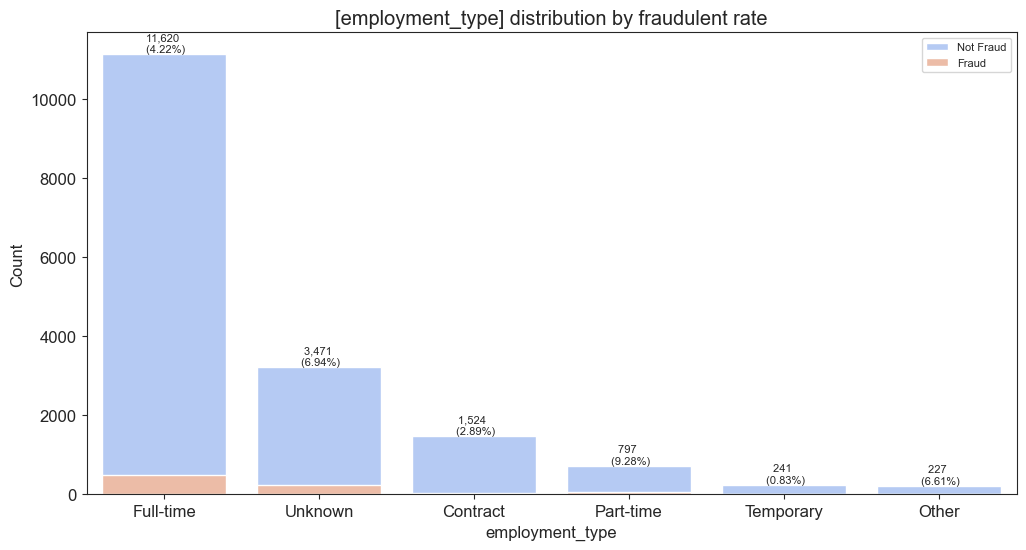

In [30]:
fea = 'employment_type'
# df[fea] = df[fea].str.lower()
# replace the missing values with 'Unknown'
df[fea].fillna('Unknown', inplace=True)
plot_cate_by_label_rate(fea, df, title=None, fontsize=8)

### 3.3.3 industry

- 27% missing.
- Its cardinality is 132 before the proprocessing. 
- Its cardinality is 22 after the proprocessing.
- Compared to the population 4.85% fraudulent rate, the following are significantly higher:
    - Healthcare and Hospital(8.17%)
    - Finance and Insurance(17.82%)
    - Transportation and Tourism(12.83%)
    - Energy(36.82%)

    The following are significantly lower:
    - Computer Software(0.94%)
    - Education(0.20%)
    - Research and Design(2.26%)
    - Media and Networks(2.07%)
    - Food(0.60%)
    - _**Legal(0%)**_


In [31]:
fea = 'industry'
# df[fea] = df[fea].str.lower()
# replace the missing values with 'unknown'
df[fea].fillna('Unknown', inplace=True)
df[fea].value_counts(dropna=False).head(50)

industry
Unknown                                4903
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Retail                                  223
Real Estate                             175
Accounting                              159
Construction                            158
E-Learning                              139
Management Consulting                   130
Design                                  129
Health, Wellness and Fitness            127
Staffing and Recruiting                 127
Insurance                               123
Automotive                              120
Logistics and Supply Ch

In [32]:
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to preprocess text
def preprocess_text(text):
    words = text.split()  # Split into words
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]  # Lemmatize each word
    return ' '.join(lemmatized_words)  # Join words back into a single string

# Extract unique industry types of the 'industry' column
from_list = df['industry'].apply(preprocess_text).unique().tolist()
# from_list = df['industry'].unique().tolist()
# Define the to_list as the desired industry types of cardinality 20
to_list = ['Computer Software', 'Legal', 'Information Technology and Services', 'Finance and Insurance', 'Food'
           , 'Healthcare and Hospital', 'Education', 'Government Department and Public Utilities', 'Manufacturing', 'Retail and Consumer Goods'
           , 'Transportation and Tourism', 'Marketing and Advertising', 'Construction and Real Estates', 'Agriculture', 'Research and Design'
           , 'Media and Broadcast Network', 'Entertainment and Sport', 'Consulting', 'Energy', 'Logistics and Supply Chain'
           , 'Art and Fashion', 'Unknown']

# Create a PolyFuzz model using WordEmbeddings via flair 
bert = WordEmbeddings('en-crawl')
bert_matcher = Embeddings(bert, min_similarity=0, top_n=1, cosine_method='sklearn')

# Match the unique industry types to themselves to find similar classes
model = PolyFuzz(bert_matcher).match(from_list, to_list)
# Get the matches from the PolyFuzz model
matches = model.get_matches()
# Create a mapping from the PolyFuzz results
merged_classes = {row['From']: row['To'] for _, row in matches.iterrows()}


In [33]:
# Make sure the value of  key-value pair {'unknown': None} to {'unknown': 'unknown'}
merged_classes['Unknown'] = 'Unknown'
# Apply the mapping to the DataFrame
df['industry_mg'] = df['industry'].map(merged_classes)
# Replace the missing values with 'other'
df['industry_mg'].fillna('other', inplace=True)
# remove the 'industry' column
df.drop(columns=['industry'], inplace=True)
# rename the 'industry_mg' column to 'industry'
df.rename(columns={'industry_mg': 'industry'}, inplace=True)

In [34]:
df[fea].value_counts(dropna=False)

industry
Unknown                                       4903
Information Technology and Services           3313
Computer Software                             2652
Education                                      982
Marketing and Advertising                      844
Retail and Consumer Goods                      801
Healthcare and Hospital                        649
Research and Design                            442
Finance and Insurance                          376
Construction and Real Estates                  366
Manufacturing                                  336
Logistics and Supply Chain                     324
Transportation and Tourism                     304
Energy                                         296
Entertainment and Sport                        282
Media and Broadcast Network                    242
Food                                           168
Government Department and Public Utilities     162
Consulting                                     130
Legal                 

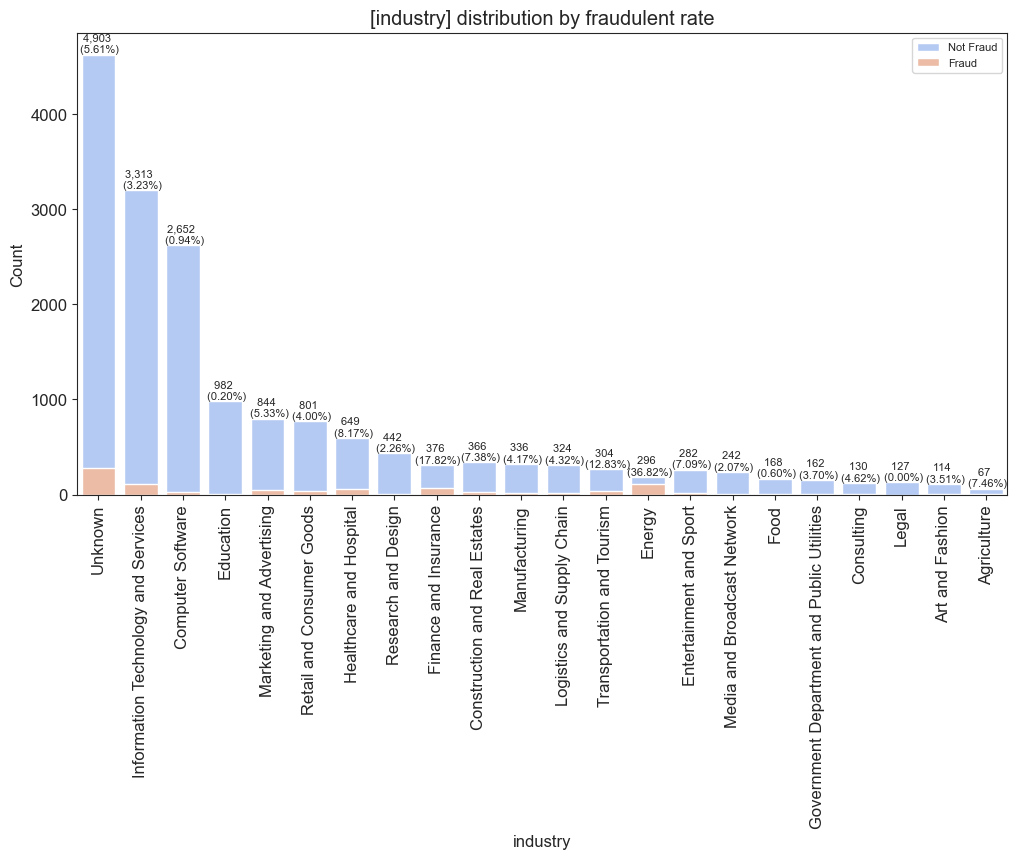

In [35]:
plot_cate_by_label_rate(fea, df, title=None, fontsize=8, rotate=90)

### 3.3.4 Function

- 36% missing.
- Its cardinality is 38 before the proprocessing. 
- Its cardinality is 25 after the proprocessing.
- Compared to the population 4.85% fraudulent rate, the following are significantly higher:
    - Engineering(8.38%)
    - Administrative(15.33%)
    - Accounting/Auditing(13.68%)
    - Finance(9.76%)
    - Other(9.85%)

    The following are significantly lower:
    - Information Technology(1.83%)
    - Sales(2.79%)
    - Marketing and Advertising(1.63%)
    - Management(2.61%)
    - Art and Design(0.85%)
    - Education(0.28%)
    - Healthcare Provider(0.30%)
    - Manufacturing(1.05%)
    - Consulting and Strategy(2.63%)
    - General Business(1.20%)
    - Public Relations(1.32%)
    - _**Writing/Editing(0%)**_
    - _**Quality Assurance(0%)**_
    - _**Research(0%)**_
    - _**Legal(0%)**_


In [36]:
fea = 'function'
# replace the missing values with 'unknown'
df[fea].fillna('Unknown', inplace=True)
df[fea].value_counts(dropna=False)

function
Unknown                   6455
Information Technology    1749
Sales                     1468
Engineering               1348
Customer Service          1229
Marketing                  830
Administrative             630
Design                     340
Health Care Provider       338
Other                      325
Education                  325
Management                 317
Business Development       228
Accounting/Auditing        212
Human Resources            205
Project Management         183
Finance                    172
Consulting                 144
Writing/Editing            132
Art/Creative               132
Production                 116
Product Management         114
Quality Assurance          111
Advertising                 90
Business Analyst            84
Data Analyst                82
Public Relations            76
Manufacturing               74
General Business            68
Research                    50
Legal                       47
Strategy/Planning           46

In [37]:
# set the rows whose 'function' column equals 'Science' to 'Research'
df.loc[df['function'] == 'Science', 'function'] = 'Research'
# set the rows whose 'function' column equals 'Design' or 'Art/Creative' to 'Art and Design'
df.loc[df['function'] == 'Design', 'function'] = 'Art and Design'
df.loc[df['function'] == 'Art/Creative', 'function'] = 'Art and Design'
# set the rows whose 'function' column equals 'Training' to 'Education'
df.loc[df['function'] == 'Training', 'function'] = 'Education'
# set the rows whose 'function' column equals 'Financial Analyst' to 'Finance'
df.loc[df['function'] == 'Financial Analyst', 'function'] = 'Finance'
# set the rows whose 'function' column equals 'Consulting' to 'Consulting and Strategy'
df.loc[df['function'] == 'Consulting', 'function'] = 'Consulting and Strategy'
df.loc[df['function'] == 'Strategy/Planning', 'function'] = 'Consulting and Strategy'
# set the rows whose 'function' column equals 'Project Management' to 'Management'
df.loc[df['function'] == 'Project Management', 'function'] = 'Management'
df.loc[df['function'] == 'Product Management', 'function'] = 'Management'
# set the rows whose 'function' column equals 'Distribution' to 'Supply Chain'
df.loc[df['function'] == 'Distribution', 'function'] = 'Supply Chain'
# set the rows whose 'function' column equals 'Purchasing' to 'General Business'
df.loc[df['function'] == 'Purchasing', 'function'] = 'General Business'
# set the rows whose 'function' column equals 'Human Resources' to 'Administrative'
df.loc[df['function'] == 'Human Resources', 'function'] = 'Administrative'
# set the rows whose 'function' column equals 'Production' to 'Manufacturing'
df.loc[df['function'] == 'Production', 'function'] = 'Manufacturing'
# set the rows whose 'function' column equals 'Marketing' to 'Marketing and Advertising'
df.loc[df['function'] == 'Marketing', 'function'] = 'Marketing and Advertising'
df.loc[df['function'] == 'Advertising', 'function'] = 'Marketing and Advertising'
# set the rows whose 'function' column equals 'Business Analyst' to 'Business/Data Analyst'
df.loc[df['function'] == 'Business Analyst', 'function'] = 'Business/Data Analyst'
# set the rows whose 'function' column equals 'Data Analyst' to 'Business/Data Analyst'
df.loc[df['function'] == 'Data Analyst', 'function'] = 'Business/Data Analyst'

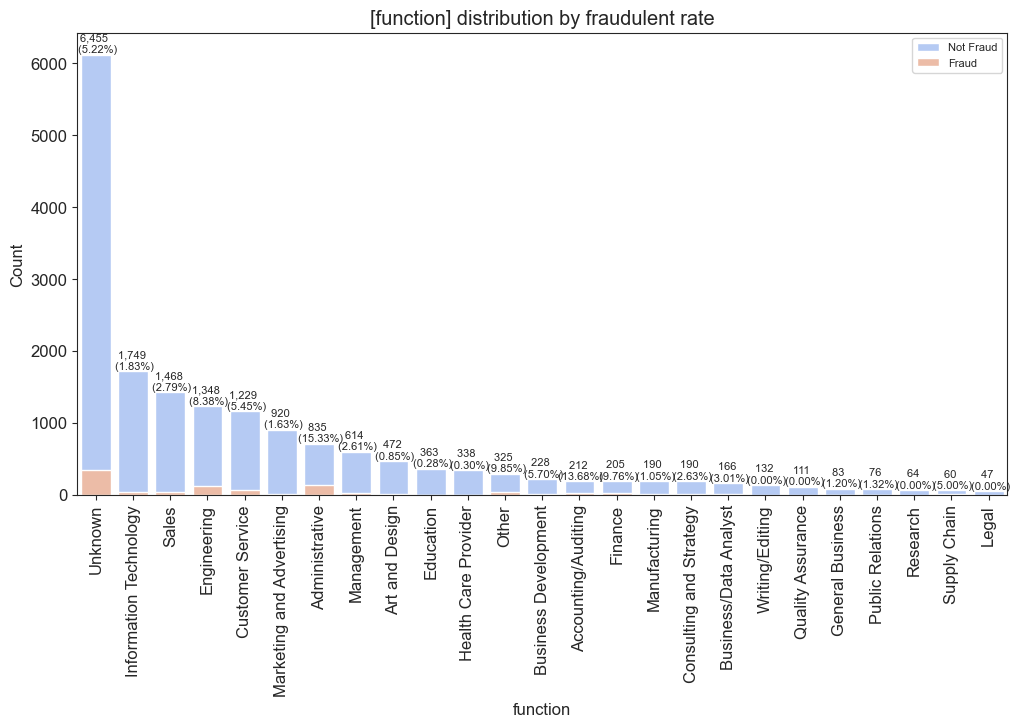

In [38]:
plot_cate_by_label_rate(fea, df, title=None, fontsize=8, rotate=90)

### 3.3.5 Required experience

- 39% missing.
- Its cardinality is 8. 
- Compared to the population 4.85% fraudulent rate, the following are significantly higher:
    - Executive(7.09%)

    The following are significantly lower:
    - Associate Level(1.83%)
    - Internship(2.79%)


In [39]:
fea = 'required_experience'
# replace the missing values with 'unknown'
df[fea].fillna('Unknown', inplace=True)
df[fea].value_counts(dropna=False)

required_experience
Unknown             7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

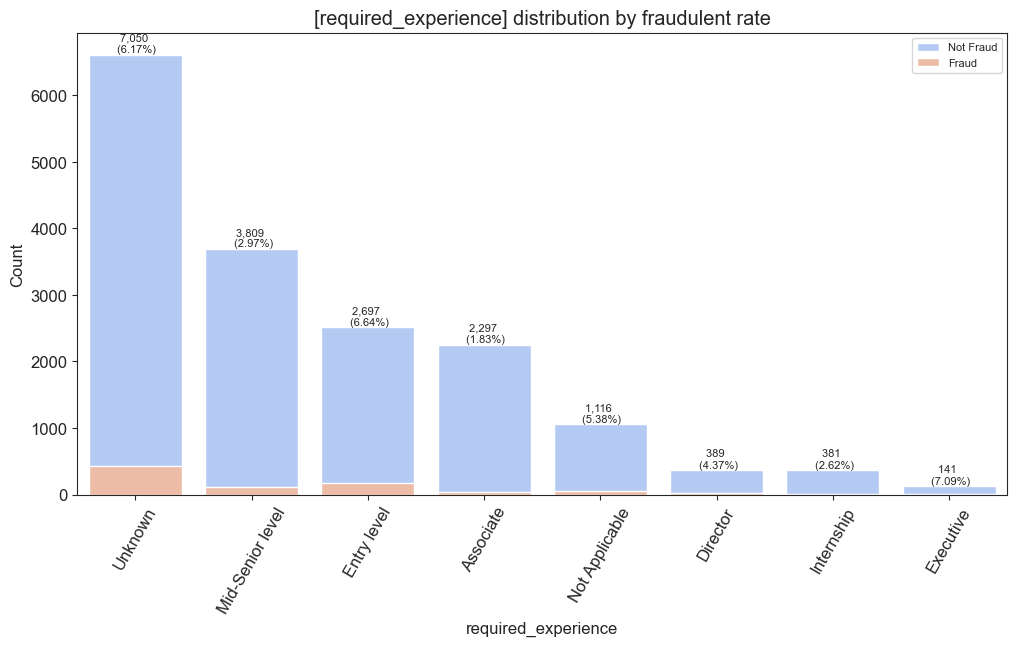

In [40]:
plot_cate_by_label_rate(fea, df, title=None, fontsize=8, rotate=60)

### 3.3.6 Required education

- 45% missing.
- Its cardinality is 14 before the preprossecing.
- Its cardinality is 12 after the proprocessing.
- Compared to the population 4.85% fraudulent rate, the following are significantly higher:
    - Some High School Coursework(74.07%)
    - High School or Equivalent(8.17%)
    - Certification(11.18%)

    The following are significantly lower:
    - Bachelor's Degree(1.94%)
    - Associate Degree(2.19%)
    - _**Vocational(0%)**_

In [41]:
fea = 'required_education'
# replace the missing values with 'unknown'
df[fea].fillna('Unknown', inplace=True)
df[fea].value_counts(dropna=False)

required_education
Unknown                              8105
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

In [42]:
# set the rows whose 'required_education' column equals 'Vocational - HS Diploma' to 'Vocational'
df.loc[df['required_education'] == 'Vocational - HS Diploma', 'required_education'] = 'Vocational'
# set the rows whose 'required_education' column equals 'Vocational - Degree' to 'Vocational'
df.loc[df['required_education'] == 'Vocational - Degree', 'required_education'] = 'Vocational'

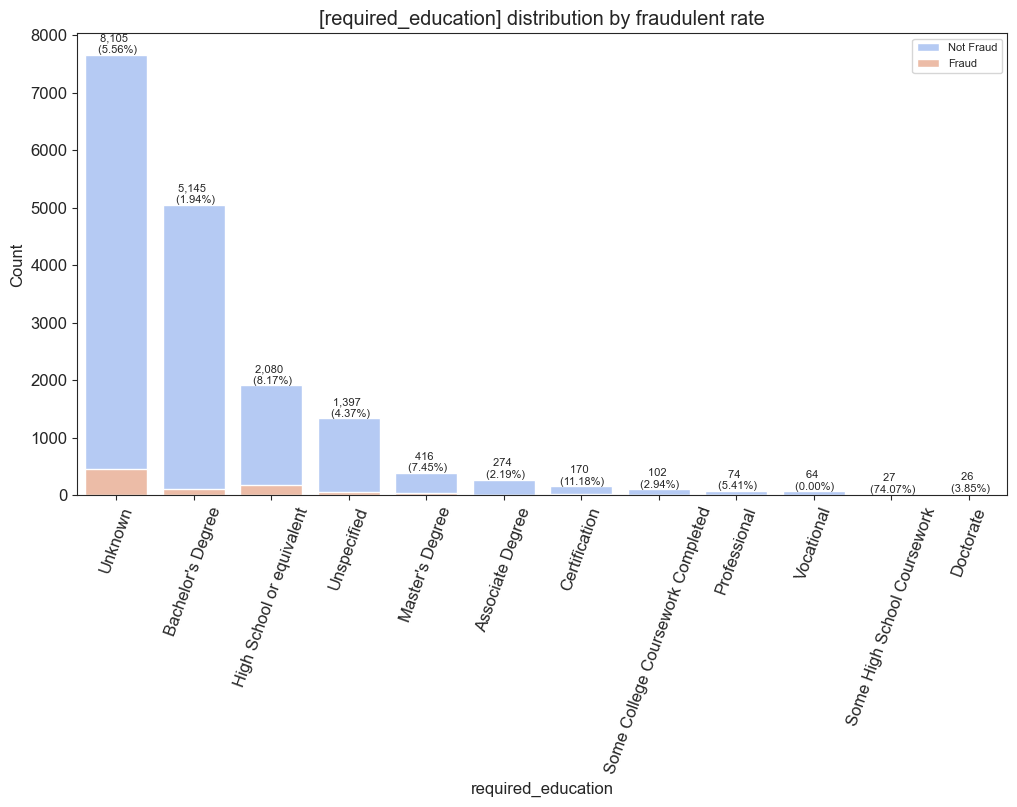

In [43]:
plot_cate_by_label_rate(fea, df, title=None, fontsize=8, rotate=70)

### 3.3.7 Department

- 65% Missing.
- Its cardinality is 1337 before the preprossecing.
- Its cardinality is 22 after the proprocessing.
- Compared to the population 4.85% fraudulent rate, the following are significantly higher:
    - Other(10.15%)
    - Administrative(19.86%)
    - Accounting(11.45%)
    - Human Resources(32.99%)
    - Maintenance(9.72%)
    - Clerical(91.18%)

    The following are significantly lower:
    - Information Technology(1.83%)
    - Sales(2.77%)
    - Marketing(1.03%)
    - Management(2.61%)
    - Research and Design(1.59%)
    - Operations(1.26%)
    - Development(0.78%)
    - Logistics(1.79%)
    - Consulting and Strategy(2.63%)
    - General Business(1.20%)
    - Public Relations(1.32%)
    - _**Production(0%)**_
    - _**Quality Assurance(0%)**_
    - _**Legal(0%)**_

In [44]:
fea = 'department'
# replace the missing values with 'unknown'
df[fea].fillna('Unknown', inplace=True)
df[fea].value_counts(dropna=False).head(50)

department
Unknown                   11548
Sales                       551
Engineering                 487
Marketing                   401
Operations                  270
IT                          225
Development                 146
Product                     112
Information Technology       86
Technology                   76
Design                       76
Customer Service             73
Finance                      69
HR                           56
tech                         55
R&D                          54
Creative                     48
Retail                       45
Client Services              45
Product Development          36
Production                   32
Business Development         32
Oil and Gas                  32
CSD Relay                    31
Administrative               30
Maintenance                  30
Tech                         29
Human Resources              29
Accounting                   29
Technical                    29
Administration               

In [45]:
# Extract unique industry types of the fea column
from_list = df[fea].apply(preprocess_text).unique().tolist()
from_list = ['Unknown' if x == '' else x for x in from_list]
# from_list = df['industry'].unique().tolist()
# Define the to_list as the desired industry types of cardinality 20
to_list = ['Sales', 'Engineering', 'Marketing', 'Operations', 'Information Technology'
           , 'Customer Service', 'Development', 'Production', 'Training', 'Administrative'
           , 'Finance', 'Maintenance', 'Healthcare', 'Human Resources', 'Accounting'
           , 'Management', 'Logistics', 'Research and Design', 'Clerical', 'Quality Assurance'
           , 'Legal', 'Unknown']

# Create a PolyFuzz model using BERT embeddings via flair 
bert = WordEmbeddings('en-crawl')
bert_matcher = Embeddings(bert, min_similarity=0, top_n=1, cosine_method='sklearn')

# Match the unique industry types to themselves to find similar classes
model = PolyFuzz(bert_matcher).match(from_list, to_list)
# Get the matches from the PolyFuzz model
matches = model.get_matches()
# Create a mapping from the PolyFuzz results
merged_classes = {row['From']: row['To'] for _, row in matches.iterrows()}


In [46]:
# Apply the mapping to the DataFrame
df[fea+'_mg'] = df[fea].map(merged_classes)
# Replace the missing values with 'other'
df[fea+'_mg'].fillna('other', inplace=True)

df.drop(columns=[fea], inplace=True)

df.rename(columns={fea+'_mg': fea}, inplace=True)

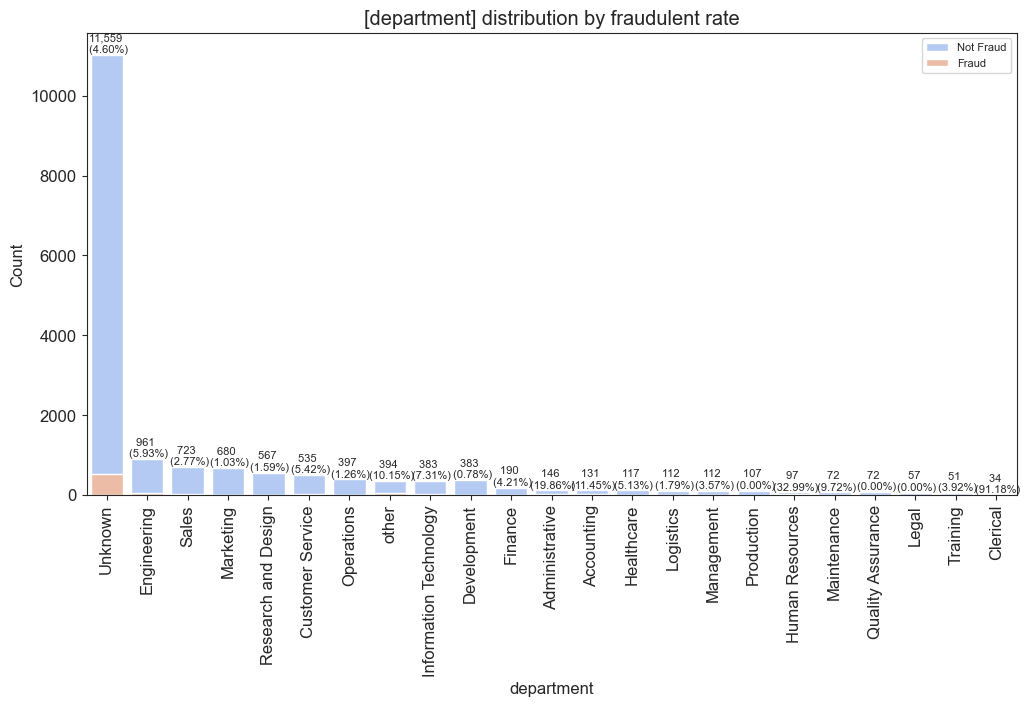

In [47]:
plot_cate_by_label_rate(fea, df, title=None, fontsize=8, rotate=90)

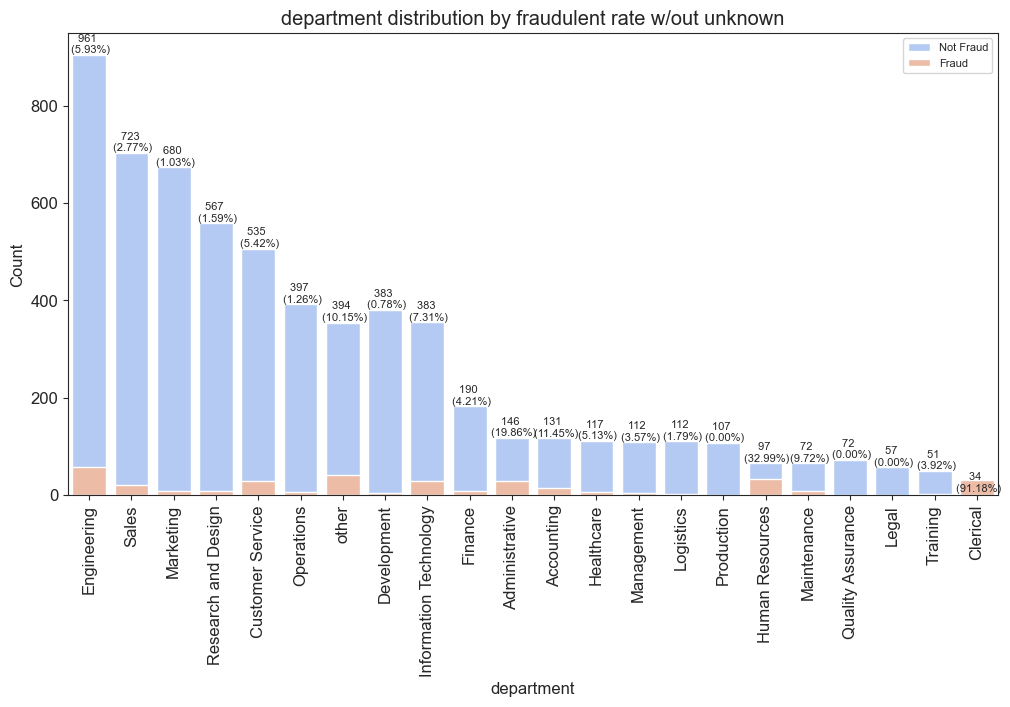

In [48]:
# save the df[fea] to a pd.series without the 'Unknown' value
department_no = df.loc[df[fea] != 'Unknown', [fea, 'fraudulent']]
plot_cate_by_label_rate(fea, department_no, title=fea+' distribution by fraudulent rate w/out unknown', 
                        fontsize=8, rotate=90)

### 3.3.8 Salary_range

- 84% Missing.
- Its cardinality is 875 before the preprossecing.
- Its cardinality is 22 after the proprocessing.
- Compared to the population 4.85% fraudulent rate, the following are significantly higher:
    - 100-1K (10.05%)
    - 1K-10K (16.94%)
    - 10K-15K (16.05%)
    - 35K-40K (7.87%)
    - 70K-75K (19.15%)
    - 75K-80K (22.73%)
    - 100K-125K (17.81%)
    - 125K-150K (7.35%)
    
    The following are significantly lower:
    - 20K-25K (0.65%)
    - 30K-35K (2.76%)
    - 45K-50K (1.61%)
    - 65K-70K (1.00%)
    - 90K-100K (2.74%)
    - 150K-300K (0%)

In [49]:
fea = 'salary_range'
# replace the missing values with 'unknown'
df[fea].fillna('Unknown', inplace=True)
df[fea].value_counts(dropna=False)

salary_range
Unknown          15012
0-0                142
40000-50000         66
30000-40000         55
45000-67000         37
                 ...  
15-25                1
60-75                1
300000-325000        1
20-22                1
3700-3800            1
Name: count, Length: 875, dtype: int64

In [50]:
# Define a function to group salary ranges
def group_salary_range(salary):
    if salary == 'Unknown':
        return 'Unknown'
    elif '-' not in salary or not all(part.strip().isdigit() for part in salary.split('-')):
        return 'Invalid'
    else:
        lower, upper = map(int, salary.split('-'))
        mid = (lower + upper) / 2
        if mid < 100:
            return '<100'
        elif mid <= 1000:
            return '100-1K'
        elif mid <= 10000:
            return '1K-10K'
        elif mid <= 15000:
            return '10K-15K'
        elif mid <= 20000:
            return '15K-20K'
        elif mid <= 25000:
            return '20K-25K'
        elif mid <= 30000:
            return '25K-30K'
        elif mid <= 35000:
            return '30K-35K'
        elif mid <= 40000:
            return '35K-40K'
        elif mid <= 45000:
            return '40K-45K'
        elif mid <= 50000:
            return '45K-50K'
        elif mid <= 55000:
            return '50K-55K'
        elif mid <= 60000:
            return '55K-60K'
        elif mid <= 65000:
            return '60K-65K'
        elif mid <= 70000:
            return '65K-70K'
        elif mid <= 75000:
            return '70K-75K'
        elif mid <= 80000:
            return '75K-80K'
        elif mid <= 90000:
            return '80K-90K'
        elif mid <= 100000:
            return '90K-100K'
        elif mid <= 125000:
            return '100K-125K'
        elif mid <= 150000:
            return '125K-150K'
        elif mid <= 300000:
            return '150K-300K'
        else:
            return '>300K'
    return salary

# Apply the grouping function
df['salary_range_grouped'] = df['salary_range'].apply(group_salary_range)

In [51]:
df['salary_range_grouped'].value_counts(dropna=False)

salary_range_grouped
Unknown      15012
<100           294
30K-35K        189
25K-30K        183
40K-45K        161
35K-40K        161
15K-20K        155
100K-125K      148
20K-25K        145
55K-60K        127
50K-55K        127
45K-50K        124
60K-65K        123
90K-100K       113
65K-70K        108
80K-90K        100
>300K           94
1K-10K          88
75K-80K         75
10K-15K         73
70K-75K         73
125K-150K       68
150K-300K       60
100-1K          52
Invalid         27
Name: count, dtype: int64

In [52]:
# fix the invalid salary range values
df.loc[df['salary_range'] == '40000', 'salary_range_grouped'] = '35K-40K'
df.loc[df['salary_range_grouped'] == 'Invalid', 'salary_range_grouped'] = '<100'
# remove the 'salary_range' column
df.drop(columns=['salary_range'], inplace=True)
# rename the 'salary_range_grouped' column to 'salary_range'
df.rename(columns={'salary_range_grouped': 'salary_range'}, inplace=True)

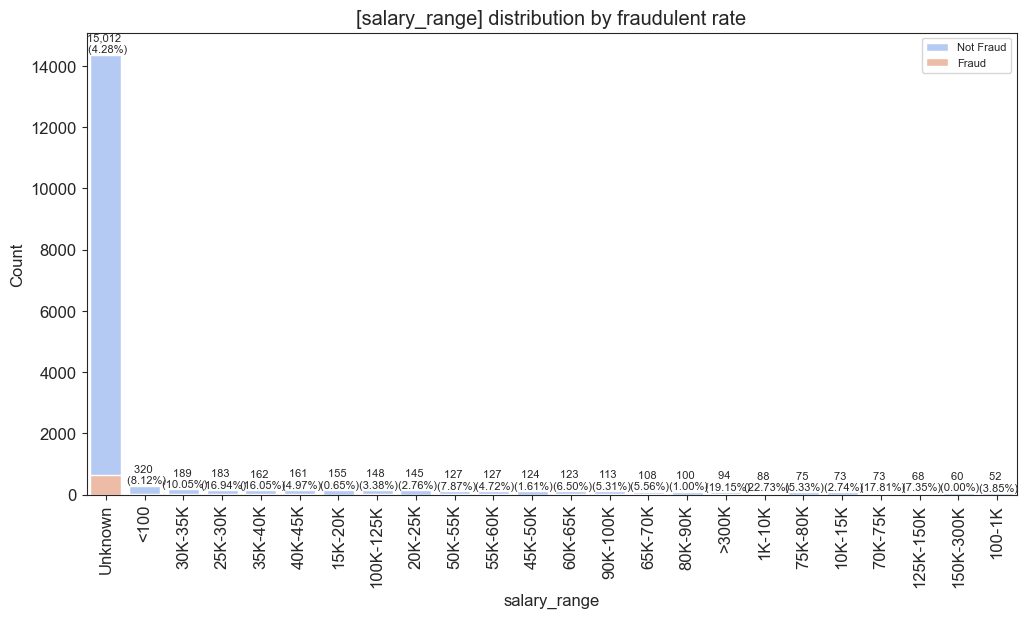

In [53]:
plot_cate_by_label_rate(fea, df, title=None, fontsize=8, rotate=90)

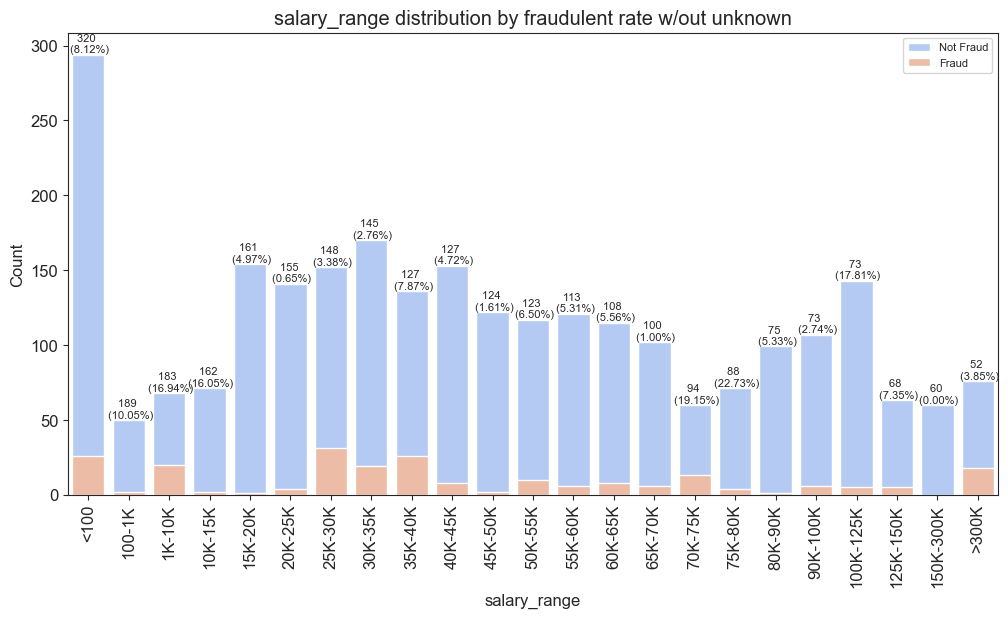

In [54]:
# save the df[fea] to a pd.series without the 'Unknown' value
salary_rg = df.loc[df[fea] != 'Unknown', [fea, 'fraudulent']]
order_list = ['<100', '100-1K', '1K-10K', '10K-15K', '15K-20K', '20K-25K', '25K-30K', '30K-35K', '35K-40K', '40K-45K'
              , '45K-50K', '50K-55K', '55K-60K', '60K-65K', '65K-70K', '70K-75K', '75K-80K', '80K-90K', '90K-100K'
              , '100K-125K', '125K-150K', '150K-300K', '>300K']
plot_cate_by_label_rate(fea, salary_rg, 
                        title=fea+' distribution by fraudulent rate w/out unknown', 
                        fontsize=8, rotate=90, order_use=order_list)

## 3.4 Text features

### 3.4.1 Feature Engineering
- Combine the 6 text columns 'title', 'company_profile', 'description', 'requirements', 'benefits', 'location' into [text].
- Create columns to count the occurrence of URLs, Emails and Phone Numbers in [text] row-wise [N_URLs], [N_phones] , [N_emails] as numeric features.
- Create another numeric feature to record the length of the text as [len_text]

In [55]:
# Replace the NAN values with empty strings
df['title'].fillna('', inplace=True)
df['company_profile'].fillna('', inplace=True)
df['description'].fillna('', inplace=True)
df['requirements'].fillna('', inplace=True)
df['benefits'].fillna('', inplace=True)

# combine all the text columns into a single column so that we can extract numerical features from the text
df['text'] = df['title'] + ' ' + df['company_profile'] + ' ' + df['description'] + ' ' + df['requirements'] + ' ' + df['benefits'] + df['location'] + df['department'] + df['function'] + df['employment_type'] + df['required_experience'] + df['required_education'] + df['industry'] + df['salary_range']
df['N_URLs'] = df['text'].str.count('#URL_')
df['N_phones'] = df['text'].str.count('#PHONE_')
df['N_emails'] = df['text'].str.count('#EMAIL_')
df['len_text'] = df['text'].str.len()
# remove the 'text' column
df.drop(columns=['text'], inplace=True)

In [56]:
print("Distribution of URL's in Dataset")
print(df['N_URLs'].value_counts())
print("Distribution of Phone Numbers in Dataset")
print(df['N_phones'].value_counts())
print("Distribution of Emails in Dataset")
print(df['N_emails'].value_counts())

Distribution of URL's in Dataset
N_URLs
0     12259
1      2488
2      2239
3       369
4       279
5       102
6        61
7        26
8        23
16        8
9         8
11        6
10        5
15        4
14        3
Name: count, dtype: int64
Distribution of Phone Numbers in Dataset
N_phones
0    17353
1      359
2       98
3       68
4        2
Name: count, dtype: int64
Distribution of Emails in Dataset
N_emails
0    16545
1     1223
2       99
3       12
4        1
Name: count, dtype: int64


In [57]:
# save the df to a csv file
df.to_csv('fake_job_postings_cleaned.csv', index=False)

### 3.4.2 Text Cleaning via Spacy

In [62]:
# load the cleaned data
df = pd.read_csv('fake_job_postings_cleaned.csv', keep_default_na=False)

In [63]:
df.head()

,title,location,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,function,fraudulent,country,industry,department,salary_range,N_URLs,N_phones,N_emails,len_text
0,Marketing Intern,"us, new york, new york city","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Other,Internship,Unknown,Marketing and Advertising,0,us,Unknown,Marketing,Unknown,0,0,0,2759
1,Customer Service - Cloud Video Production,"nz, auckland, auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Unknown,Customer Service,0,nz,Marketing and Advertising,Training,Unknown,6,0,0,6241
2,Commissioning Machinery Assistant (CMA),"us, iowa, mount pleasant",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,Unknown,Unknown,Unknown,Unknown,0,us,Unknown,Unknown,Unknown,0,0,0,2713
3,Account Executive - Washington DC,"us, columbia district, washington.d.c.",Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Sales,0,us,Computer Software,Sales,Unknown,0,0,0,5576
4,Bill Review Manager,"us, florida, miami",SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Health Care Provider,0,us,Healthcare and Hospital,Unknown,Unknown,0,1,0,4066


In [64]:
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits', 'location']

In [65]:
## TIME WARNING: This cell may take >20 mins to run
# Load the SpaCy model
nlp = spacy.load('en_core_web_lg')

# Function to clean text with POS tagging
def clean_text_with_pos(text):
    # Lowercasing
    text = text.lower()
    
    # Remove text within brackets
    text = re.sub(r'\[.*?\]', '', text)
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>+', '', text)
    
    # Remove punctuation
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    
    # Remove newline characters
    text = re.sub(r'\n', '', text)


    # Process text with SpaCy
    doc = nlp(text)
    
    # Tokenization, lowercasing, remove special characters and punctuation, remove stop words
    tokens = [token for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    
    # Lemmatization with POS tagging
    cleaned_text = ' '.join(token.lemma_ for token in tokens)
    
    return cleaned_text

# Apply the function to the DataFrame's text cols
for col in text_cols:
    df[col] = df[col].apply(clean_text_with_pos)

In [66]:
print(df[text_cols])

                                                   title  \
0                                       marketing intern   
1                customer service cloud video production   
2                     commission machinery assistant cma   
3                        account executive washington dc   
4                                    bill review manager   
...                                                  ...   
17875                      account director distribution   
17876                                 payroll accountant   
17877  project cost control staff engineer cost contr...   
17878                                   graphic designer   
17879                          web application developer   

                                         company_profile  \
0      ve create groundbreaking awardwinning cooking ...   
1      second world cloud video production second wor...   
2      valor service provide workforce solution meet ...   
3      passion improve quality life geo

In [68]:
# save the df to a csv file
df.to_csv('df_text_clean.csv', index=False)

# 4. Models


In [119]:
# load the cleaned data
df = pd.read_csv('df_text_clean.csv')

In [120]:
# Separate the target from df
target = df['fraudulent']
df.drop(columns=['fraudulent'], inplace=True)

# Convert the categorical columns to category data type for the downstream Catboost model
cat_cols =['telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 
           'required_education', 'industry', 'function', 'department', 'salary_range', 'country']

for c in cat_cols:
    df[c] = df[c].astype('category')  

# Specify the numerical columns   
num_cols = ['N_URLs', 'N_phones', 'N_emails', 'len_text']

In [ ]:
# Stratify split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42, stratify=target)

## 4.1 Without any Text

In [ ]:
# Define the ColumnTransformer
cf_41 = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', 'passthrough', cat_cols),
    ('txt', 'drop', text_cols)
], remainder='drop', n_jobs=-1)

# Define the CatBoost classifier
clf = CatBoostClassifier(cat_features=['cat__'+col for col in cat_cols], eval_metric='AUC', learning_rate=0.03, class_weights=[1, 5],
                         iterations=1000, task_type='GPU', devices='0:1', boosting_type='Ordered',
                         early_stopping_rounds=50, leaf_estimation_method='Newton', leaf_estimation_iterations=5,
                         verbose=50, random_state=42, has_time=False)

# Create the Pipeline
pipe_41 = Pipeline([
    ('preprocessor', cf_41),
    ('classifier', clf)
])

# Split the training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# update the cat_cols by adding 'cat__' to the beginning of each column name
cat_cols = ['cat__'+col for col in cat_cols]

# Preprocess the training and validation sets
X_train_41 = pipe_41.named_steps['preprocessor'].fit_transform(X_train_split)
cols_41 = pipe_41.named_steps['preprocessor'].get_feature_names_out()
X_train_41 = pd.DataFrame(X_train_41, columns=cols_41)
X_val_41 = pipe_41.named_steps['preprocessor'].transform(X_val_split)
X_val_41 = pd.DataFrame(X_val_41, columns=cols_41)

# Create CatBoost Pools
train_pool = Pool(data=X_train_41, label=y_train_split, cat_features=cat_cols)
val_pool = Pool(data=X_val_41, label=y_val_split, cat_features=cat_cols)

# Fit the CatBoost classifier with the validation set
pipe_41.named_steps['classifier'].fit(train_pool, eval_set=val_pool, use_best_model=True, plot=True, early_stopping_rounds=50)

# get the best evaluation metric score
cat_best_metric_val = pipe_41.named_steps['classifier'].get_best_score()
# get the best iteration
cat_best_iter_val = pipe_41.named_steps['classifier'].get_best_iteration()

# Preprocess the test set
X_test_41 = pipe_41.named_steps['preprocessor'].transform(X_test)
X_test_41 = pd.DataFrame(X_test_41, columns=cols_41)

# Create CatBoost Pool
test_pool = Pool(data=X_test_41, label=y_test, cat_features=cat_cols)
# make the predictions on the testing set via Pipeline
y_pred_cat = pipe_41.predict_proba(X_test)[:,1]

# get the AUC score and accuracy on the testing set
cat_auc_score = roc_auc_score(y_test, y_pred_cat)
cat_accuracy = accuracy_score(y_test, pipe_41.predict(X_test))
# add the shapley values to the test set
shap_cat = pipe_41.named_steps['classifier'].get_feature_importance(data=test_pool, type='ShapValues')
df_shap_cat = pd.DataFrame(shap_cat[:,:-1], columns=cols_41)
fea_imp_cat = df_shap_cat.abs().mean().sort_values(ascending=False)

# Print the best evaluation metric and iteration
print(f"Best evaluation metric on the validation set: {cat_best_metric_val}")
print(f"Best iteration on the validation set: {cat_best_iter_val}")
print(f"AUC score on the testing set: {cat_auc_score:.4f}")
print(f"Accuracy on the testing set: {cat_accuracy:.4f}")

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8341544	best: 0.8341544 (0)	total: 57ms	remaining: 56.9s
50:	test: 0.9413571	best: 0.9414602 (49)	total: 3.14s	remaining: 58.4s
100:	test: 0.9542867	best: 0.9544188 (99)	total: 6.13s	remaining: 54.6s
150:	test: 0.9588736	best: 0.9588736 (150)	total: 9.09s	remaining: 51.1s
200:	test: 0.9614756	best: 0.9615021 (196)	total: 12s	remaining: 47.7s
250:	test: 0.9631143	best: 0.9631328 (248)	total: 14.8s	remaining: 44.3s
300:	test: 0.9642428	best: 0.9642455 (297)	total: 17.7s	remaining: 41.2s
350:	test: 0.9647714	best: 0.9647714 (350)	total: 20.8s	remaining: 38.5s
400:	test: 0.9651600	best: 0.9652974 (399)	total: 23.8s	remaining: 35.5s
450:	test: 0.9654084	best: 0.9655644 (449)	total: 27s	remaining: 32.8s
bestTest = 0.9655643702
bestIteration = 449
Shrink model to first 450 iterations.
Best evaluation metric on the validation set: {'learn': {'Logloss': 0.1727402791314335}, 'validation': {'Logloss': 0.18084021957080407, 'AUC': 0.9655643701553345}}
Best iteration on the validation set

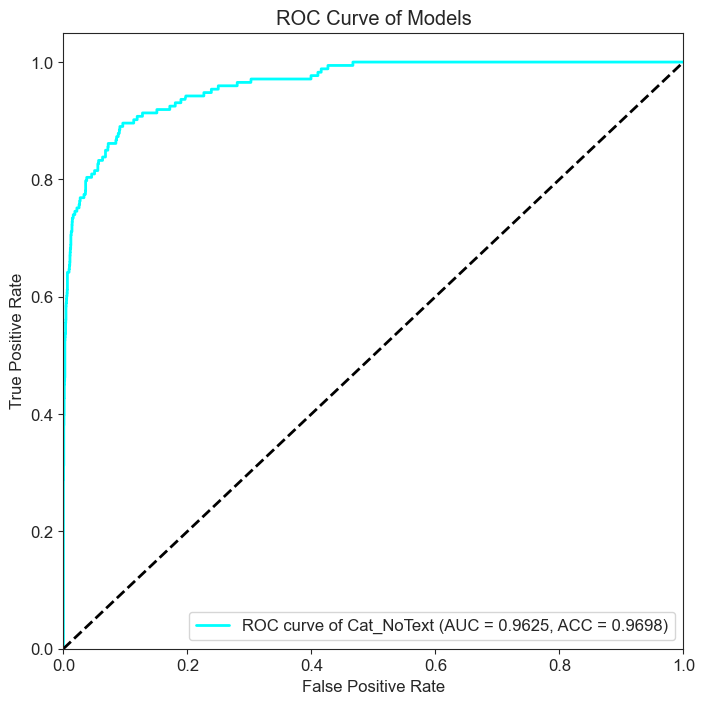

Results saved.


In [ ]:
# get the roc curve and threshold
fpr_cat_41, tpr_cat_41, threshold_cat_41 = roc_curve(y_test, y_pred_cat)
plt.figure(figsize=(8, 8))
plt.plot(fpr_cat_41, tpr_cat_41, color='cyan', lw=2, label=f'ROC curve of Cat_NoText (AUC = {cat_auc_score:.4f}, ACC = {cat_accuracy:.4f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of Models')
plt.legend(loc="lower right")
plt.show()

res = {
    'pipeline': pipe_41,
    'AUC score on the testing set': cat_auc_score,
    'Accuracy on the testing set': cat_accuracy,
    'fpr': fpr_cat_41,
    'tpr': tpr_cat_41,
    'threshold': threshold_cat_41
}

# save the res via joblib
joblib.dump(res, 'models/Cat_NoText.joblib')
print('Results saved.')

In [124]:
pipe_41

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num', StandardScaler(),
                                                  ['N_URLs', 'N_phones',
                                                   'N_emails', 'len_text']),
                                                 ('cat', 'passthrough',
                                                  ['telecommuting',
                                                   'has_company_logo',
                                                   'has_questions',
                                                   'employment_type',
                                                   'required_experience',
                                                   'required_education',
                                                   'industry', 'function',
                                                   'department', 'salary_range',
                                                   'country']),
                                                 ('txt', 'drop',
                                                  ['title', 'company_profile',
                                                   'description',
                                                   'requirements', 'benefits',
                                                   'location'])])),
                ('classifier',
                 <catboost.core.CatBoostClassifier object at 0x00000192BECD1BB0>)])

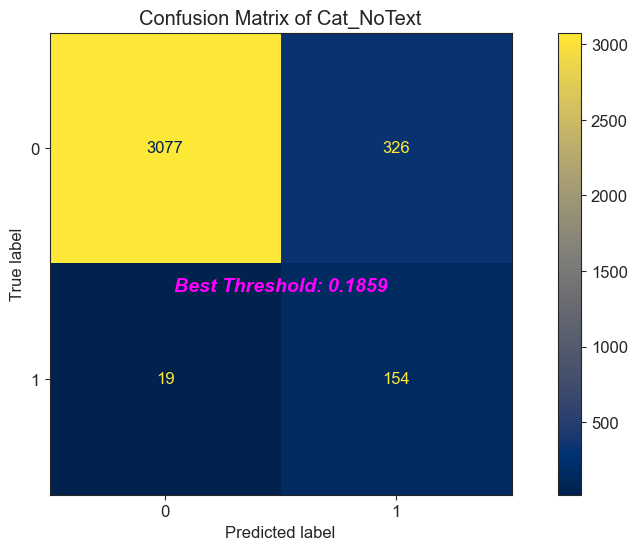

In [125]:
Cat_NoText = joblib.load('models/Cat_NoText.joblib')
fpr_cat_no = Cat_NoText['fpr']
tpr_cat_no = Cat_NoText['tpr']
cat_auc_no = Cat_NoText['AUC score on the testing set']
cat_accuracy_no = Cat_NoText['Accuracy on the testing set']
thresholds_cat_no = Cat_NoText['thredshold']
# plot the confusion matrix with the best threshold
best_threshold = thresholds_cat_no[np.argmax(tpr_cat_no - fpr_cat_no)]
y_pred_cat_best = (y_pred_cat > best_threshold).astype(int)
conf_mat_cat = confusion_matrix(y_test, y_pred_cat_best)
# change the color_map to 'Blues' in ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=conf_mat_cat, display_labels=pipe_41.named_steps['classifier'].classes_).plot(cmap='cividis')
plt.title('Confusion Matrix of Cat_NoText')
# add the best threshold to the top center of the plot in red and size 14 and bold and underlined
plt.text(0.5, 0.45, f'Best Threshold: {best_threshold:.4f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color='magenta', size=14, weight='bold', style='italic')
plt.show()

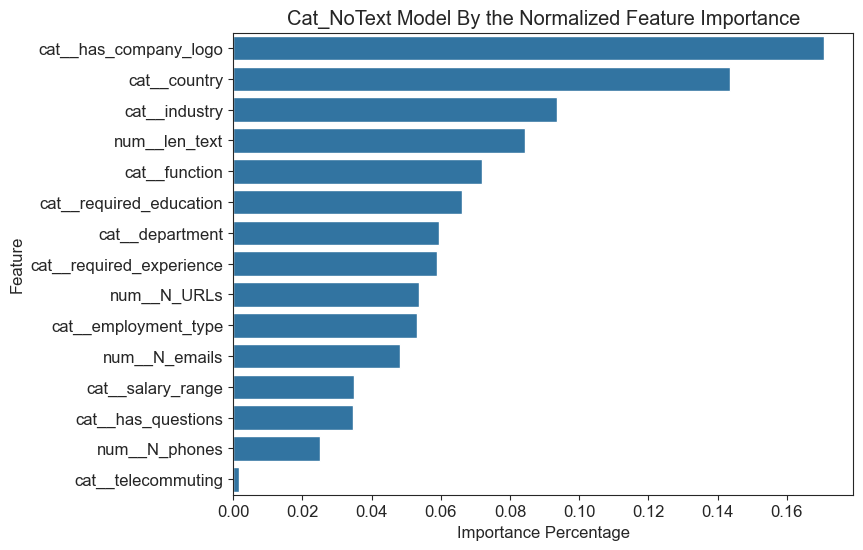

In [126]:
# get the feature importance of the model
fea_imp_cat = pipe_41.named_steps['classifier'].feature_importances_
# get the feature names
fea_names_cat = pipe_41.named_steps['classifier'].feature_names_
# create a DataFrame of feature importance
fea_imp_cat = pd.DataFrame({'feature': fea_names_cat, 'importance': fea_imp_cat})
# sort the DataFrame by importance
fea_imp_cat.sort_values('importance', ascending=False, inplace=True)
# normalize the importance
fea_imp_cat['importance'] = fea_imp_cat['importance'] / fea_imp_cat['importance'].sum()

# plot the feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=fea_imp_cat, legend=False)
plt.title('Cat_NoText Model By the Normalized Feature Importance')
plt.xlabel('Importance Percentage')
plt.ylabel('Feature')
plt.show()

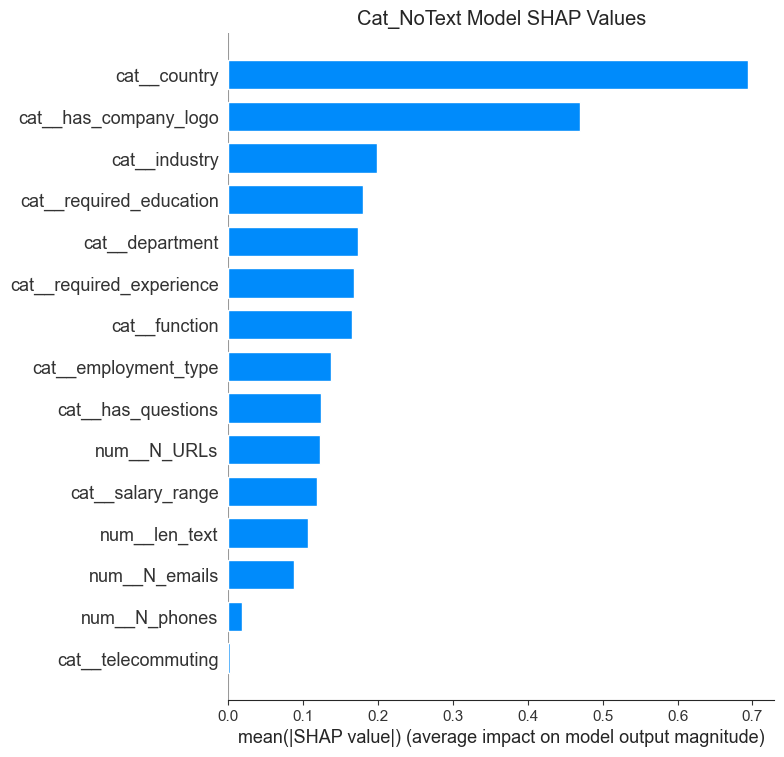

In [127]:
# Get the SHapley values of the model
shap_values_cat = pipe_41.named_steps['classifier'].get_feature_importance(test_pool, type='ShapValues')
# plot the SHapley values
shap.summary_plot(shap_values_cat[:,:-1], X_test_41, plot_type='bar', max_display=20, show=False)
plt.title('Cat_NoText Model SHAP Values')
plt.show()


## 4.2 Use CountVectorizer to do Bag of words approach 


In [158]:
import gc
gc.collect()

9438

In [152]:
cat_cols =['telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 
           'required_education', 'industry', 'function', 'department', 'salary_range', 'country']

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits', 'location']

# Create a JSON configuration for text processing using bag-of-words vectorizer
text_processing = {
    "tokenizers": [{
        "tokenizer_id": "Space",
        "delimiter": " "
    }],
    "dictionaries": [{
        "dictionary_id": "Unigram",
        "token_level_type": "Word",
        "occurrence_lower_bound": 1,
        "max_dictionary_size": "20000"
    }],
    "feature_processing": {
        "default": [{
            "dictionaries_names": ["Unigram"],
            "feature_calcers": ["BoW"],
            "tokenizers_names": ["Space"]
        }]
    }
}
# Convert the JSON configuration to a string
text_processing_json = json.dumps(text_processing)

# Define the ColumnTransformer
cf_42 = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', 'passthrough', cat_cols),
    ('txt', SimpleImputer(strategy='constant', fill_value=''), text_cols)
], remainder='drop', n_jobs=-1)

# Define the CatBoost classifier
clf = CatBoostClassifier(
    cat_features=['cat__'+col for col in cat_cols],
    text_features=['txt__'+col for col in text_cols],
    text_processing=text_processing_json,
    eval_metric='AUC',
    learning_rate=0.03,
    class_weights=[1, 5],
    iterations=1200,
    task_type='GPU',
    devices='0:1',
    boosting_type='Ordered',
    early_stopping_rounds=50,
    leaf_estimation_method='Newton',
    leaf_estimation_iterations=5,
    verbose=50,
    random_state=42,
    has_time=False
)

# Create the Pipeline
pipe_42 = Pipeline([
    ('preprocessor', cf_42),
    ('classifier', clf)
])

# Split the training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# update the cat_cols by adding 'cat__' to the beginning of each column name
cat_cols = ['cat__'+col for col in cat_cols]
# update the text_cols by adding 'txt__' to the beginning of each column name
text_cols = ['txt__'+col for col in text_cols]

# Preprocess the training and validation sets
X_train_42 = pipe_42.named_steps['preprocessor'].fit_transform(X_train_split)
cols_42 = pipe_42.named_steps['preprocessor'].get_feature_names_out()
X_train_42 = pd.DataFrame(X_train_42, columns=cols_42)
X_val_42 = pipe_42.named_steps['preprocessor'].transform(X_val_split)
X_val_42 = pd.DataFrame(X_val_42, columns=cols_42)
# Create Pool objects for training, validation
train_pool = Pool(data=X_train_42, label=y_train_split, cat_features=cat_cols, text_features=text_cols)
val_pool = Pool(data=X_val_42, label=y_val_split, cat_features=cat_cols, text_features=text_cols)

# Fit the CatBoost classifier with the validation set
pipe_42.named_steps['classifier'].fit(train_pool, eval_set=val_pool, use_best_model=True, plot=True, early_stopping_rounds=50)

# get the best eval_metric on the validation set
cat_best_metric_val = pipe_42.named_steps['classifier'].get_best_score()

# get the best iteration on the validation set
cat_best_iter_val = pipe_42.named_steps['classifier'].get_best_iteration()

# Preprocess the test set
X_test_42 = pipe_42.named_steps['preprocessor'].transform(X_test)
X_test_42 = pd.DataFrame(X_test_42, columns=cols_42)

# Create CatBoost Pool
test_pool = Pool(data=X_test_42, label=y_test, cat_features=cat_cols, text_features=text_cols)
# make the predictions on the testing set via Pipeline
y_pred_cat = pipe_42.predict_proba(X_test)[:,1]

# get the AUC score and accuracy on the testing set
cat_auc_score = roc_auc_score(y_test, y_pred_cat)
cat_accuracy = accuracy_score(y_test, pipe_42.predict(X_test))
# add the shapley values to the test set
shap_cat = pipe_42.named_steps['classifier'].get_feature_importance(data=test_pool, type='ShapValues')
df_shap_cat = pd.DataFrame(shap_cat[:,:-1], columns=cols_42)
fea_imp_cat = df_shap_cat.abs().mean().sort_values(ascending=False)

# Print the best evaluation metric and iteration
print(f"Best evaluation metric on the validation set: {cat_best_metric_val}")
print(f"Best iteration on the validation set: {cat_best_iter_val}")
print(f"AUC score on the testing set: {cat_auc_score:.4f}")
print(f"Accuracy on the testing set: {cat_accuracy:.4f}")

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9733824	best: 0.9733824 (0)	total: 75.8ms	remaining: 1m 30s
50:	test: 0.9880933	best: 0.9881356 (48)	total: 4.52s	remaining: 1m 41s
100:	test: 0.9906702	best: 0.9906702 (100)	total: 8.04s	remaining: 1m 27s
150:	test: 0.9917486	best: 0.9917565 (144)	total: 11.5s	remaining: 1m 19s
200:	test: 0.9922851	best: 0.9922930 (198)	total: 14.8s	remaining: 1m 13s
250:	test: 0.9925811	best: 0.9926102 (248)	total: 18.1s	remaining: 1m 8s
300:	test: 0.9927979	best: 0.9928031 (296)	total: 21.4s	remaining: 1m 4s
350:	test: 0.9930859	best: 0.9930859 (348)	total: 24.8s	remaining: 59.9s
400:	test: 0.9934269	best: 0.9934691 (391)	total: 28.1s	remaining: 55.9s
450:	test: 0.9936224	best: 0.9936224 (450)	total: 31.5s	remaining: 52.3s
500:	test: 0.9937466	best: 0.9937466 (499)	total: 34.8s	remaining: 48.6s
550:	test: 0.9939132	best: 0.9939132 (550)	total: 38.3s	remaining: 45.1s
600:	test: 0.9940585	best: 0.9940585 (599)	total: 41.7s	remaining: 41.6s
650:	test: 0.9940982	best: 0.9941008 (641)	total: 4

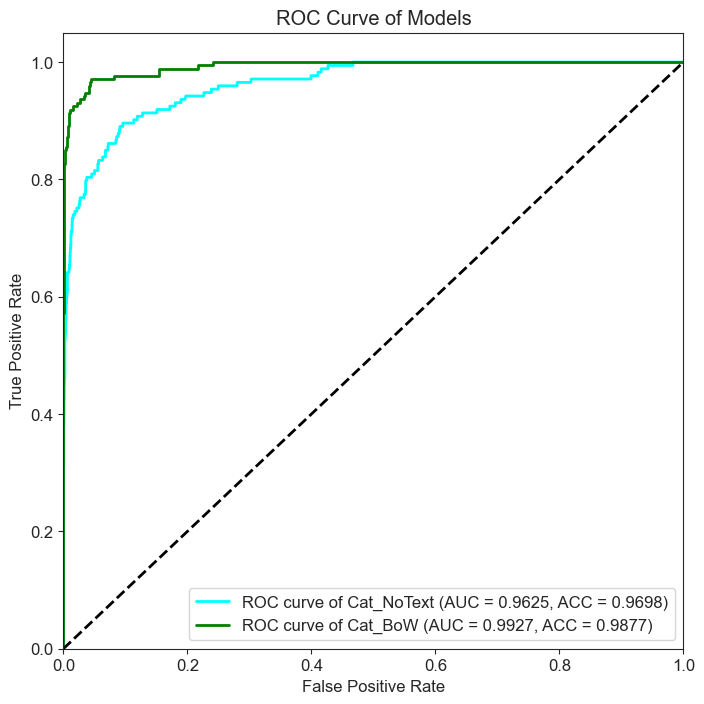

Results saved.


In [166]:
# get the roc curve and threshold
fpr_cat_42, tpr_cat_42, threshold_cat_42 = roc_curve(y_test, y_pred_cat)
plt.figure(figsize=(8, 8))
plt.plot(fpr_cat_41, tpr_cat_41, color='cyan', lw=2, label=f'ROC curve of Cat_NoText (AUC = {cat_auc_no:.4f}, ACC = {cat_accuracy_no:.4f})')
plt.plot(fpr_cat_42, tpr_cat_42, color='green', lw=2, label=f'ROC curve of Cat_BoW (AUC = {cat_auc_score:.4f}, ACC = {cat_accuracy:.4f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of Models')
plt.legend(loc="lower right")
plt.show()

res = {
    'pipeline': pipe_42,
    'AUC score on the testing set': cat_auc_score,
    'Accuracy on the testing set': cat_accuracy,
    'fpr': fpr_cat_42,
    'tpr': tpr_cat_42,
    'threshold': threshold_cat_42
}

# save the res via joblib
joblib.dump(res, 'models/Cat_BoW.joblib')
print('Results saved.')

In [155]:
pipe_42

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num', StandardScaler(),
                                                  ['N_URLs', 'N_phones',
                                                   'N_emails', 'len_text']),
                                                 ('cat', 'passthrough',
                                                  ['telecommuting',
                                                   'has_company_logo',
                                                   'has_questions',
                                                   'employment_type',
                                                   'required_experience',
                                                   'required_education',
                                                   'industry', 'function',
                                                   'department', 'salary_range',
                                                   'country']),
                                                 ('txt',
                                                  SimpleImputer(fill_value='',
                                                                strategy='constant'),
                                                  ['title', 'company_profile',
                                                   'description',
                                                   'requirements', 'benefits',
                                                   'location'])])),
                ('classifier',
                 <catboost.core.CatBoostClassifier object at 0x00000192CB5293D0>)])

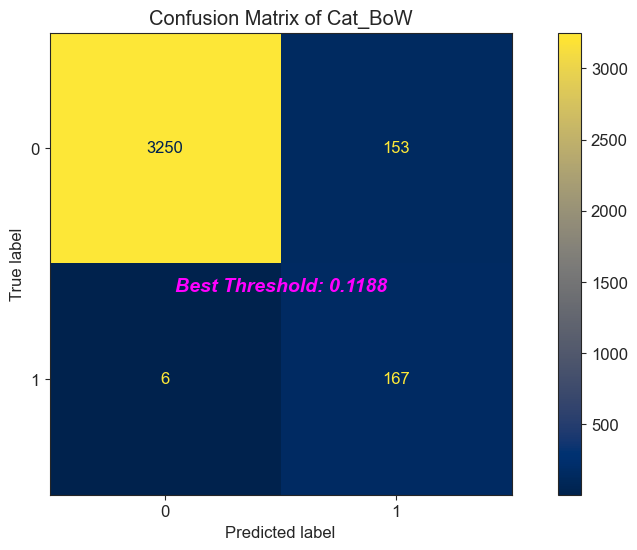

In [154]:
Cat_Bow = joblib.load('models/Cat_BoW.joblib')
fpr_cat_count = Cat_Bow['fpr']
tpr_cat_count = Cat_Bow['tpr']
cat_auc_count = Cat_Bow['AUC score on the testing set']
cat_accuracy_count = Cat_Bow['Accuracy on the testing set']
thresholds_cat_count = Cat_Bow['threshold']
# plot the confusion matrix with the best threshold
best_threshold = thresholds_cat_count[np.argmax(tpr_cat_count - fpr_cat_count)]
y_pred_cat_best = (y_pred_cat > best_threshold).astype(int)
conf_mat_cat = confusion_matrix(y_test, y_pred_cat_best)
# change the color_map to 'Blues' in ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=conf_mat_cat, display_labels=pipe_42.named_steps['classifier'].classes_).plot(cmap='cividis')
plt.title('Confusion Matrix of Cat_BoW')
# add the best threshold to the top center of the plot in red and size 14 and bold and underlined
plt.text(0.5, 0.45, f'Best Threshold: {best_threshold:.4f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color='magenta', size=14, weight='bold', style='italic')
plt.show()

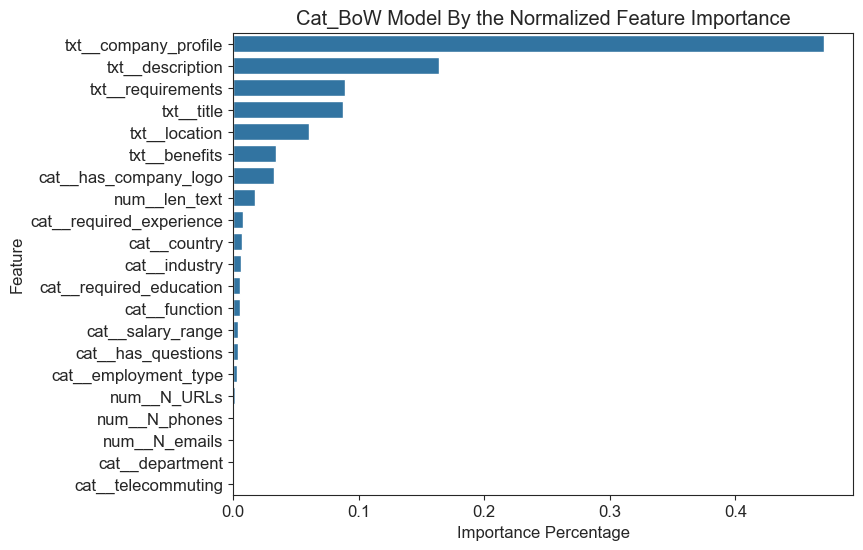

In [156]:
# get the feature importance of the model
fea_imp_cat = pipe_42.named_steps['classifier'].feature_importances_
# get the feature names
fea_names_cat = pipe_42.named_steps['classifier'].feature_names_
# create a DataFrame of feature importance
fea_imp_cat = pd.DataFrame({'feature': fea_names_cat, 'importance': fea_imp_cat})
# sort the DataFrame by importance
fea_imp_cat.sort_values('importance', ascending=False, inplace=True)
# normalize the importance
fea_imp_cat['importance'] = fea_imp_cat['importance'] / fea_imp_cat['importance'].sum()

# plot the feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=fea_imp_cat, legend=False)
plt.title('Cat_BoW Model By the Normalized Feature Importance')
plt.xlabel('Importance Percentage')
plt.ylabel('Feature')
plt.show()

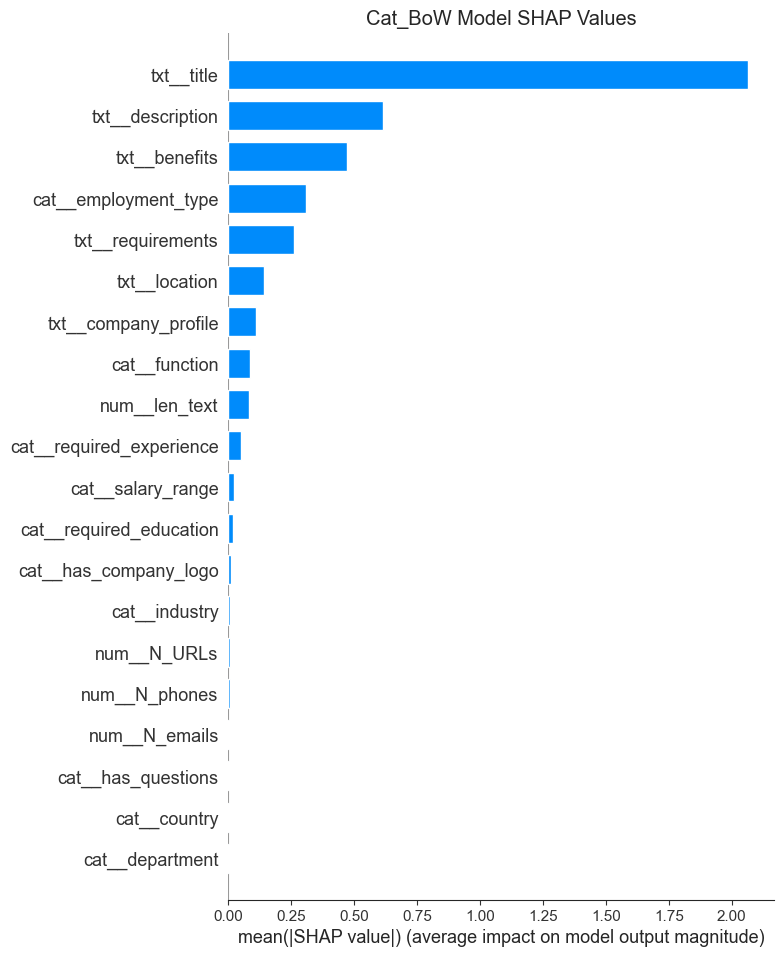

In [157]:
# Get the SHapley values of the model
shap_values_cat = pipe_42.named_steps['classifier'].get_feature_importance(test_pool, type='ShapValues')
# plot the SHapley values
shap.summary_plot(shap_values_cat[:,:-1], X_test_42, plot_type='bar', max_display=20, show=False)
plt.title('Cat_BoW Model SHAP Values')
plt.show()

## 4.3 Use TFIDF Vectorizer 


In [174]:
cat_cols =['telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 
           'required_education', 'industry', 'function', 'department', 'salary_range', 'country']

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits', 'location']

# Create a JSON configuration for text processing using TF-IDF vectorizer
text_processing = {
    "tokenizers": [{
        "tokenizer_id": "Space",
        "delimiter": " "
    }],
    "dictionaries": [
        {
            "dictionary_id": "Unigram",
            "token_level_type": "Word",
            "occurrence_lower_bound": 1,
            "max_dictionary_size": "20000"
        },
        {
            "dictionary_id": "Bigram",
            "token_level_type": "Word",
            "occurrence_lower_bound": 1,
            "max_dictionary_size": "10000"
        }
    ],
    "feature_processing": {
        "default": [{
            "dictionaries_names": ["Unigram", "Bigram"],
            "feature_calcers": ["TFIDF"],
            "tokenizers_names": ["Space"]
        }]
    }
}
# Convert the JSON configuration to a string
text_processing_json = json.dumps(text_processing)

# Define the ColumnTransformer
cf_43 = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', 'passthrough', cat_cols),
    ('txt', SimpleImputer(strategy='constant', fill_value=''), text_cols)
], remainder='drop', n_jobs=-1)

# Define the CatBoost classifier
clf = CatBoostClassifier(
    cat_features=['cat__'+col for col in cat_cols],
    text_features=['txt__'+col for col in text_cols],
    text_processing=text_processing_json,
    eval_metric='AUC',
    learning_rate=0.03,
    class_weights=[1, 5],
    iterations=1200,
    task_type='GPU',
    devices='0:1',
    boosting_type='Ordered',
    early_stopping_rounds=50,
    leaf_estimation_method='Newton',
    leaf_estimation_iterations=5,
    verbose=50,
    random_state=27,
    has_time=False
)

# Create the Pipeline
pipe_43 = Pipeline([
    ('preprocessor', cf_43),
    ('classifier', clf)
])

# Split the training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# update the cat_cols by adding 'cat__' to the beginning of each column name
cat_cols = ['cat__'+col for col in cat_cols]
# update the text_cols by adding 'txt__' to the beginning of each column name
text_cols = ['txt__'+col for col in text_cols]

# Preprocess the training and validation sets
X_train_43 = pipe_43.named_steps['preprocessor'].fit_transform(X_train_split)
cols_43 = pipe_43.named_steps['preprocessor'].get_feature_names_out()
X_train_43 = pd.DataFrame(X_train_43, columns=cols_43)
X_val_43 = pipe_43.named_steps['preprocessor'].transform(X_val_split)
X_val_43 = pd.DataFrame(X_val_43, columns=cols_43)
# Create Pool objects for training, validation
train_pool = Pool(data=X_train_43, label=y_train_split, cat_features=cat_cols, text_features=text_cols)
val_pool = Pool(data=X_val_43, label=y_val_split, cat_features=cat_cols, text_features=text_cols)

# Fit the CatBoost classifier with the validation set
pipe_43.named_steps['classifier'].fit(train_pool, eval_set=val_pool, use_best_model=True, plot=True, early_stopping_rounds=50)

# get the best eval_metric on the validation set
cat_best_metric_val = pipe_43.named_steps['classifier'].get_best_score()

# get the best iteration on the validation set
cat_best_iter_val = pipe_43.named_steps['classifier'].get_best_iteration()

# Preprocess the test set
X_test_43 = pipe_43.named_steps['preprocessor'].transform(X_test)
X_test_43 = pd.DataFrame(X_test_43, columns=cols_43)

# Create CatBoost Pool
test_pool = Pool(data=X_test_43, label=y_test, cat_features=cat_cols, text_features=text_cols)
# make the predictions on the testing set via Pipeline
y_pred_cat = pipe_43.predict_proba(X_test)[:,1]

# get the AUC score and accuracy on the testing set
cat_auc_score = roc_auc_score(y_test, y_pred_cat)
cat_accuracy = accuracy_score(y_test, pipe_43.predict(X_test))
# add the shapley values to the test set
shap_cat = pipe_43.named_steps['classifier'].get_feature_importance(data=test_pool, type='ShapValues')
df_shap_cat = pd.DataFrame(shap_cat[:,:-1], columns=cols_43)
fea_imp_cat = df_shap_cat.abs().mean().sort_values(ascending=False)

# Print the best evaluation metric and iteration
print(f"Best evaluation metric on the validation set: {cat_best_metric_val}")
print(f"Best iteration on the validation set: {cat_best_iter_val}")
print(f"AUC score on the testing set: {cat_auc_score:.4f}")
print(f"Accuracy on the testing set: {cat_accuracy:.4f}")

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9689936	best: 0.9689936 (0)	total: 77.1ms	remaining: 1m 32s
50:	test: 0.9904402	best: 0.9904402 (50)	total: 4.04s	remaining: 1m 31s
100:	test: 0.9916428	best: 0.9916428 (100)	total: 7.78s	remaining: 1m 24s
150:	test: 0.9922534	best: 0.9922534 (150)	total: 11.4s	remaining: 1m 18s
200:	test: 0.9925943	best: 0.9925943 (199)	total: 14.8s	remaining: 1m 13s
250:	test: 0.9928163	best: 0.9928163 (249)	total: 18.2s	remaining: 1m 8s
300:	test: 0.9932260	best: 0.9932260 (298)	total: 21.6s	remaining: 1m 4s
350:	test: 0.9934084	best: 0.9934084 (350)	total: 24.9s	remaining: 1m
400:	test: 0.9934559	best: 0.9934691 (391)	total: 28.2s	remaining: 56.2s
450:	test: 0.9935907	best: 0.9935907 (450)	total: 31.5s	remaining: 52.4s
500:	test: 0.9937943	best: 0.9938074 (498)	total: 35s	remaining: 48.8s
550:	test: 0.9939423	best: 0.9939423 (550)	total: 38.5s	remaining: 45.3s
600:	test: 0.9940982	best: 0.9940982 (599)	total: 41.9s	remaining: 41.8s
650:	test: 0.9942541	best: 0.9942541 (650)	total: 45.4s	

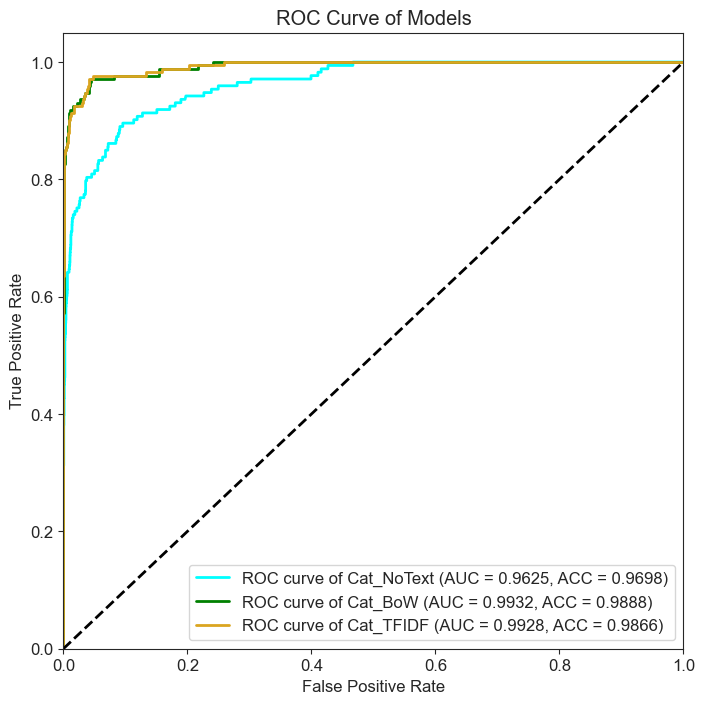

Results saved.


In [181]:
# get the roc curve and threshold
fpr_cat_43, tpr_cat_43, threshold_cat_43 = roc_curve(y_test, y_pred_cat)
plt.figure(figsize=(8, 8))
plt.plot(fpr_cat_41, tpr_cat_41, color='cyan', lw=2, label=f'ROC curve of Cat_NoText (AUC = {cat_auc_no:.4f}, ACC = {cat_accuracy_no:.4f})')
plt.plot(fpr_cat_42, tpr_cat_42, color='green', lw=2, label=f'ROC curve of Cat_BoW (AUC = {cat_auc_count:.4f}, ACC = {cat_accuracy_count:.4f})')
plt.plot(fpr_cat_43, tpr_cat_43, color='goldenrod', lw=2, label=f'ROC curve of Cat_TFIDF (AUC = {cat_auc_score:.4f}, ACC = {cat_accuracy:.4f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of Models')
plt.legend(loc="lower right")
plt.show()

res = {
    'pipeline': pipe_43,
    'AUC score on the testing set': cat_auc_score,
    'Accuracy on the testing set': cat_accuracy,
    'fpr': fpr_cat_43,
    'tpr': tpr_cat_43,
    'threshold': threshold_cat_43
}

# save the res via joblib
joblib.dump(res, 'models/Cat_TFIDF.joblib')
print('Results saved.')

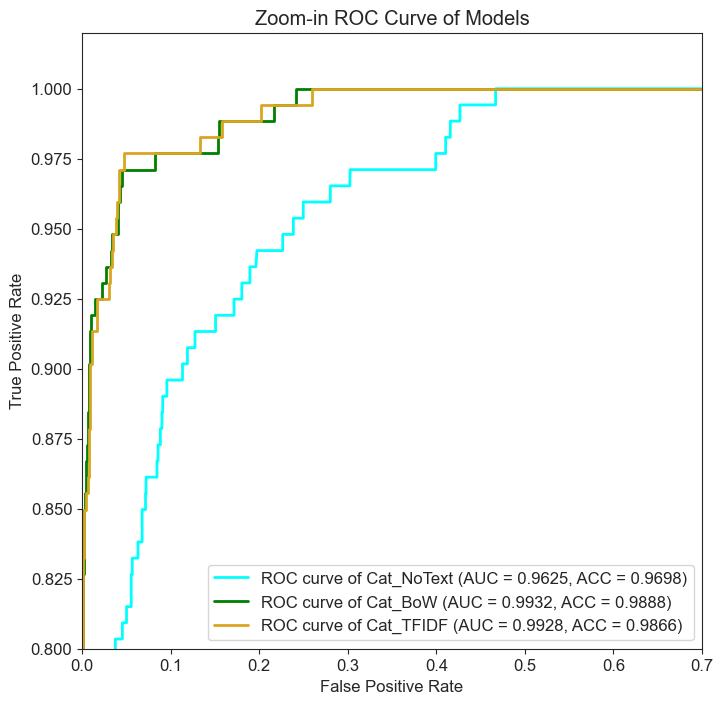

In [182]:
plt.figure(figsize=(8, 8))
plt.plot(fpr_cat_41, tpr_cat_41, color='cyan', lw=2, label=f'ROC curve of Cat_NoText (AUC = {cat_auc_no:.4f}, ACC = {cat_accuracy_no:.4f})')
plt.plot(fpr_cat_42, tpr_cat_42, color='green', lw=2, label=f'ROC curve of Cat_BoW (AUC = {cat_auc_count:.4f}, ACC = {cat_accuracy_count:.4f})')
plt.plot(fpr_cat_43, tpr_cat_43, color='goldenrod', lw=2, label=f'ROC curve of Cat_TFIDF (AUC = {cat_auc_score:.4f}, ACC = {cat_accuracy:.4f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 0.7])
plt.ylim([0.8, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Zoom-in ROC Curve of Models')
plt.legend(loc="lower right")
plt.show()

In [183]:
pipe_43

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num', StandardScaler(),
                                                  ['N_URLs', 'N_phones',
                                                   'N_emails', 'len_text']),
                                                 ('cat', 'passthrough',
                                                  ['telecommuting',
                                                   'has_company_logo',
                                                   'has_questions',
                                                   'employment_type',
                                                   'required_experience',
                                                   'required_education',
                                                   'industry', 'function',
                                                   'department', 'salary_range',
                                                   'country']),
                                                 ('txt',
                                                  SimpleImputer(fill_value='',
                                                                strategy='constant'),
                                                  ['title', 'company_profile',
                                                   'description',
                                                   'requirements', 'benefits',
                                                   'location'])])),
                ('classifier',
                 <catboost.core.CatBoostClassifier object at 0x00000192ABB4AD30>)])

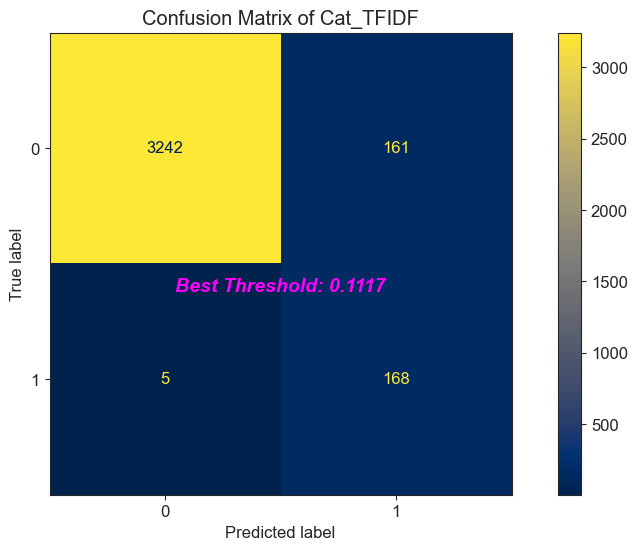

In [184]:
Cat_TFIDF = joblib.load('models/Cat_TFIDF.joblib')
fpr_cat_tfidf = Cat_TFIDF['fpr']
tpr_cat_tfidf = Cat_TFIDF['tpr']
cat_auc_tfidf = Cat_TFIDF['AUC score on the testing set']
cat_accuracy_tfidf = Cat_TFIDF['Accuracy on the testing set']
thresholds_cat_tfidf = Cat_TFIDF['threshold']
# plot the confusion matrix with the best threshold
best_threshold = thresholds_cat_tfidf[np.argmax(tpr_cat_tfidf - fpr_cat_tfidf)]
y_pred_cat_best = (y_pred_cat > best_threshold).astype(int)
conf_mat_cat = confusion_matrix(y_test, y_pred_cat_best)
# change the color_map to 'Blues' in ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=conf_mat_cat, display_labels=pipe_43.named_steps['classifier'].classes_).plot(cmap='cividis')
plt.title('Confusion Matrix of Cat_TFIDF')
# add the best threshold to the top center of the plot in red and size 14 and bold and underlined
plt.text(0.5, 0.45, f'Best Threshold: {best_threshold:.4f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color='magenta', size=14, weight='bold', style='italic')
plt.show()

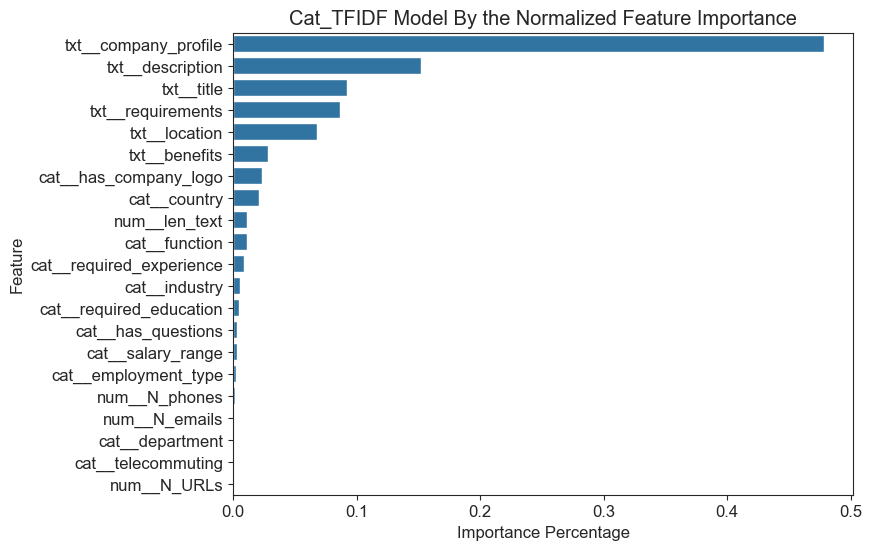

In [185]:
# get the feature importance of the model
fea_imp_cat = pipe_43.named_steps['classifier'].feature_importances_
# get the feature names
fea_names_cat = pipe_43.named_steps['classifier'].feature_names_
# create a DataFrame of feature importance
fea_imp_cat = pd.DataFrame({'feature': fea_names_cat, 'importance': fea_imp_cat})
# sort the DataFrame by importance
fea_imp_cat.sort_values('importance', ascending=False, inplace=True)
# normalize the importance
fea_imp_cat['importance'] = fea_imp_cat['importance'] / fea_imp_cat['importance'].sum()

# plot the feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=fea_imp_cat, legend=False)
plt.title('Cat_TFIDF Model By the Normalized Feature Importance')
plt.xlabel('Importance Percentage')
plt.ylabel('Feature')
plt.show()

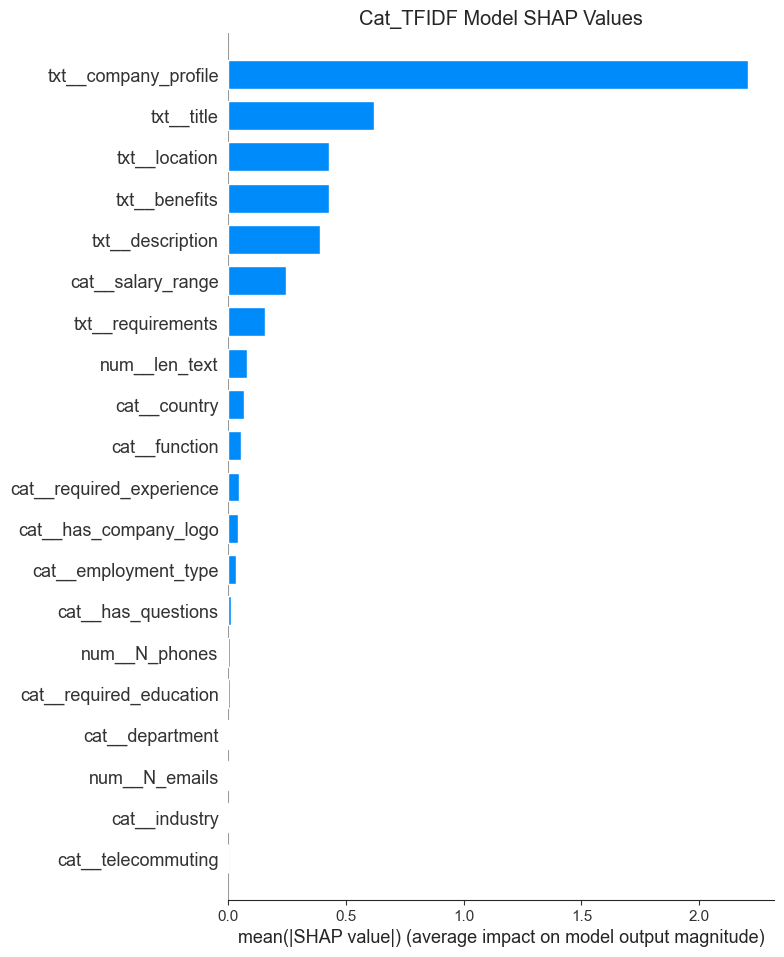

In [186]:
# Get the SHapley values of the model
shap_values_cat = pipe_43.named_steps['classifier'].get_feature_importance(test_pool, type='ShapValues')
# plot the SHapley values
shap.summary_plot(shap_values_cat[:,:-1], X_test_43, plot_type='bar', max_display=20, show=False)
plt.title('Cat_TFIDF Model SHAP Values')
plt.show()

## 4.4 Use GloVe to represent the words in [text] to vectors

GloVe is a powerful method for generating word embeddings that capture semantic relationships between words by leveraging global statistical information from a corpus. These embeddings can be used in various NLP tasks to improve performance and provide meaningful insights into the relationships between words.

In [194]:
cat_cols =['telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 
           'required_education', 'industry', 'function', 'department', 'salary_range', 'country']

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits', 'location']

# Create a JSON configuration for text processing using GloVe embeddings
text_processing = {
    "tokenizers": [{
        "tokenizer_id": "Space",
        "delimiter": " "
    }],
    "dictionaries": [{
        "dictionary_id": "Glove",
        "token_level_type": "Word",
        "occurrence_lower_bound": 1,
        "max_dictionary_size": "1000000",
        "embedding_file": "FakeJobPostingPrediction\glove.42B.300d.txt"
    }],
    "feature_processing": {
        "default": [{
            "dictionaries_names": ["Glove"],
            "feature_calcers": ["Embedding"],
            "tokenizers_names": ["Space"]
        }]
    }
}

# Convert the JSON configuration to a string
text_processing_json = json.dumps(text_processing)

# Define the ColumnTransformer
cf_44 = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', 'passthrough', cat_cols),
    ('txt', SimpleImputer(strategy='constant', fill_value=''), text_cols)
], remainder='drop', n_jobs=-1)

# Define the CatBoost classifier
clf = CatBoostClassifier(
    cat_features=['cat__'+col for col in cat_cols],
    text_features=['txt__'+col for col in text_cols],
    text_processing=text_processing_json,
    eval_metric='AUC',
    learning_rate=0.03,
    class_weights=[1, 5],
    iterations=1200,
    task_type='GPU',
    devices='0:1',
    boosting_type='Ordered',
    early_stopping_rounds=50,
    leaf_estimation_method='Newton',
    leaf_estimation_iterations=5,
    verbose=50,
    random_state=44,
    has_time=False
)

# Create the Pipeline
pipe_44 = Pipeline([
    ('preprocessor', cf_44),
    ('classifier', clf)
])

# Split the training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# update the cat_cols by adding 'cat__' to the beginning of each column name
cat_cols = ['cat__'+col for col in cat_cols]
# update the text_cols by adding 'txt__' to the beginning of each column name
text_cols = ['txt__'+col for col in text_cols]

# Preprocess the training and validation sets
X_train_44 = pipe_44.named_steps['preprocessor'].fit_transform(X_train_split)
cols_44 = pipe_44.named_steps['preprocessor'].get_feature_names_out()
X_train_44 = pd.DataFrame(X_train_44, columns=cols_44)
X_val_44 = pipe_44.named_steps['preprocessor'].transform(X_val_split)
X_val_44 = pd.DataFrame(X_val_44, columns=cols_44)
# Create Pool objects for training, validation
train_pool = Pool(data=X_train_44, label=y_train_split, cat_features=cat_cols, text_features=text_cols)
val_pool = Pool(data=X_val_44, label=y_val_split, cat_features=cat_cols, text_features=text_cols)

# Fit the CatBoost classifier with the validation set
pipe_44.named_steps['classifier'].fit(train_pool, eval_set=val_pool, use_best_model=True, plot=True, early_stopping_rounds=50)

# get the best eval_metric on the validation set
cat_best_metric_val = pipe_44.named_steps['classifier'].get_best_score()

# get the best iteration on the validation set
cat_best_iter_val = pipe_44.named_steps['classifier'].get_best_iteration()

# Preprocess the test set
X_test_44 = pipe_44.named_steps['preprocessor'].transform(X_test)
X_test_44 = pd.DataFrame(X_test_44, columns=cols_44)

# Create CatBoost Pool
test_pool = Pool(data=X_test_44, label=y_test, cat_features=cat_cols, text_features=text_cols)
# make the predictions on the testing set via Pipeline
y_pred_cat = pipe_44.predict_proba(X_test)[:,1]

# get the AUC score and accuracy on the testing set
cat_auc_score = roc_auc_score(y_test, y_pred_cat)
cat_accuracy = accuracy_score(y_test, pipe_44.predict(X_test))
# add the shapley values to the test set
shap_cat = pipe_44.named_steps['classifier'].get_feature_importance(data=test_pool, type='ShapValues')
df_shap_cat = pd.DataFrame(shap_cat[:,:-1], columns=cols_44)
fea_imp_cat = df_shap_cat.abs().mean().sort_values(ascending=False)

# Print the best evaluation metric and iteration
print(f"Best evaluation metric on the validation set: {cat_best_metric_val}")
print(f"Best iteration on the validation set: {cat_best_iter_val}")
print(f"AUC score on the testing set: {cat_auc_score:.4f}")
print(f"Accuracy on the testing set: {cat_accuracy:.4f}")

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9740880	best: 0.9740880 (0)	total: 76.6ms	remaining: 1m 31s
50:	test: 0.9888769	best: 0.9888769 (50)	total: 3.9s	remaining: 1m 27s
100:	test: 0.9916019	best: 0.9916019 (100)	total: 7.45s	remaining: 1m 21s
150:	test: 0.9926683	best: 0.9926683 (150)	total: 11s	remaining: 1m 16s
200:	test: 0.9930859	best: 0.9931150 (191)	total: 14.4s	remaining: 1m 11s
250:	test: 0.9936119	best: 0.9936277 (249)	total: 17.8s	remaining: 1m 7s
300:	test: 0.9939819	best: 0.9939819 (300)	total: 21.2s	remaining: 1m 3s
350:	test: 0.9943466	best: 0.9943492 (348)	total: 24.6s	remaining: 59.6s
400:	test: 0.9943731	best: 0.9943836 (393)	total: 28s	remaining: 55.8s
450:	test: 0.9945052	best: 0.9945052 (449)	total: 31.4s	remaining: 52.1s
500:	test: 0.9944973	best: 0.9945343 (486)	total: 34.7s	remaining: 48.4s
550:	test: 0.9945713	best: 0.9945792 (530)	total: 38.1s	remaining: 44.9s
600:	test: 0.9945951	best: 0.9946241 (589)	total: 41.5s	remaining: 41.4s
650:	test: 0.9947219	best: 0.9947219 (645)	total: 44.9s	

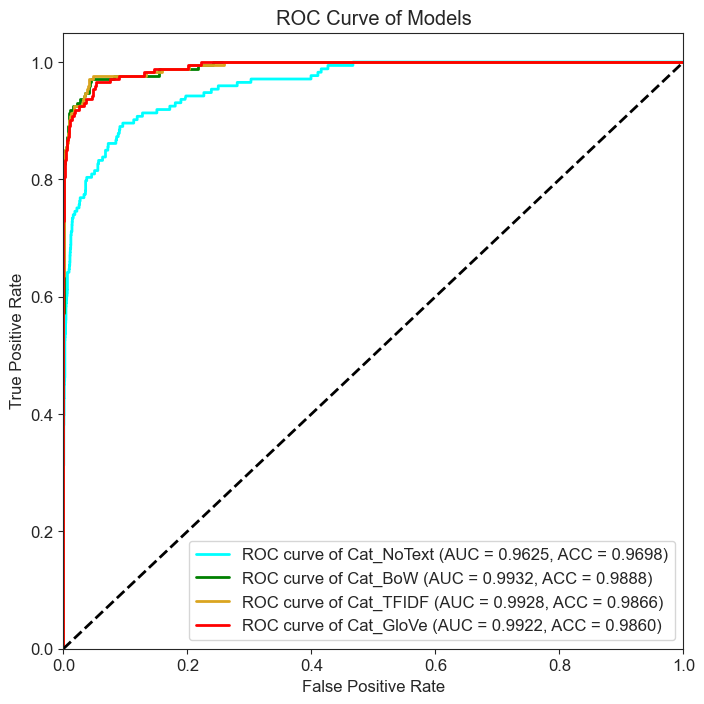

Results saved.


In [197]:
# get the roc curve and threshold
fpr_cat_44, tpr_cat_44, threshold_cat_44 = roc_curve(y_test, y_pred_cat)
plt.figure(figsize=(8, 8))
plt.plot(fpr_cat_41, tpr_cat_41, color='cyan', lw=2, label=f'ROC curve of Cat_NoText (AUC = {cat_auc_no:.4f}, ACC = {cat_accuracy_no:.4f})')
plt.plot(fpr_cat_42, tpr_cat_42, color='green', lw=2, label=f'ROC curve of Cat_BoW (AUC = {cat_auc_count:.4f}, ACC = {cat_accuracy_count:.4f})')
plt.plot(fpr_cat_43, tpr_cat_43, color='goldenrod', lw=2, label=f'ROC curve of Cat_TFIDF (AUC = {cat_auc_tfidf:.4f}, ACC = {cat_accuracy_tfidf:.4f})')
plt.plot(fpr_cat_44, tpr_cat_44, color='red', lw=2, label=f'ROC curve of Cat_GloVe (AUC = {cat_auc_score:.4f}, ACC = {cat_accuracy:.4f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of Models')
plt.legend(loc="lower right")
plt.show()

res = {
    'pipeline': pipe_44,
    'AUC score on the testing set': cat_auc_score,
    'Accuracy on the testing set': cat_accuracy,
    'fpr': fpr_cat_44,
    'tpr': tpr_cat_44,
    'threshold': threshold_cat_44
}

# save the res via joblib
joblib.dump(res, 'models/Cat_GloVe.joblib')
print('Results saved.')

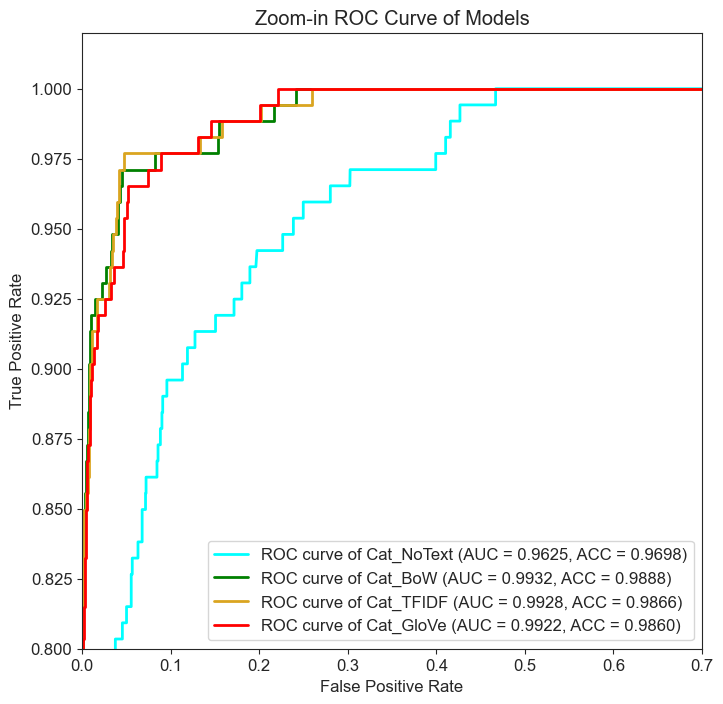

In [198]:
plt.figure(figsize=(8, 8))
plt.plot(fpr_cat_41, tpr_cat_41, color='cyan', lw=2, label=f'ROC curve of Cat_NoText (AUC = {cat_auc_no:.4f}, ACC = {cat_accuracy_no:.4f})')
plt.plot(fpr_cat_42, tpr_cat_42, color='green', lw=2, label=f'ROC curve of Cat_BoW (AUC = {cat_auc_count:.4f}, ACC = {cat_accuracy_count:.4f})')
plt.plot(fpr_cat_43, tpr_cat_43, color='goldenrod', lw=2, label=f'ROC curve of Cat_TFIDF (AUC = {cat_auc_tfidf:.4f}, ACC = {cat_accuracy_tfidf:.4f})')
plt.plot(fpr_cat_44, tpr_cat_44, color='red', lw=2, label=f'ROC curve of Cat_GloVe (AUC = {cat_auc_score:.4f}, ACC = {cat_accuracy:.4f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 0.7])
plt.ylim([0.8, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Zoom-in ROC Curve of Models')
plt.legend(loc="lower right")
plt.show()

In [200]:
pipe_44

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num', StandardScaler(),
                                                  ['N_URLs', 'N_phones',
                                                   'N_emails', 'len_text']),
                                                 ('cat', 'passthrough',
                                                  ['telecommuting',
                                                   'has_company_logo',
                                                   'has_questions',
                                                   'employment_type',
                                                   'required_experience',
                                                   'required_education',
                                                   'industry', 'function',
                                                   'department', 'salary_range',
                                                   'country']),
                                                 ('txt',
                                                  SimpleImputer(fill_value='',
                                                                strategy='constant'),
                                                  ['title', 'company_profile',
                                                   'description',
                                                   'requirements', 'benefits',
                                                   'location'])])),
                ('classifier',
                 <catboost.core.CatBoostClassifier object at 0x00000192C79F0130>)])

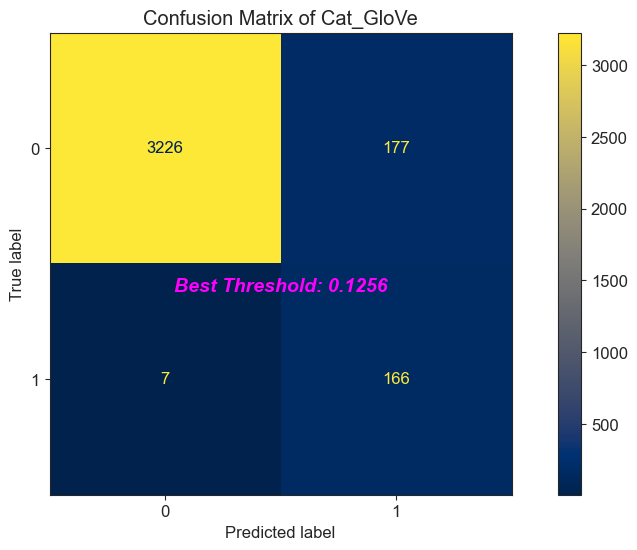

In [199]:
Cat_GloVe = joblib.load('models/Cat_GloVe.joblib')
fpr_cat_glove = Cat_GloVe['fpr']
tpr_cat_glove = Cat_GloVe['tpr']
cat_auc_glove = Cat_GloVe['AUC score on the testing set']
cat_accuracy_glove = Cat_GloVe['Accuracy on the testing set']
thresholds_cat_glove = Cat_GloVe['threshold']
# plot the confusion matrix with the best threshold
best_threshold = thresholds_cat_glove[np.argmax(tpr_cat_glove - fpr_cat_glove)]
y_pred_cat_best = (y_pred_cat > best_threshold).astype(int)
conf_mat_cat = confusion_matrix(y_test, y_pred_cat_best)
# change the color_map to 'Blues' in ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=conf_mat_cat, display_labels=pipe_44.named_steps['classifier'].classes_).plot(cmap='cividis')
plt.title('Confusion Matrix of Cat_GloVe')
# add the best threshold to the top center of the plot in red and size 14 and bold and underlined
plt.text(0.5, 0.45, f'Best Threshold: {best_threshold:.4f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color='magenta', size=14, weight='bold', style='italic')
plt.show()

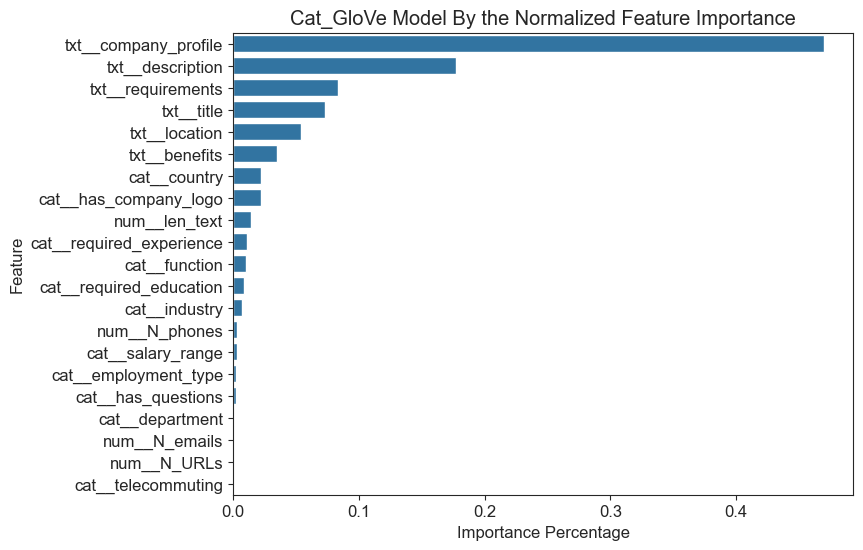

In [201]:
# get the feature importance of the model
fea_imp_cat = pipe_44.named_steps['classifier'].feature_importances_
# get the feature names
fea_names_cat = pipe_44.named_steps['classifier'].feature_names_
# create a DataFrame of feature importance
fea_imp_cat = pd.DataFrame({'feature': fea_names_cat, 'importance': fea_imp_cat})
# sort the DataFrame by importance
fea_imp_cat.sort_values('importance', ascending=False, inplace=True)
# normalize the importance
fea_imp_cat['importance'] = fea_imp_cat['importance'] / fea_imp_cat['importance'].sum()

# plot the feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=fea_imp_cat, legend=False)
plt.title('Cat_GloVe Model By the Normalized Feature Importance')
plt.xlabel('Importance Percentage')
plt.ylabel('Feature')
plt.show()

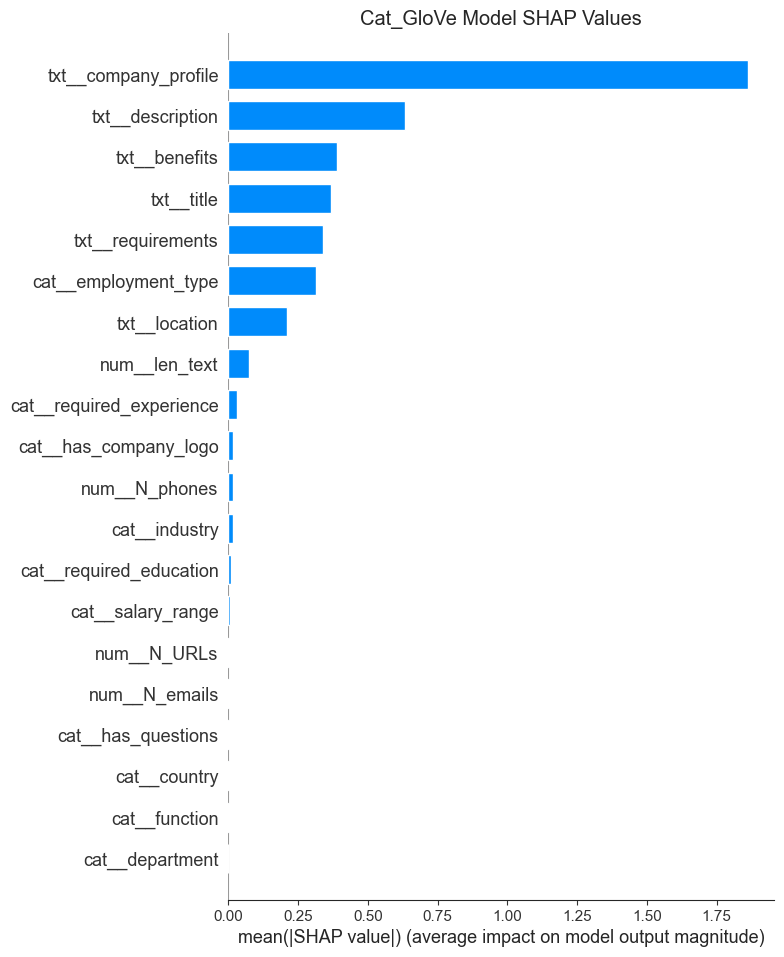

In [202]:
# Get the SHapley values of the model
shap_values_cat = pipe_44.named_steps['classifier'].get_feature_importance(test_pool, type='ShapValues')
# plot the SHapley values
shap.summary_plot(shap_values_cat[:,:-1], X_test_44, plot_type='bar', max_display=20, show=False)
plt.title('Cat_GloVe Model SHAP Values')
plt.show()

## 4.5 Autogluon

In [252]:
gc.collect()
RAY_memory_usage_threshold = 0.995
# Create the TabularDataset for the training and testing that suits the downstream AutoGluon
train_data = TabularDataset(pd.concat([X_train, y_train], axis=1))
test_data = TabularDataset(pd.concat([X_test, y_test], axis=1))

# Ensure the label column is correctly set
label = 'fraudulent'

# Define the feature metadata
cat_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 
            'required_education', 'industry', 'function', 'department', 'salary_range', 'country']
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits', 'location']
num_cols = list(set(train_data.columns) - set(cat_cols) - set(text_cols) - {label})

feature_metadata = FeatureMetadata({
    'text': text_cols,
    'categorical': cat_cols,
    'numerical': num_cols
})
# Define the hyperparameters to include the text models
hyperparameters = {
    'NN_TORCH': {},  # Neural network model
    'AG_AUTOMM': {},  # Text neural network model
    'GBM': {},  # Gradient boosting machine
    'CAT': {},  # CatBoost
    'XGB': {},  # XGBoost
    'RF': {},  # Random forest
    'KNN': {},  # k-nearest neighbors
}

# Create a TabularPrediction instance
predictor = TabularPredictor(label=label
                                 , path='AGModels'
                                 , eval_metric='roc_auc'
                                 , problem_type='binary'
). fit(
    train_data=train_data,
    time_limit=3600*1.5,
    presets='best_quality',
    verbosity=2, 
    hyperparameters=hyperparameters,
    #feature_metadata=feature_metadata,
    num_bag_folds=5,
    num_gpus=1
)

predictor.save('AGModels')

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.9.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          16
Memory Avail:       8.81 GB / 31.93 GB (27.6%)
Disk Space Avail:   261.90 GB / 698.05 GB (37.5%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is used to detect stacked overfitting.
	Running DyStack for up 

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

		NVML Shared Library Not Found
Detailed Traceback:
Traceback (most recent call last):
  File "h:\Software\miniforge3\envs\torch\lib\site-packages\pynvml.py", line 641, in _LoadNvmlLibrary
    nvmlLib = CDLL(os.path.join(os.getenv("ProgramFiles", "C:/Program Files"), "NVIDIA Corporation/NVSMI/nvml.dll"))
  File "h:\Software\miniforge3\envs\torch\lib\ctypes\__init__.py", line 374, in __init__
    self._handle = _dlopen(self._name, mode)
FileNotFoundError: Could not find module 'C:\Program Files\NVIDIA Corporation\NVSMI\nvml.dll' (or one of its dependencies). Try using the full path with constructor syntax.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\Han\AppData\Roaming\Python\Python39\site-packages\autogluon\core\trainer\abstract_trainer.py", line 1904, in _train_and_save
    model = self._train_single(X, y, model, X_val, y_val, total_resources=total_resources, **model_fit_kwargs)
  File "C:\Users\Han\AppData\

In [253]:
predictor.fit_summary(show_plot=False)

*** Summary of fit() ***
Estimated performance of each model:
                    model  score_val eval_metric  pred_time_val     fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0     WeightedEnsemble_L3   0.995396     roc_auc     159.978388  1895.035593                0.002000           0.540439            3       True         13
1          XGBoost_BAG_L2   0.994915     roc_auc      91.470766  1646.420582                1.816998         167.589166            2       True         11
2     WeightedEnsemble_L2   0.994552     roc_auc      72.931967  1475.584747                0.003001           0.288673            2       True          7
3         LightGBM_BAG_L2   0.994194     roc_auc      90.930761  1516.552615                1.276993          37.721200            2       True          8
4         CatBoost_BAG_L2   0.994184     roc_auc      91.863772  1688.146132                2.210004         209.314716            2       True         10
5   Neur

{'model_types': {'KNeighbors_BAG_L1': 'StackerEnsembleModel_KNN',
  'LightGBM_BAG_L1': 'StackerEnsembleModel_LGB',
  'RandomForest_BAG_L1': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L1': 'StackerEnsembleModel_CatBoost',
  'XGBoost_BAG_L1': 'StackerEnsembleModel_XGBoost',
  'NeuralNetTorch_BAG_L1': 'StackerEnsembleModel_TabularNeuralNetTorch',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel',
  'LightGBM_BAG_L2': 'StackerEnsembleModel_LGB',
  'RandomForest_BAG_L2': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L2': 'StackerEnsembleModel_CatBoost',
  'XGBoost_BAG_L2': 'StackerEnsembleModel_XGBoost',
  'NeuralNetTorch_BAG_L2': 'StackerEnsembleModel_TabularNeuralNetTorch',
  'WeightedEnsemble_L3': 'WeightedEnsembleModel'},
 'model_performance': {'KNeighbors_BAG_L1': 0.7504297676217446,
  'LightGBM_BAG_L1': 0.989691089977623,
  'RandomForest_BAG_L1': 0.9901639801353268,
  'CatBoost_BAG_L1': 0.9909687044357531,
  'XGBoost_BAG_L1': 0.9910395239908134,
  'NeuralNetTorch_BAG_L1': 0.95800410986657

In [254]:
# Evaluate the model on the testing set
y_pred = predictor.predict_proba(test_data.drop(columns=[label]))[1]

# view the leaderboard of models trained by autogluon
leaderboard = predictor.leaderboard(test_data)
print(leaderboard)

# Calculate the ROC AUC score
roc_auc_AG = predictor.evaluate(test_data, auxiliary_metrics=False)['roc_auc']
print(f"ROC AUC Score: {roc_auc_AG:.4f}")

# delete other models from predictor but the best model
predictor.delete_models(models_to_keep='best', dry_run=False)

# save the hyperparameters of the best model
best_model_AG = predictor.model_best

# get the best AUC score on training set
best_score_train_AG = leaderboard.iloc[0]['score_val']

# Print the best parameters and score
print(f"The Ensemble model best parameters are: {best_model_AG}")
print(f"The Ensemble best roc_auc score on the validation set is: {leaderboard.iloc[0]['score_val']:.4f}")
print(f"The Ensemble roc_auc score on the test set is: {roc_auc_AG:.4f}")

                    model  score_test  score_val eval_metric  pred_time_test  \
0         LightGBM_BAG_L2    0.997253   0.994194     roc_auc       13.530840   
1         CatBoost_BAG_L2    0.997078   0.994184     roc_auc       12.587545   
2     WeightedEnsemble_L3    0.996926   0.995396     roc_auc       16.080449   
3     WeightedEnsemble_L2    0.996832   0.994552     roc_auc        6.041023   
4          XGBoost_BAG_L2    0.996487   0.994915     roc_auc       13.502371   
5     RandomForest_BAG_L2    0.995638   0.992038     roc_auc       11.925765   
6         LightGBM_BAG_L1    0.995592   0.989691     roc_auc        1.984465   
7   NeuralNetTorch_BAG_L2    0.995232   0.992252     roc_auc       12.041765   
8     RandomForest_BAG_L1    0.993923   0.990164     roc_auc        0.303999   
9          XGBoost_BAG_L1    0.993668   0.991040     roc_auc        2.246557   
10        CatBoost_BAG_L1    0.992524   0.990969     roc_auc        1.208000   
11  NeuralNetTorch_BAG_L1    0.968579   

Deleting model WeightedEnsemble_L2. All files under AGModels\models\WeightedEnsemble_L2 will be removed.
Deleting model CatBoost_BAG_L2. All files under AGModels\models\CatBoost_BAG_L2 will be removed.


ROC AUC Score: 0.9969
The Ensemble model best parameters are: WeightedEnsemble_L3
The Ensemble best roc_auc score on the validation set is: 0.9942
The Ensemble roc_auc score on the test set is: 0.9969


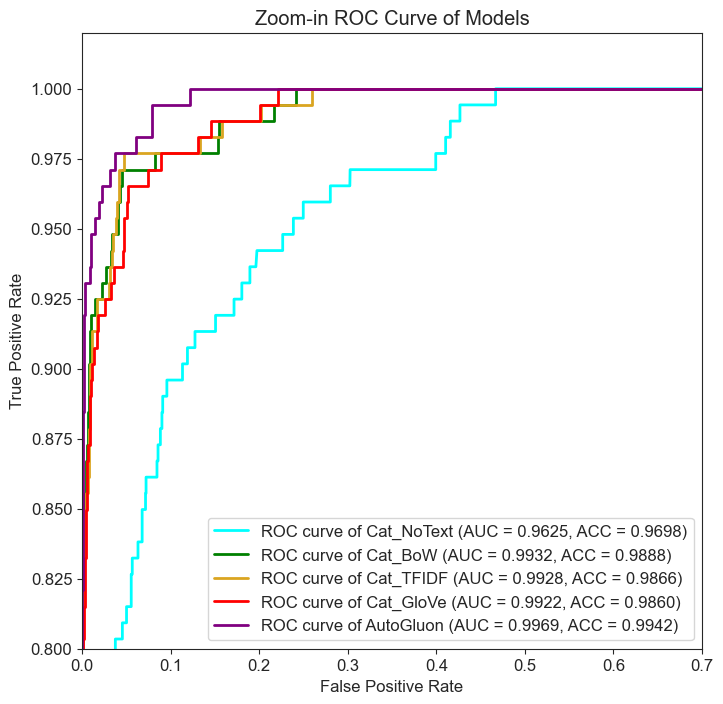

In [255]:
# Plot the ROC curve
fpr_AG, tpr_AG, threshold_AG = roc_curve(y_test, y_pred)
plt.figure(figsize=(8, 8))
plt.plot(fpr_cat_41, tpr_cat_41, color='cyan', lw=2, label=f'ROC curve of Cat_NoText (AUC = {cat_auc_no:.4f}, ACC = {cat_accuracy_no:.4f})')
plt.plot(fpr_cat_42, tpr_cat_42, color='green', lw=2, label=f'ROC curve of Cat_BoW (AUC = {cat_auc_count:.4f}, ACC = {cat_accuracy_count:.4f})')
plt.plot(fpr_cat_43, tpr_cat_43, color='goldenrod', lw=2, label=f'ROC curve of Cat_TFIDF (AUC = {cat_auc_tfidf:.4f}, ACC = {cat_accuracy_tfidf:.4f})')
plt.plot(fpr_cat_44, tpr_cat_44, color='red', lw=2, label=f'ROC curve of Cat_GloVe (AUC = {cat_auc_score:.4f}, ACC = {cat_accuracy:.4f})')
plt.plot(fpr_AG, tpr_AG, color='purple', lw=2, label=f'ROC curve of AutoGluon (AUC = {roc_auc_AG:.4f}, ACC = {best_score_train_AG:.4f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 0.7])
plt.ylim([0.8, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Zoom-in ROC Curve of Models')
plt.legend(loc="lower right")
plt.show()

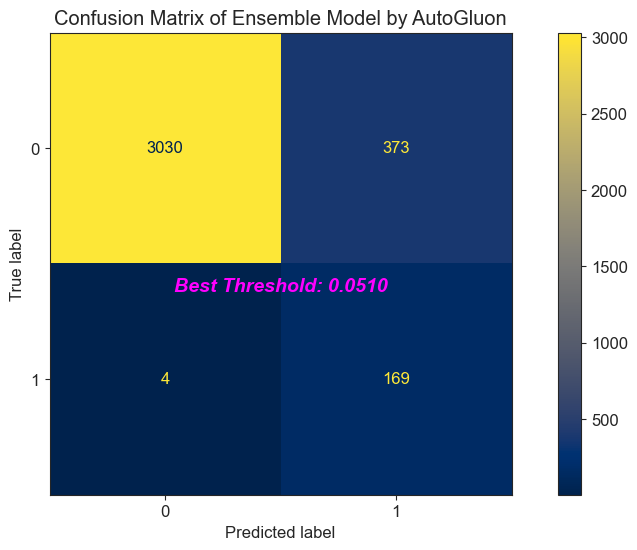

In [259]:
# plot the confusion matrix with the best threshold
best_threshold = threshold_AG[np.argmax(tpr_AG - fpr_AG)]
y_pred_cat_best = (y_pred_cat > best_threshold).astype(int)
conf_mat_cat = confusion_matrix(y_test, y_pred_cat_best)
# change the color_map to 'Blues' in ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=conf_mat_cat, display_labels=pipe_44.named_steps['classifier'].classes_).plot(cmap='cividis')
plt.title('Confusion Matrix of Ensemble Model by AutoGluon')
# add the best threshold to the top center of the plot in red and size 14 and bold and underlined
plt.text(0.5, 0.45, f'Best Threshold: {best_threshold:.4f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color='magenta', size=14, weight='bold', style='italic')
plt.show()

In [260]:
predictor.plot_ensemble_model()

'AGModels\\ensemble_model.png'

![AG_Model](AGModels\ensemble_model.png)

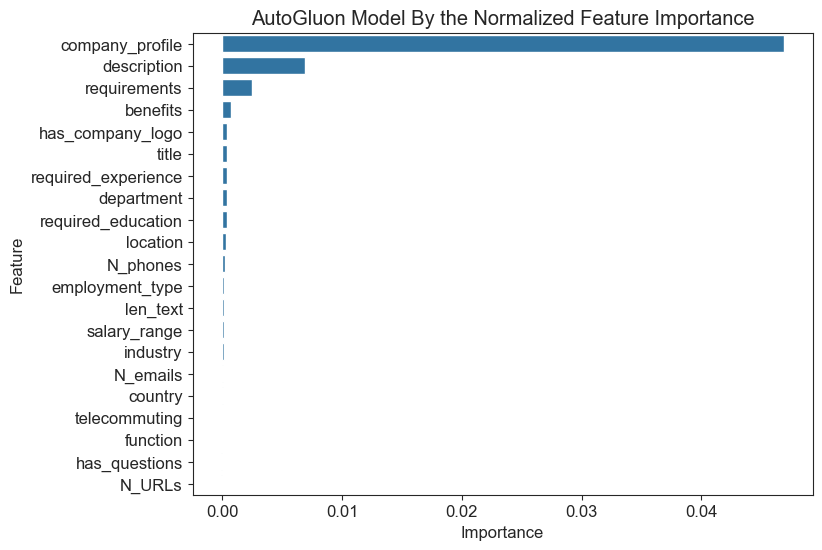

In [267]:
# get the feature importance of the AG model
feature_importance_AG = predictor.feature_importance(test_data, num_shuffle_sets=1, silent=True).reset_index()

# plot the feature importance 
plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='index', data=feature_importance_AG, legend=False)
plt.title('AutoGluon Model By the Normalized Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()